## Imports 

In [22]:
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax import random, jit, value_and_grad

## Step 1:

Create target function and sample 500 points in [0,1] with the intention of picking every 1 in 10 to be in the train set

In [23]:
def target_function(X):
    """
    Desc:
    creates the sinx+sin50x
    Input:
    array (linspace 0,1)

    Output:
    array (applied to function)
    
    """
    x = X[:, 0]

    # You can change this if you want.
    y = jnp.sin(x) + jnp.sin(50.0 * x)

    return y[:, None]


def make_data(n_total=8000, train_every=2):
    """
    Desc:
    generates arrary for training and testing
    Input:
    -the total number of points 
    -the fraction (every x) that are training points vs testing points
    Output
    -training points
    -testing points
    -all points (for some plots)
    - and each parts subsequent y value relating to the x arrays 

    IMPORTANT NOTE: N_TOTAL SHOULD BE HIGHER THAN THE SAMPLED bj VALUES YOU'RE ASLMOST SURELY GOING TO GET. Eg if sampling sigma so that omega=+-
    8000 is likely to happen, need N_Total: to be 8000/2pi < N_total/2 or above.
    """
    X_all = jnp.linspace(
    0.0,
    1.0,
    n_total,
    endpoint=False,
    )[:, None]
    #done so freq stuff lines up later, fixed function docstring to clarify
    y_all = target_function(X_all)

    idx = jnp.arange(n_total)
    train_mask = (idx % train_every) == 0
    test_mask = ~train_mask

    X_train = X_all[train_mask]
    y_train = y_all[train_mask]

    X_test = X_all[test_mask]
    y_test = y_all[test_mask]

    return X_train, y_train, X_test, y_test, X_all, y_all

In [24]:
def make_fourier_params(num_basis,sigma=1.0, key=None,input_dimension=1):

    """
    Desc:
    makes the preconditioning map to apply to the points before training in nn
    Input:
    -the length of the basis for the fourier params
    - the value of sigma to consider
    -the seed key 
    Output
    - the features, matrix B and array A
    """
    j = jnp.arange(1, num_basis + 1, dtype=jnp.float32)[:, None]

    a = 1.0 / (j ** float(0))
    if key is None:
        key = random.PRNGKey(0)

    B=random.normal(key, shape=(num_basis, input_dimension)) * float(sigma)

    return B,a

def make_fourier_params_old(num_basis,p, sigma=1.0, key=None):

    """
    Desc:
    makes the preconditioning map to apply to the points before training in nn
    Input:
    -the length of the basis for the fourier params
    -(mostly refactored out) the order for aj coefficients when I was looking at p instead of b
    -if we want to consider / toggle looking at things from the p perspective or the bj sampling from a normal dist (this is now always on in the streamlined code here
    -the seed key 
    Output
    - the features, matrix B and array A
    """
    if np.isinf(p):
        B=jnp.array([[1.0]])
        a = jnp.array([[1.0]])
        return B, a

    j = jnp.arange(1, num_basis + 1, dtype=jnp.float32)[:, None]

    a = 1.0 / (j ** float(p))

    B=j

    return B,a
    


def fourier_features(X, B, a):
    """
    Desc:
    Takes the coefficients and applies to the sin/ cos map
    Input:
    - the array X
    - the coeffs
    -if we are looking at p vs sigma sampling (togle as before)
    Output
    - the feature map
    """
    projection =X@B.T   # (n, m)
    amp =a.T                              # (1, m)
    cos_features=amp*jnp.cos(2*np.pi*projection)
    sin_features=amp*jnp.sin(2*np.pi*projection)         

    return jnp.concatenate([cos_features, sin_features], axis=-1)

def fourier_features_old(X, B, a):
    """
    Desc:
    Takes the coefficients and applies to the sin/ cos map
    Input:
    - the array X
    - the coeffs
    -if we are looking at p vs sigma sampling (togle as before)
    Output
    - the feature map
    """
    projection =X@B.T   # (n, m)
    amp =a.T 
    cos_features=amp*jnp.cos(projection)
    sin_features=amp*jnp.sin(projection)

    return jnp.concatenate([cos_features, sin_features], axis=-1)


def induced_fourier_kernel(X1, X2, B, a):
    """
    Desc:
    -computes the kernel from the coefficients
    Input:
    - the train array twice to do pairwise differnce (should be X-X.T but X1 X2 is ok)
    Output:
    - the matrix version of the kernel 
    """

    # Pairwise differences: shape (n1, n2)
    diffs = X1 - X2.T

    # Flatten B and a from (m, 1) to (m,)
    b = B[:, 0]
    weights = a[:, 0] ** 2

    # Expand diffs to (n1, n2, 1)
    # Expand b to (1, 1, m)
    # Result: angles shape (n1, n2, m)
    angles = 2.0 * jnp.pi * diffs[:, :, None] * b[None, None, :]

    # Sum over frequencies j
    K = jnp.sum(weights[None, None, :] * jnp.cos(angles), axis=-1)

    return K


## This is a new cell to correctly comupute NTK

In [25]:
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)


def relu_gaussian_expectations_2(K12, q1, q2):
    """
    Compute, exactly for ReLU,

        T(Σ)     = E[ReLU(u) ReLU(v)]
        T_dot(Σ) = E[ReLU'(u) ReLU'(v)]

    where (u, v) is jointly Gaussian and, for each pair (i, j),

        Var(u)   = q1[i]
        Var(v)   = q2[j]
        Cov(u,v) = K12[i,j].
    """
    scale = jnp.sqrt(
        jnp.maximum(q1, 0.0)[:, None]
        * jnp.maximum(q2, 0.0)[None, :]
    )

    safe_scale = jnp.where(scale > 0.0, scale, 1.0)

    rho = jnp.clip(K12 / safe_scale, -1.0, 1.0)
    angle = jnp.arccos(rho)

    T = (
        scale
        / (2.0 * jnp.pi)
        * (
            jnp.sin(angle)
            + (jnp.pi - angle) * jnp.cos(angle)
        )
    )

    T_dot = (jnp.pi - angle) / (2.0 * jnp.pi)

    T = jnp.where(scale > 0.0, T, 0.0)
    T_dot = jnp.where(scale > 0.0, T_dot, 0.0)

    return T, T_dot


def analytic_ntk_matrix_2(
    X1,
    X2=None,
    *,
    depth=2,
    sigma_w_sq=2.0,
    sigma_b_sq=1,
):
    """
    Compute the exact infinite-width ReLU NNGP and NTK matrices.

    The corresponding architecture is

        input
        -> depth hidden ReLU layers
        -> one linear output.

    Parameters
    ----------
    X1 : array, shape (n1, input_dim)
        First collection of inputs.

    X2 : array, shape (n2, input_dim), optional
        Second collection of inputs. If omitted, X2 = X1.

    depth : int
        Number of hidden ReLU layers.

    sigma_w_sq : float
        The paper's weight-variance parameter σ_w².
        For ReLU/He scaling, use 2.0.

    sigma_b_sq : float
        The paper's bias-variance parameter σ_b².

    Returns
    -------
    Theta12 : array, shape (n1, n2)
        Infinite-width NTK Θ(X1, X2).

    K12 : array, shape (n1, n2)
        Infinite-width NNGP kernel K(X1, X2).
    """
    X1 = jnp.asarray(X1, dtype=jnp.float64)

    # If only one dataset is provided, compute K(X1, X1).
    if X2 is None:
        X2 = X1
    else:
        X2 = jnp.asarray(X2, dtype=jnp.float64)

    input_dim = X1.shape[1]

    # Equation S27:
    # K̃¹(x,x') = σ_w²/n₀ · xᵀx' + σ_b²
    K12 = (
        sigma_w_sq / input_dim
    ) * (X1 @ X2.T) + sigma_b_sq

    q1 = (
        sigma_w_sq / input_dim
    ) * jnp.sum(X1**2, axis=1) + sigma_b_sq

    q2 = (
        sigma_w_sq / input_dim
    ) * jnp.sum(X2**2, axis=1) + sigma_b_sq

    # Base case below S29: Θ̃¹ = K̃¹
    Theta12 = K12

    # Starting from K̃¹, each iteration advances one layer.
    # For `depth` hidden layers, this reaches the linear output layer.
    for _ in range(depth):
        T, T_dot = relu_gaussian_expectations_2(
            K12,
            q1,
            q2,
        )

        # Equation S26
        K12_next = sigma_w_sq * T + sigma_b_sq

        # Equation S29
        Theta12_next = (
            K12_next
            + sigma_w_sq * Theta12 * T_dot
        )

        # Diagonal version of S26:
        # for u ~ N(0,q), E[ReLU(u)^2] = q/2
        q1_next = sigma_w_sq * 0.5 * q1 + sigma_b_sq
        q2_next = sigma_w_sq * 0.5 * q2 + sigma_b_sq

        K12 = K12_next
        Theta12 = Theta12_next
        q1 = q1_next
        q2 = q2_next

    return Theta12, K12


def split_kernel_blocks_2(K_all, n_train):
    """
    Split a kernel computed on

        X_all = concatenate([X_train, X_test], axis=0)

    into train/test blocks.
    """
    K_all = jnp.asarray(K_all)

    if K_all.ndim != 2 or K_all.shape[0] != K_all.shape[1]:
        raise ValueError("K_all must be a square matrix.")

    if not 0 <= n_train <= K_all.shape[0]:
        raise ValueError("n_train is outside the valid range.")

    return {
        "train_train": K_all[:n_train, :n_train],
        "test_train": K_all[n_train:, :n_train],
        "train_test": K_all[:n_train, n_train:],
        "test_test": K_all[n_train:, n_train:],
    }


## Cell Note

Train model assumes a depth of 2 and width of 4

first init_mlp_params creates blank W,b of correct dimension, with the b being a zero column and the W being a random normally sampled matrix of mean 0 and var 2/d_in where is the dimension of the input vector.


call mlp-apply which does a forward pass under those initial weights and returns the final layer. Each pass we apply a sigmoid function ReLu to each layer output,h.

We then calc the MSE for the points in y-train using mse_loss before inputting this into the train_step.

The train step then uses `value_and_grad` which takes in `mse_loss`, say $L(\theta)$ if $\theta = \{W_1,b_1,W_2,b_2,\ldots,W_L,b_L\}$ and calcs:

$$
\nabla_{\theta} L(\theta)
$$

then using fixed step size updates params via

$$
\theta_{k+1}
=
\theta_k
-
\eta \nabla_{\theta} L(\theta_k)
$$

where

$$
\eta = \texttt{lr}
$$

and for each layer $\ell$,

$$
W_{\ell,k+1}
=
W_{\ell,k}
-
\eta
\frac{\partial L}{\partial W_{\ell,k}}
$$

$$
b_{\ell,k+1}
=
b_{\ell,k}
-
\eta
\frac{\partial L}{\partial b_{\ell,k}}.
$$

We then run the final learnt layer with the test data

In [26]:
from jax import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp

from jax import (
    random,
    jacrev,
    value_and_grad,
)

from jax.flatten_util import ravel_pytree


# ============================================================
# NTK-PARAMETERIZED INITIALIZATION
# UNCHANGED
# ============================================================

def init_mlp_params(
    key,
    input_dim,
    width=4,
    depth=2,
    use_bias=True,
    output_dim=1
):
    """
    Desc:
    creates initial params for the nn
    Input:
    the length of the vector to feed into the map
    the depth of the nn
    the width of the nn
    Output:
    the initial params to train on

    Changes: * use_bias toggle to decide if b (bias term) is introduced or if it's a vector of zeros
             * W is now sampled from N(0,1) and scaled in later functions
    
    """
    
    layer_sizes = [input_dim] + [width] * depth + [output_dim]
    keys = random.split(key, len(layer_sizes) - 1)

    params = []

    for key_layer, din, dout in zip(
        keys,
        layer_sizes[:-1],
        layer_sizes[1:],
    ):
        key_W, key_b = random.split(key_layer)

        W = random.normal(
            key_W,
            shape=(din, dout),
            dtype=jnp.float64,
        )

        if use_bias:
            b = random.normal(
                key_b,
                shape=(dout,),
                dtype=jnp.float64,
            )
        else:
            b = jnp.zeros(
                (dout,),
                dtype=jnp.float64,
            )

        params.append((W, b))

    return params


# ============================================================
# NTK-PARAMETERIZED FORWARD PASS
# UNCHANGED
# ============================================================

def mlp_apply(
    params,
    X,
    sigma_w_sq=2.0,
    sigma_b_sq=1,
    use_bias=True,
):
    """Desc
    Desc:
    apply relu function to learnt params
    Input:
    params
    training data
    Output:
    sigmoid function applied to linear map

    Changes; W is now multiplied by 2/fan-in as opposed to already having it. fan-in (or fan-out) is 
        the length of input or output vector, fan-out when moving to next layer.
        
    """
    
    h = X
    #prop through all but last layer
    for W, b in params[:-1]:
        fan_in = W.shape[0]

        z = (
            jnp.sqrt(sigma_w_sq / fan_in)
            * (h @ W)
        )

        if use_bias:
            z = z + jnp.sqrt(sigma_b_sq) * b

        h = jax.nn.relu(z)
    #now look at last layer and DONT APPLY RELU
    W, b = params[-1]
    fan_in = W.shape[0]

    output = (
        jnp.sqrt(sigma_w_sq / fan_in)
        * (h @ W)
    )

    if use_bias:
        output = output + jnp.sqrt(sigma_b_sq) * b

    return output

def mse_loss(
    params,
    X,
    y,
    sigma_w_sq=2.0,
    sigma_b_sq=1,
    use_bias=True,
):
    """
    Calculate the mean squared prediction error using the
    explicit NTK parameterization.

    Changes; this is just mostly a wrapper function to apply mlp at some stage in training to get error, 
    just now passes the sigma and use_bias toggle.
    """
    pred = mlp_apply(
        params,
        X,
        sigma_w_sq=sigma_w_sq,
        sigma_b_sq=sigma_b_sq,
        use_bias=use_bias,
    )

    return jnp.mean((pred - y) ** 2)


def train_step(
    params,
    X,
    y,
    lr,
    sigma_w_sq=2.0,
    sigma_b_sq=1,
    use_bias=True,
):
    """
    Perform one full-batch gradient-descent step using the
    explicit NTK parameterization.

    Changes; nothing except passing the new functions
    now, through in-built package, value_and_grad
    will contain the 1/sqrt(m) term that was missing before
    """

    def current_loss(current_params):
        """this is just a wrapper for mse error function, nothing changed"""
        return mse_loss(
            current_params,
            X,
            y,
            sigma_w_sq=sigma_w_sq,
            sigma_b_sq=sigma_b_sq,
            use_bias=use_bias,
        )

    loss, grads = value_and_grad(
        current_loss
    )(params)

    new_params = []

    for (W, b), (gW, gb) in zip(params, grads):
        new_params.append(
            (
                W - lr * gW,
                b - lr * gb,
            )
        )

    return new_params, loss


def train_one_model(
    key,
    X_train_ff,
    y_train,
    X_test_ff,
    y_test,
    width=4,
    depth=2,
    steps=20000,
    lr=1e-3,
    verbose=False,
    sigma_w_sq=2.0,
    sigma_b_sq=1,
    use_bias=True,
):
    """
    Desc:
    train nn to learn weights
    Input:
    -training data with fourier feature preconditioning (or without but usually with)
    -test data
    - y values for train and test
    - width, depth, steps of GD and learning rate for GD
    
    Output:
    the learnt params, predictions of y vals, mse on test and training data

    Changes; Nothing, save the new functions being applied now in this function (so also the need to pass new vars)
    """
    output_dim = y_train.shape[-1]
    params = init_mlp_params(
        key,
        input_dim=X_train_ff.shape[-1],
        width=width,
        depth=depth,
        use_bias=use_bias,
        output_dim=output_dim
    )

    for step in range(steps):
        params, train_loss = train_step(
            params,
            X_train_ff,
            y_train,
            lr,
            sigma_w_sq=sigma_w_sq,
            sigma_b_sq=sigma_b_sq,
            use_bias=use_bias,
        )

        if verbose and (
            step % 500 == 0
            or step == steps - 1
        ):
            test_loss = mse_loss(
                params,
                X_test_ff,
                y_test,
                sigma_w_sq=sigma_w_sq,
                sigma_b_sq=sigma_b_sq,
                use_bias=use_bias,
            )

            print(
                f"step {step:5d} | "
                f"train MSE {float(train_loss):.6e} | "
                f"test MSE {float(test_loss):.6e}"
            )

    final_train_mse = float(
        mse_loss(
            params,
            X_train_ff,
            y_train,
            sigma_w_sq=sigma_w_sq,
            sigma_b_sq=sigma_b_sq,
            use_bias=use_bias,
        )
    )
    #final call using best params 
    final_test_mse = float(
        mse_loss(
            params,
            X_test_ff,
            y_test,
            sigma_w_sq=sigma_w_sq,
            sigma_b_sq=sigma_b_sq,
            use_bias=use_bias,
        )
    )

    y_pred_test = mlp_apply(
        params,
        X_test_ff,
        sigma_w_sq=sigma_w_sq,
        sigma_b_sq=sigma_b_sq,
        use_bias=use_bias,
    )
    #bucket of data incuding best weights, predictions using them, and the train and test MSE
    return (
        params,
        y_pred_test,
        final_train_mse,
        final_test_mse,
    )

def bj_title(sigma, b_tog=True):
    """
    Desc:
    old function to display latex for graph
    Input:
    sigma val and if toggle is on
    Output:
    -
    """
    if b_tog:
        return rf"$B \sim \mathcal{{N}}(0, {sigma}^2)$"
    else:
        return r"$b_j = j$"

#
#TWO NEW FUNCTIONS TO FACILITATE MEMORY WHEN TRAINING
#
#the jax.jit wrap makes this alot faster! condenses x operations into 1 operator from what I can tell
@jax.jit
def fixed_train_step(
    params,
    X,
    y,
    lr,
):
    """
    Perform one JIT-compiled gradient-descent step.

    The following experiment settings are captured from the
    surrounding scope:

        sigma_w_sq
        sigma_b_sq
        use_bias
    """
    return train_step(
        params,
        X,
        y,
        lr,
        sigma_w_sq=sigma_w_sq,
        sigma_b_sq=sigma_b_sq,
        use_bias=use_bias,
    )


def train_checkpoint(
    params,
    X,
    y,
    *,
    number_of_steps,
    lr,
):
    """
    Continue training an existing NTK-parameterized model.

    Parameters are not reinitialized inside this function.
    Each iteration calls the JIT-compiled training step.
    """
    final_loss = None

    for _ in range(number_of_steps):
        params, final_loss = fixed_train_step(
            params,
            X,
            y,
            lr,
        )

    return params, final_loss



**What about if we used conditions like Armijo or employed Newton's or pseudo Newton's method for the min step of the nn?**

## SECTION 1

Shapes
------
X_train: (50, 1)
y_train: (50, 1)
X_test:  (50, 1)
y_test:  (50, 1)
X_all:   (100, 1)

Training vanilla model
Vanilla checkpoint  1/30 | steps  1000 | train MSE 4.956961e-01 | test MSE 4.947846e-01
Vanilla checkpoint  2/30 | steps  2000 | train MSE 4.923882e-01 | test MSE 4.917041e-01
Vanilla checkpoint  3/30 | steps  3000 | train MSE 4.903391e-01 | test MSE 4.896747e-01
Vanilla checkpoint  4/30 | steps  4000 | train MSE 4.889311e-01 | test MSE 4.884492e-01
Vanilla checkpoint  5/30 | steps  5000 | train MSE 4.879143e-01 | test MSE 4.875911e-01
Vanilla checkpoint  6/30 | steps  6000 | train MSE 4.872923e-01 | test MSE 4.869654e-01
Vanilla checkpoint  7/30 | steps  7000 | train MSE 4.867581e-01 | test MSE 4.864285e-01
Vanilla checkpoint  8/30 | steps  8000 | train MSE 4.862494e-01 | test MSE 4.859819e-01
Vanilla checkpoint  9/30 | steps  9000 | train MSE 4.858193e-01 | test MSE 4.855869e-01
Vanilla checkpoint 10/30 | steps 10000 | train MSE 4.855207e-01 | test MSE 4.852412e

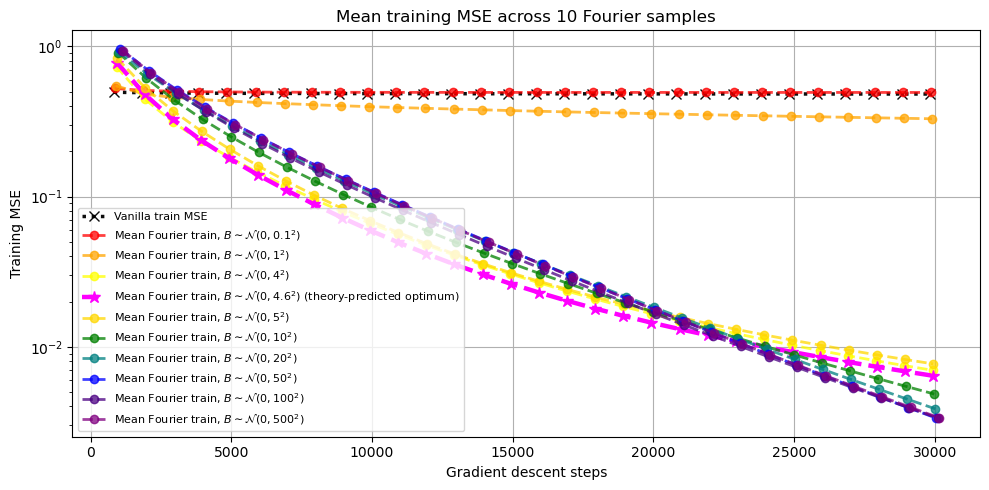

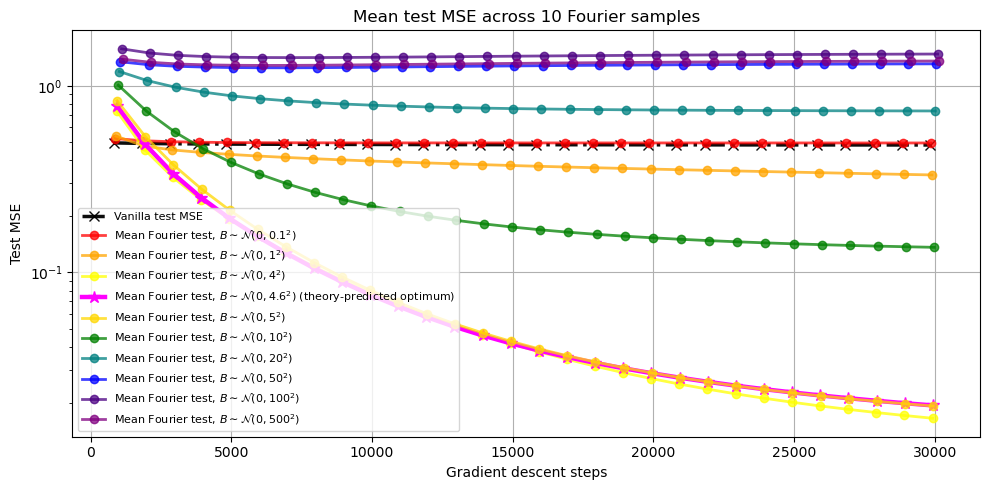


Prediction-error statistics
--- Error Data for sigma=0.1 ---
Mean sample MSE: 0.4942195979496575
MSE standard deviation: 0.0020648448178743443
Mean sample maximum absolute error: 1.1063940879354135
--- Error Data for sigma=1 ---
Mean sample MSE: 0.331617374060752
MSE standard deviation: 0.014147482012603694
Mean sample maximum absolute error: 0.9148297541269678
--- Error Data for sigma=4 ---
Mean sample MSE: 0.01175614081194101
MSE standard deviation: 0.0044463279506695395
Mean sample maximum absolute error: 0.44004423655461244
--- Error Data for sigma=4.6 ---
Mean sample MSE: 0.012893372207448484
MSE standard deviation: 0.003375561591395176
Mean sample maximum absolute error: 0.43998463401536453
--- Error Data for sigma=5 ---
Mean sample MSE: 0.013466890605782636
MSE standard deviation: 0.00498112687376907
Mean sample maximum absolute error: 0.40911055294058535
--- Error Data for sigma=10 ---
Mean sample MSE: 0.07060434121546433
MSE standard deviation: 0.015301920340357638
Mean sampl

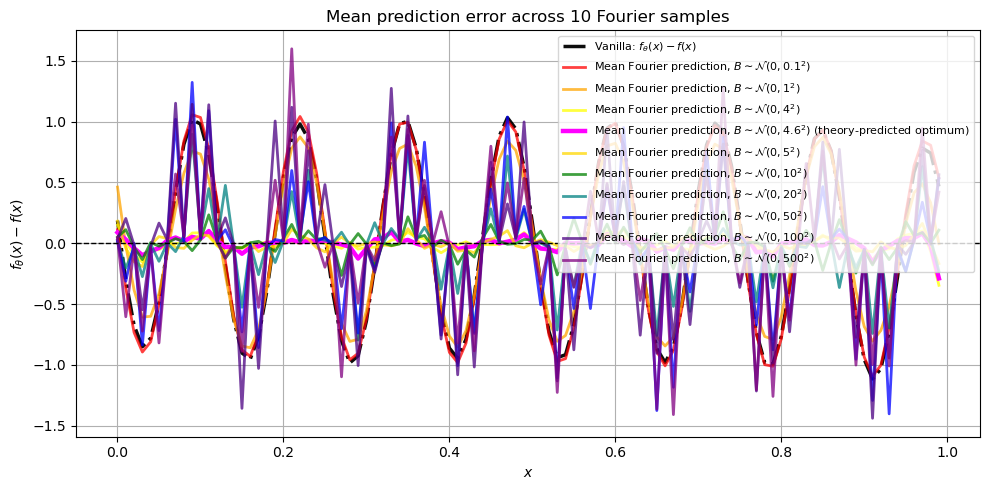


Best sigma by mean test MSE at 30,000 steps: 4
Mean final test MSE: 0.016542896532033568
Final test-MSE standard deviation: 0.007019855181331918

Theory-predicted sigma at 30,000 steps: 4.6
Mean final test MSE for sigma=4.6: 0.019380440453461552
Final test-MSE standard deviation for sigma=4.6: 0.005540194287736978


In [7]:
# ============================================================================
# CALCULATE MSE FOR DIFFERENT SIGMA VALUES
#
#
# Each model is initialized once and continues training:
#
#     0 -> 1,000 -> 2,000 -> ... -> n steps
#
# rather than initializing a new model at every checkpoint.
# ============================================================================

num_basis = 1024 #was 1024 for good result?
p = 0  # keeps a_j = 1

master_key = random.PRNGKey(0)

# Number of independent Fourier-frequency samples for each sigma.
n_samples = 10


# ============================================================================
# Training settings shared by every function call
# ============================================================================

width = 128
depth = 2

learning_rate = 1e-3

sigma_w_sq = 2.0
sigma_b_sq = 1.0
use_bias = True


# Train for 1,000 additional steps between recorded checkpoints.
steps_per_checkpoint = 1000
num_checkpoints = 30

checkpoint_steps = [
    steps_per_checkpoint * checkpoint_idx
    for checkpoint_idx in range(
        1,
        num_checkpoints + 1,
    )
]

total_training_steps = checkpoint_steps[-1]


# ============================================================================
# Data
# ============================================================================

X_train, y_train, X_test, y_test, X_all, y_all = make_data(
    n_total=100,
    train_every=2,
)

print("Shapes")
print("------")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)
print("X_all:  ", X_all.shape)
print()


# ============================================================================
# Sigma values
#
# sigma = 4.6 is the theory-predicted optimum being tested.
# ============================================================================

sigma_values = [
    0.1,
    1,
    4,
    4.6,
    5,
    10,
    20,
    50,
    100,
    500,
]


# ============================================================================
# Results storage
# ============================================================================

results = {
    sigma: {
        "steps": checkpoint_steps,
        "train_ff_samples": [],
        "test_ff_samples": [],
        "y_pred_all_ff_samples": [],
    }
    for sigma in sigma_values
}


# ============================================================================
# Train the vanilla model once
#
# It does not depend on sigma or on the Fourier-frequency sample.
#
# The same parameter object continues training between checkpoints.
# ============================================================================

print("Training vanilla model")

key_model_vanilla = random.fold_in(
    master_key,
    1,
)

params_n = init_mlp_params(
    key_model_vanilla,
    input_dim=X_train.shape[-1],
    width=width,
    depth=depth,
    use_bias=use_bias,
)

train_mse_n_list = []
test_mse_n_list = []


for checkpoint_idx, total_steps in enumerate(
    checkpoint_steps,
    start=1,
):
    # Continue the existing model for another 1,000 steps.
    params_n, _ = train_checkpoint(
        params_n,
        X_train,
        y_train,
        number_of_steps=steps_per_checkpoint,
        lr=learning_rate,
    )

    train_mse_n = mse_loss(
        params_n,
        X_train,
        y_train,
        sigma_w_sq=sigma_w_sq,
        sigma_b_sq=sigma_b_sq,
        use_bias=use_bias,
    )

    test_mse_n = mse_loss(
        params_n,
        X_test,
        y_test,
        sigma_w_sq=sigma_w_sq,
        sigma_b_sq=sigma_b_sq,
        use_bias=use_bias,
    )

    train_mse_n_list.append(
        float(train_mse_n)
    )

    test_mse_n_list.append(
        float(test_mse_n)
    )

    print(
        f"Vanilla checkpoint "
        f"{checkpoint_idx:2d}/{num_checkpoints} | "
        f"steps {total_steps:5d} | "
        f"train MSE {float(train_mse_n):.6e} | "
        f"test MSE {float(test_mse_n):.6e}"
    )


# Final vanilla prediction after all checkpoints.
y_pred_all_n_final = mlp_apply(
    params_n,
    X_all,
    sigma_w_sq=sigma_w_sq,
    sigma_b_sq=sigma_b_sq,
    use_bias=use_bias,
)


results["vanilla"] = {
    "steps": checkpoint_steps,
    "train": train_mse_n_list,
    "test": test_mse_n_list,
    "y_pred_all": y_pred_all_n_final,
}


# ============================================================================
# Fourier-feature models
#
# For each Fourier sample and sigma:
#
#   1. Draw one B.
#   2. Initialize one model.
#   3. Continue training that same model through every checkpoint.
# ============================================================================

for sample_idx in range(n_samples):

    print()
    print(
        f"Fourier sample "
        f"{sample_idx + 1}/{n_samples}"
    )

    for sigma_idx, sigma in enumerate(sigma_values):
        print(
            f"  sigma={sigma}"
        )

        key_model = random.fold_in(
            master_key,
            1,
        )

        # Fresh Fourier-frequency key for each sample and sigma.
        key_B = random.fold_in(
        master_key,
        (
            100
            + sample_idx * len(sigma_values)
            + sigma_idx
        ),
        )

        B, a = make_fourier_params(
            num_basis=num_basis,
            sigma=sigma,
            key=key_B,
        )

        X_train_ff = fourier_features(
            X_train,
            B,
            a,
        )

        X_test_ff = fourier_features(
            X_test,
            B,
            a,
        )

        X_all_ff = fourier_features(
            X_all,
            B,
            a,
        )

        # Initialize exactly once for this Fourier model.
        params_ff = init_mlp_params(
            key_model,
            input_dim=X_train_ff.shape[-1],
            width=width,
            depth=depth,
            use_bias=use_bias,
        )

        train_mse_ff_list = []
        test_mse_ff_list = []


        for checkpoint_idx, total_steps in enumerate(
            checkpoint_steps,
            start=1,
        ):
                # Continue the existing model for another 1,000 steps.
            params_ff, _ = train_checkpoint(
                    params_ff,
                    X_train_ff,
                    y_train,
                    number_of_steps=steps_per_checkpoint,
                    lr=learning_rate,
                )
    
            train_mse_ff = mse_loss(
                    params_ff,
                    X_train_ff,
                    y_train,
                    sigma_w_sq=sigma_w_sq,
                    sigma_b_sq=sigma_b_sq,
                    use_bias=use_bias,
                )
    
            test_mse_ff = mse_loss(
                    params_ff,
                    X_test_ff,
                    y_test,
                    sigma_w_sq=sigma_w_sq,
                    sigma_b_sq=sigma_b_sq,
                    use_bias=use_bias,
                )
    
            train_mse_ff_list.append(
                    float(train_mse_ff)
                )
    
            test_mse_ff_list.append(
                    float(test_mse_ff)
                )
    
    
            # Prediction from this model after all training steps.
            y_pred_all_ff_final = mlp_apply(
                params_ff,
                X_all_ff,
                sigma_w_sq=sigma_w_sq,
                sigma_b_sq=sigma_b_sq,
                use_bias=use_bias,
            )


        results[sigma][
            "train_ff_samples"
        ].append(
            jnp.asarray(train_mse_ff_list)
        )

        results[sigma][
            "test_ff_samples"
        ].append(
            jnp.asarray(test_mse_ff_list)
        )

        results[sigma][
            "y_pred_all_ff_samples"
        ].append(
            jnp.asarray(y_pred_all_ff_final)
        )


        print(
            f"    final train MSE: "
            f"{train_mse_ff_list[-1]:.6e}"
        )

        print(
            f"    final test MSE:  "
            f"{test_mse_ff_list[-1]:.6e}"
        )


# ============================================================================
# Average over independent Fourier samples
# ============================================================================

for sigma in sigma_values:

    train_ff_stack = jnp.stack(
        results[sigma]["train_ff_samples"],
        axis=0,
    )

    test_ff_stack = jnp.stack(
        results[sigma]["test_ff_samples"],
        axis=0,
    )

    prediction_stack = jnp.stack(
        results[sigma][
            "y_pred_all_ff_samples"
        ],
        axis=0,
    )


    # Mean train/test MSE curves over Fourier samples.
    results[sigma]["train_ff"] = jnp.mean(
        train_ff_stack,
        axis=0,
    )

    results[sigma]["test_ff"] = jnp.mean(
        test_ff_stack,
        axis=0,
    )


    # Standard deviations across Fourier samples.
    results[sigma]["train_ff_std"] = jnp.std(
        train_ff_stack,
        axis=0,
        ddof=1,
    )

    results[sigma]["test_ff_std"] = jnp.std(
        test_ff_stack,
        axis=0,
        ddof=1,
    )


    # Mean prediction across independently trained Fourier models.
    results[sigma]["y_pred_all_ff"] = jnp.mean(
        prediction_stack,
        axis=0,
    )


    # Compute one all-point MSE for each Fourier model.
    #
    # This is different from the MSE of the averaged ensemble prediction.
    sample_errors = (
        prediction_stack
        - y_all[None, ...]
    )

    sample_errors_flat = sample_errors.reshape(
        n_samples,
        -1,
    )

    all_mse_samples = jnp.mean(
        sample_errors_flat**2,
        axis=1,
    )

    max_abs_error_samples = jnp.max(
        jnp.abs(sample_errors_flat),
        axis=1,
    )


    results[sigma][
        "all_mse_samples"
    ] = all_mse_samples

    results[sigma][
        "all_mse_mean"
    ] = jnp.mean(
        all_mse_samples
    )

    results[sigma][
        "all_mse_std"
    ] = jnp.std(
        all_mse_samples,
        ddof=1,
    )

    results[sigma][
        "max_abs_error_mean"
    ] = jnp.mean(
        max_abs_error_samples
    )


# ============================================================================
# Plotting colors and visual-only horizontal offsets
# ============================================================================

colors = {
    0.1: "red",
    1: "orange",
    4: "yellow",
    4.6: "magenta",
    5: "gold",
    10: "green",
    20: "teal",
    50: "blue",
    100: "indigo",
    500: "purple",
}


# These offsets only make overlapping markers easier to distinguish.
# They do not change the recorded MSE values.
offsets = {
    "vanilla": -180,
    0.1: -140,
    1: -100,
    4: -80,
    4.6: -70,
    5: -60,
    10: -20,
    20: 20,
    50: 60,
    100: 100,
    500: 140,
}


vanilla_steps = (
    jnp.asarray(
        results["vanilla"]["steps"]
    )
    + offsets["vanilla"]
)


# ============================================================================
# Print final error statistics
# ============================================================================

print()
print("Final error statistics")

for sigma in sigma_values:

    print(
        f"--- Error Data for sigma={sigma} ---"
    )

    print(
        "Mean all-point MSE:",
        float(
            results[sigma][
                "all_mse_mean"
            ]
        ),
    )

    print(
        "All-point MSE standard deviation:",
        float(
            results[sigma][
                "all_mse_std"
            ]
        ),
    )

    print(
        "Mean maximum absolute error:",
        float(
            results[sigma][
                "max_abs_error_mean"
            ]
        ),
    )


# ============================================================================
# TRAINING MSE PLOT
# ============================================================================

plt.figure(
    figsize=(10, 5)
)


plt.plot(
    vanilla_steps,
    results["vanilla"]["train"],
    linestyle=":",
    marker="x",
    color="black",
    linewidth=2.5,
    markersize=7,
    alpha=0.95,
    label="Vanilla train MSE",
)


for sigma in sigma_values:

    color = colors[sigma]

    title = bj_title(
        sigma=sigma,
        b_tog=True,
    )

    steps = (
        jnp.asarray(
            results[sigma]["steps"]
        )
        + offsets[sigma]
    )


    # Highlight the theory-predicted optimum.
    if sigma == 4.6:

        label = (
            rf"Mean Fourier train, {title} "
            rf"(theory-predicted optimum)"
        )

        linewidth = 3.2
        markersize = 9
        marker = "*"
        alpha = 1.0

    else:

        label = (
            rf"Mean Fourier train, {title}"
        )

        linewidth = 2.0
        markersize = 6
        marker = "o"
        alpha = 0.75


    plt.plot(
        steps,
        results[sigma]["train_ff"],
        linestyle="--",
        marker=marker,
        color=color,
        linewidth=linewidth,
        markersize=markersize,
        alpha=alpha,
        label=label,
    )


plt.xlabel(
    "Gradient descent steps"
)

plt.ylabel(
    "Training MSE"
)

plt.yscale(
    "log"
)

plt.title(
    f"Mean training MSE across "
    f"{n_samples} Fourier samples"
)

plt.legend(
    fontsize=8
)

plt.grid(
    True
)

plt.tight_layout()
plt.show()


# ============================================================================
# TEST MSE PLOT
# ============================================================================

plt.figure(
    figsize=(10, 5)
)


plt.plot(
    vanilla_steps,
    results["vanilla"]["test"],
    linestyle="-.",
    marker="x",
    color="black",
    linewidth=2.5,
    markersize=7,
    alpha=0.95,
    label="Vanilla test MSE",
)


for sigma in sigma_values:

    color = colors[sigma]

    title = bj_title(
        sigma=sigma,
        b_tog=True,
    )

    steps = (
        jnp.asarray(
            results[sigma]["steps"]
        )
        + offsets[sigma]
    )


    # Highlight the theory-predicted optimum.
    if sigma == 4.6:

        label = (
            rf"Mean Fourier test, {title} "
            rf"(theory-predicted optimum)"
        )

        linewidth = 3.2
        markersize = 9
        marker = "*"
        alpha = 1.0

    else:

        label = (
            rf"Mean Fourier test, {title}"
        )

        linewidth = 2.0
        markersize = 6
        marker = "o"
        alpha = 0.75


    plt.plot(
        steps,
        results[sigma]["test_ff"],
        linestyle="-",
        marker=marker,
        color=color,
        linewidth=linewidth,
        markersize=markersize,
        alpha=alpha,
        label=label,
    )


plt.xlabel(
    "Gradient descent steps"
)

plt.ylabel(
    "Test MSE"
)

plt.yscale(
    "log"
)

plt.title(
    f"Mean test MSE across "
    f"{n_samples} Fourier samples"
)

plt.legend(
    fontsize=8
)

plt.grid(
    True
)

plt.tight_layout()
plt.show()


# ============================================================================
# COMBINED PREDICTION-ERROR PLOT
# ============================================================================

plt.figure(
    figsize=(10, 5)
)


x_plot = X_all.reshape(-1)
y_true_plot = y_all.reshape(-1)


# Sort x so the curves are drawn cleanly.
sort_idx = jnp.argsort(
    x_plot
)

x_plot = x_plot[
    sort_idx
]

y_true_plot = y_true_plot[
    sort_idx
]


# Vanilla prediction error.
vanilla_pred = results[
    "vanilla"
]["y_pred_all"].reshape(-1)

vanilla_error = (
    vanilla_pred[sort_idx]
    - y_true_plot
)


plt.plot(
    x_plot,
    vanilla_error,
    linestyle="-.",
    color="black",
    linewidth=2.5,
    alpha=0.95,
    label=r"Vanilla: $f_\theta(x)-f(x)$",
)


print()
print("Prediction-error statistics")


for sigma in sigma_values:

    color = colors[sigma]

    title = bj_title(
        sigma=sigma,
        b_tog=True,
    )

    ff_pred = results[
        sigma
    ]["y_pred_all_ff"].reshape(-1)

    ff_error = (
        ff_pred[sort_idx]
        - y_true_plot
    )


    print(
        f"--- Error Data for sigma={sigma} ---"
    )

    print(
        "Mean sample MSE:",
        float(
            results[sigma][
                "all_mse_mean"
            ]
        ),
    )

    print(
        "MSE standard deviation:",
        float(
            results[sigma][
                "all_mse_std"
            ]
        ),
    )

    print(
        "Mean sample maximum absolute error:",
        float(
            results[sigma][
                "max_abs_error_mean"
            ]
        ),
    )


    if sigma == 4.6:

        label = (
            rf"Mean Fourier prediction, {title} "
            rf"(theory-predicted optimum)"
        )

        linewidth = 3.2
        alpha = 1.0

    else:

        label = (
            rf"Mean Fourier prediction, {title}"
        )

        linewidth = 2.0
        alpha = 0.75


    plt.plot(
        x_plot,
        ff_error,
        linestyle="-",
        color=color,
        linewidth=linewidth,
        alpha=alpha,
        label=label,
    )


plt.axhline(
    0.0,
    color="black",
    linewidth=1,
    linestyle="--",
)


plt.xlabel(
    r"$x$"
)

plt.ylabel(
    r"$f_\theta(x)-f(x)$"
)

plt.title(
    rf"Mean prediction error across "
    rf"{n_samples} Fourier samples"
)

plt.legend(
    fontsize=8
)

plt.grid(
    True
)

plt.tight_layout()
plt.show()


# ============================================================================
# Best sigma by final mean test MSE
# ============================================================================

best_sigma = min(
    sigma_values,
    key=lambda sigma: float(
        results[sigma]["test_ff"][-1]
    ),
)


print()

print(
    f"Best sigma by mean test MSE "
    f"at {total_training_steps:,} steps:",
    best_sigma,
)

print(
    "Mean final test MSE:",
    float(
        results[best_sigma][
            "test_ff"
        ][-1]
    ),
)

print(
    "Final test-MSE standard deviation:",
    float(
        results[best_sigma][
            "test_ff_std"
        ][-1]
    ),
)


# ============================================================================
# Explicitly print the sigma=4.6 result for comparison
# ============================================================================

print()

print(
    f"Theory-predicted sigma at "
    f"{total_training_steps:,} steps:",
    4.6,
)

print(
    "Mean final test MSE for sigma=4.6:",
    float(
        results[4.6][
            "test_ff"
        ][-1]
    ),
)

print(
    "Final test-MSE standard deviation for sigma=4.6:",
    float(
        results[4.6][
            "test_ff_std"
        ][-1]
    ),
)

## Condition Numbers 

Maybe upon calculating the condition numbers for their composed matrix we might need to adjust the values. Eg issues with machine precision / backwards stability if too extreme. 

In [27]:
from jax import config
config.update("jax_enable_x64", True)

from jax import jacrev
from jax.flatten_util import ravel_pytree
import jax
import jax.numpy as jnp


def scalar_output(
    params,
    x,
    use_bias=True,
    sigma_w_sq=2.0,
    sigma_b_sq=1,
):
    """
    Desc: Extract the predictions from the trained params 

    Input: trained params, X data, bias toggle and weight sigmas
    Note,  bias stuff needed, despite initially doing N tilda (0, sigma_w/ d_in), as propagate through layers in mlp_apply

    Output: neural net prediction for 2D Case

    Changes; None other than applying new vars and functions
    """
    #output of apply is a matrix with (no. points in input (ie 256 first, then hidden layer width then 1 for output for real value))x(no neurons in this layer)
    #so matrix is 1x1 in our toy example, hence extract [0,0]
    return mlp_apply(
        params,
        x[None, :],
        sigma_w_sq=sigma_w_sq,
        sigma_b_sq=sigma_b_sq,
        use_bias=use_bias,
    )[0, 0]


def empirical_ntk_matrix(
    params,
    X,
    use_bias=True,
    sigma_w_sq=2.0,
    sigma_b_sq=1,
    X_2=None,
):
    """
    Desc: Computes the empirical NTK matrix.

    If X_2 is None:
        K = J(X) @ J(X).T

    If X_2 is provided:
        K = J(X) @ J(X_2).T
    THIS HAS BEEN CHANGED ON 1ST AUG
    """

    X = X.astype(jnp.float64)

    def grad_flat(x):
        grads = jacrev(
            scalar_output,
            argnums=0,
        )(
            params,
            x,
            use_bias=use_bias,
            sigma_w_sq=sigma_w_sq,
            sigma_b_sq=sigma_b_sq,
        )

        flat_grads, _ = ravel_pytree(grads)

        return flat_grads.astype(jnp.float64)

    if X_2 is None:
        J = jax.vmap(grad_flat)(X)
        K = J @ J.T

        # reduce memory needed
        J = None

        return K, J

    X_2 = X_2.astype(jnp.float64)

    J = jax.vmap(grad_flat)(X)
    J_2 = jax.vmap(grad_flat)(X_2)

    K = J @ J_2.T

    # reduce memory needed
    J = None
    J_2 = None

    return K, J


def condition_number_psd(K, rtol=1e-9):
    """
    Desc:
    calc cond number of matrix wrt tolerance (default is one 100 millionth of largest eigenvalue considered noise and discounted)
    Input:
    matrix 
    Output:
    condition number
    """
    K = K.astype(jnp.float64)
    K = 0.5 * (K + K.T)

    eigvals = jnp.linalg.eigvalsh(K)
    eigvals = jnp.maximum(eigvals, 0.0)

    lam_max = eigvals[-1]

    cutoff = rtol * lam_max

    lam_min = jnp.min(
        jnp.where(eigvals > cutoff, eigvals, jnp.inf)
    )

    cond = lam_max / lam_min

    return cond, eigvals


import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import random



Shapes
------
X_train: (250, 1)
y_train: (250, 1)
X_test:  (250, 1)
y_test:  (250, 1)
X_all:   (500, 1)



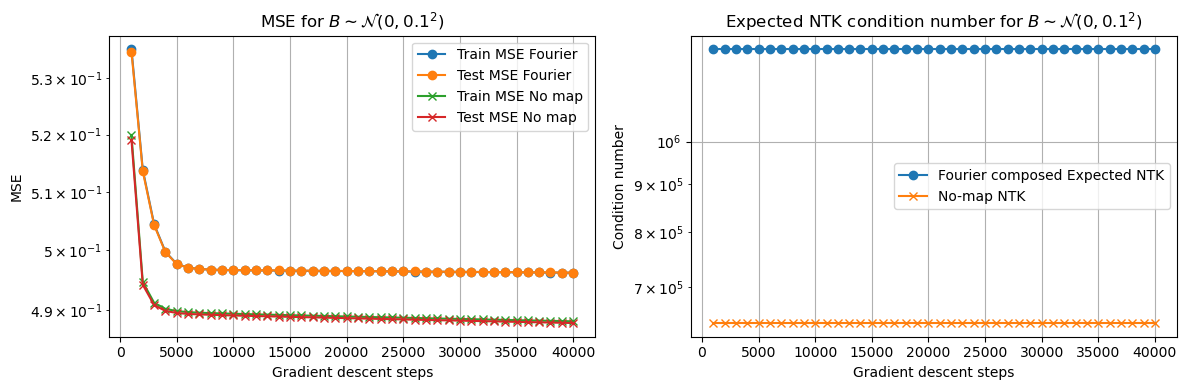

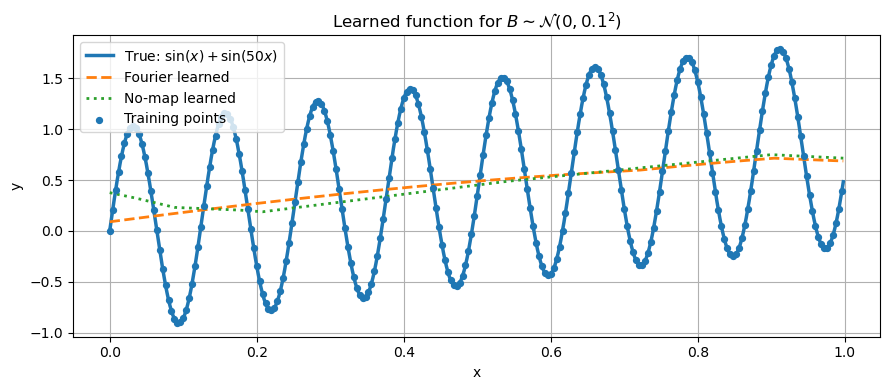


Maximum errors for sigma = 0.1 at 40,000 GD steps
---------------------------------------------
Fourier maximum signed (f_theta - y_true): 1.082379e+00 at x = 0.094000
Fourier maximum absolute |f_theta - y_true|:     1.082379e+00 at x = 0.094000
No-map maximum signed (f_theta - y_true):   1.134839e+00 at x = 0.094000
No-map maximum absolute |f_theta - y_true|:       1.134839e+00 at x = 0.094000



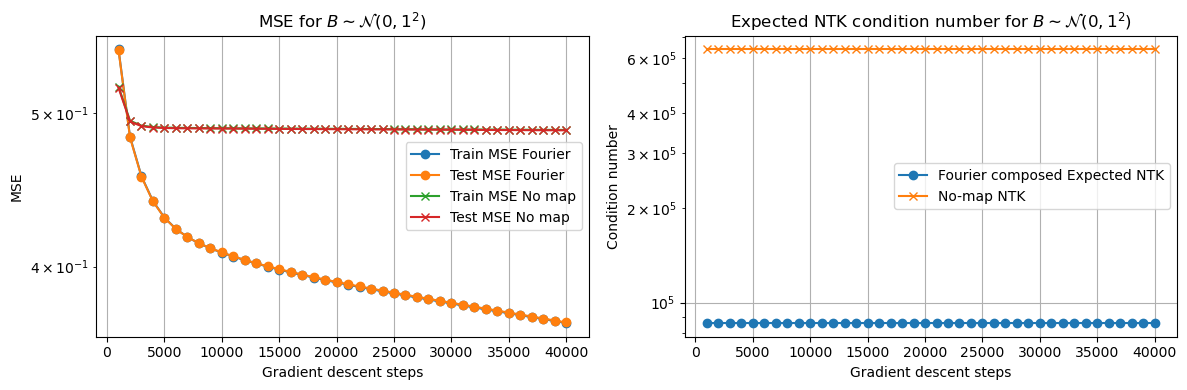

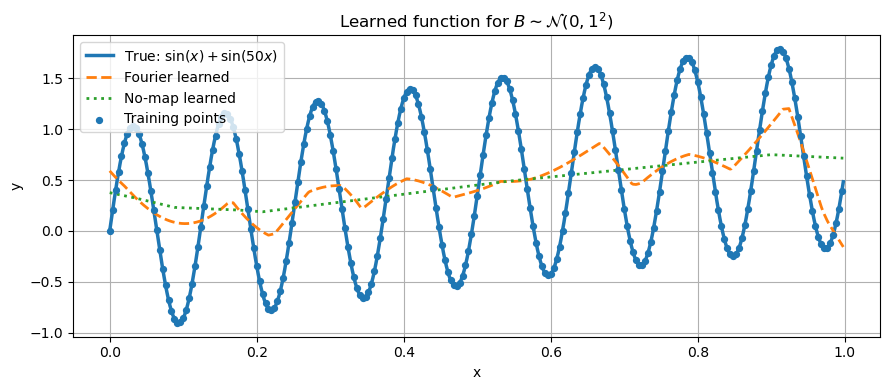


Maximum errors for sigma = 1 at 40,000 GD steps
---------------------------------------------
Fourier maximum signed (f_theta - y_true): 1.009214e+00 at x = 0.598000
Fourier maximum absolute |f_theta - y_true|:     1.022989e+00 at x = 0.534000
No-map maximum signed (f_theta - y_true):   1.134839e+00 at x = 0.094000
No-map maximum absolute |f_theta - y_true|:       1.134839e+00 at x = 0.094000



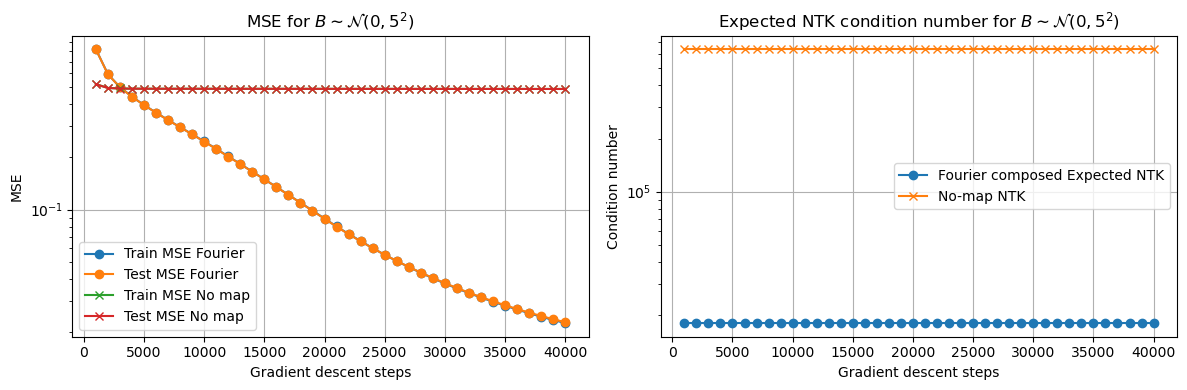

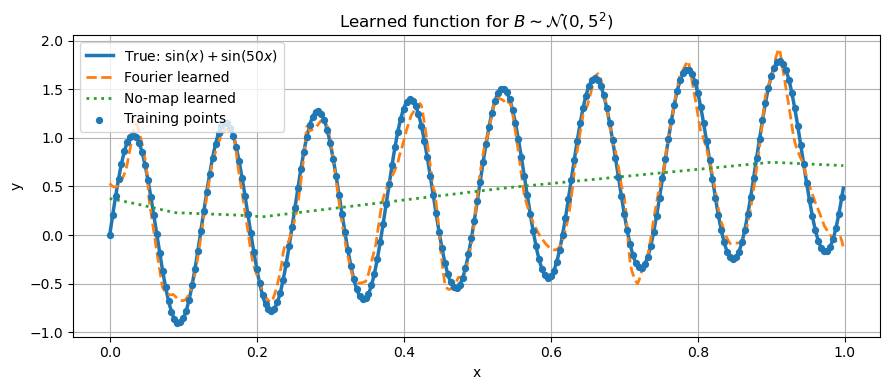


Maximum errors for sigma = 5 at 40,000 GD steps
---------------------------------------------
Fourier maximum signed (f_theta - y_true): 5.323427e-01 at x = 0.000000
Fourier maximum absolute |f_theta - y_true|:     6.100048e-01 at x = 0.998000
No-map maximum signed (f_theta - y_true):   1.134839e+00 at x = 0.094000
No-map maximum absolute |f_theta - y_true|:       1.134839e+00 at x = 0.094000



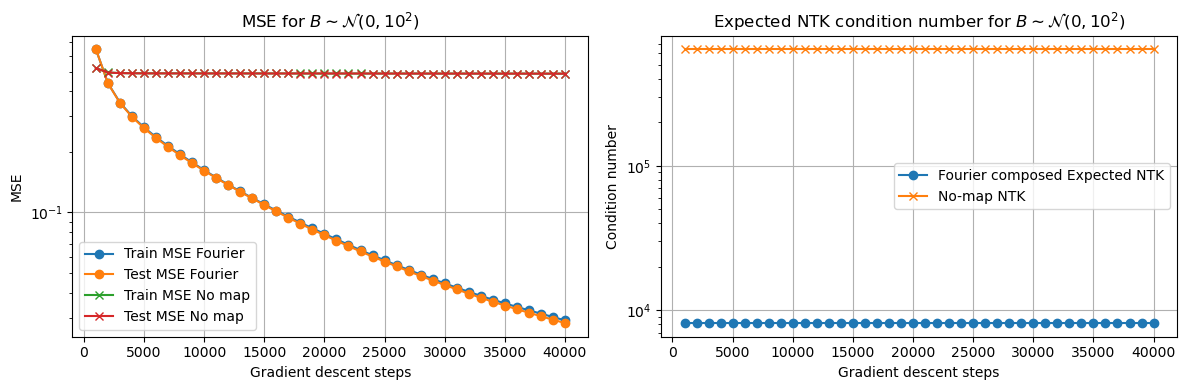

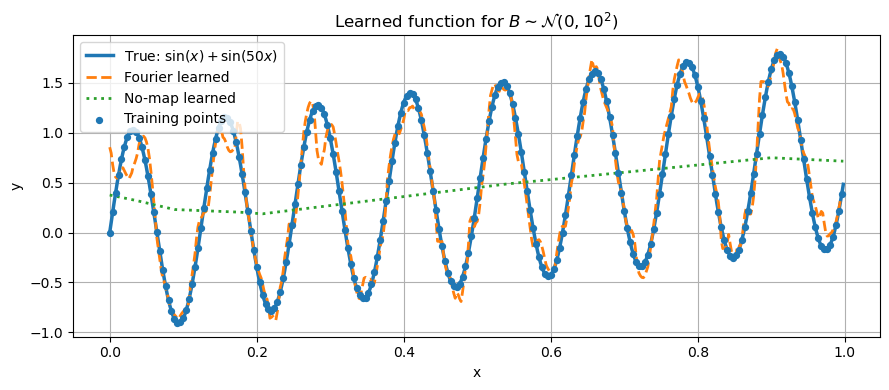


Maximum errors for sigma = 10 at 40,000 GD steps
---------------------------------------------
Fourier maximum signed (f_theta - y_true): 8.547124e-01 at x = 0.000000
Fourier maximum absolute |f_theta - y_true|:     8.547124e-01 at x = 0.000000
No-map maximum signed (f_theta - y_true):   1.134839e+00 at x = 0.094000
No-map maximum absolute |f_theta - y_true|:       1.134839e+00 at x = 0.094000



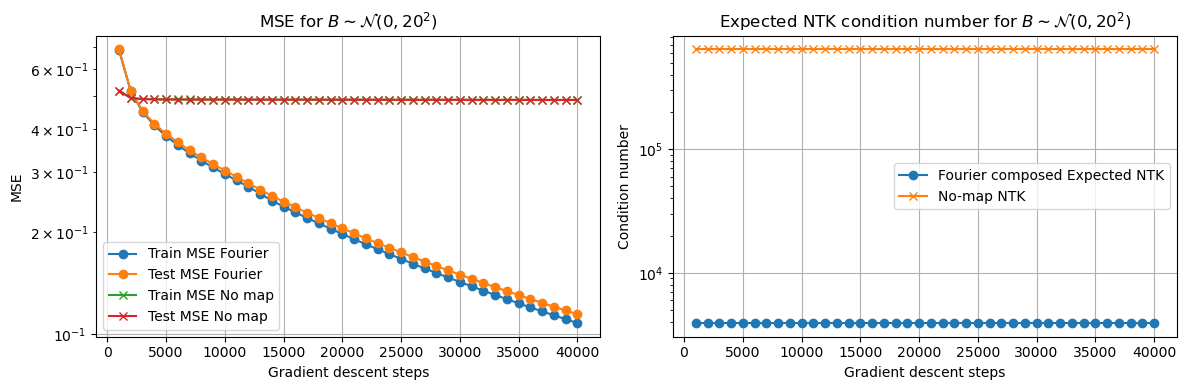

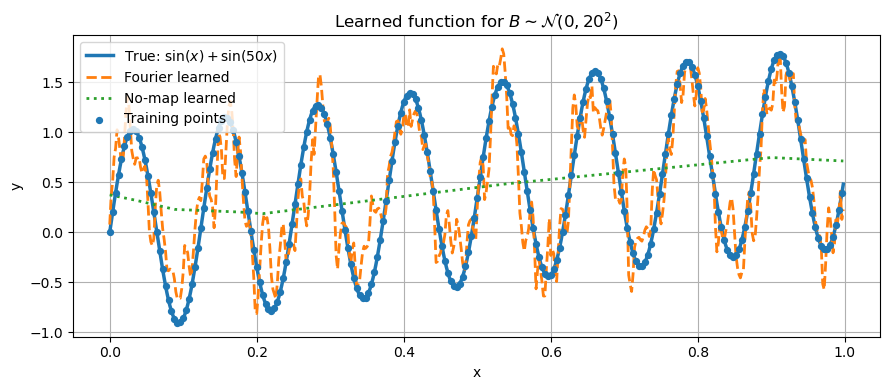


Maximum errors for sigma = 20 at 40,000 GD steps
---------------------------------------------
Fourier maximum signed (f_theta - y_true): 8.924195e-01 at x = 0.214000
Fourier maximum absolute |f_theta - y_true|:     9.398058e-01 at x = 0.268000
No-map maximum signed (f_theta - y_true):   1.134839e+00 at x = 0.094000
No-map maximum absolute |f_theta - y_true|:       1.134839e+00 at x = 0.094000



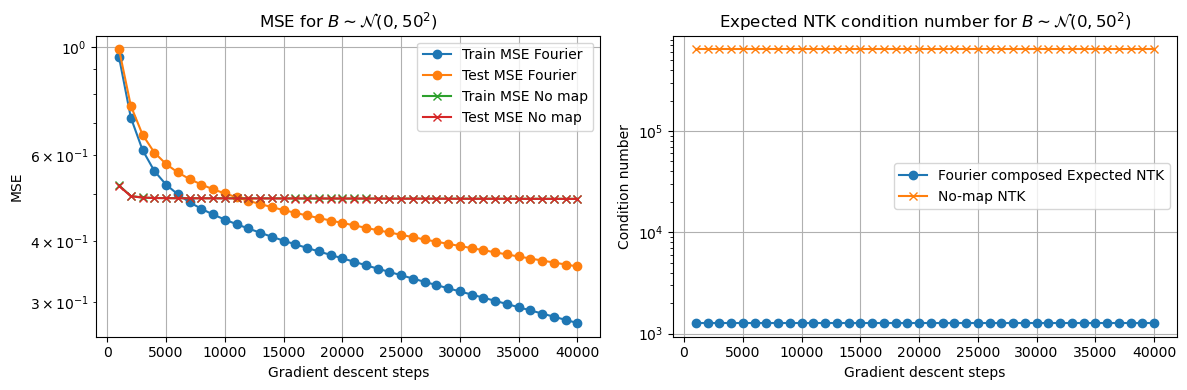

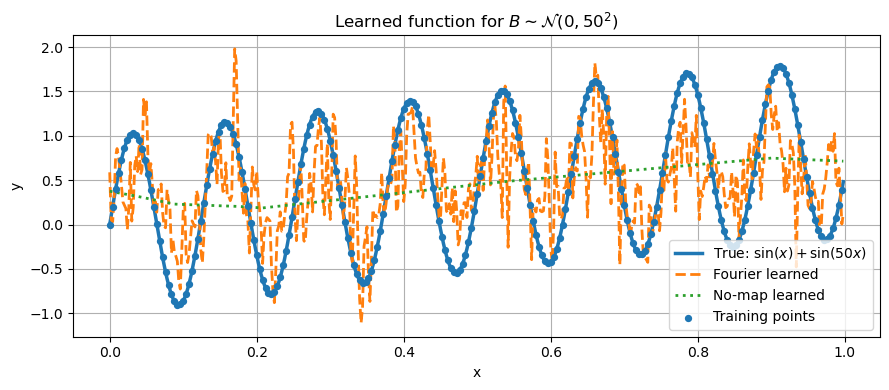


Maximum errors for sigma = 50 at 40,000 GD steps
---------------------------------------------
Fourier maximum signed (f_theta - y_true): 1.398607e+00 at x = 0.594000
Fourier maximum absolute |f_theta - y_true|:     1.694294e+00 at x = 0.542000
No-map maximum signed (f_theta - y_true):   1.134839e+00 at x = 0.094000
No-map maximum absolute |f_theta - y_true|:       1.134839e+00 at x = 0.094000



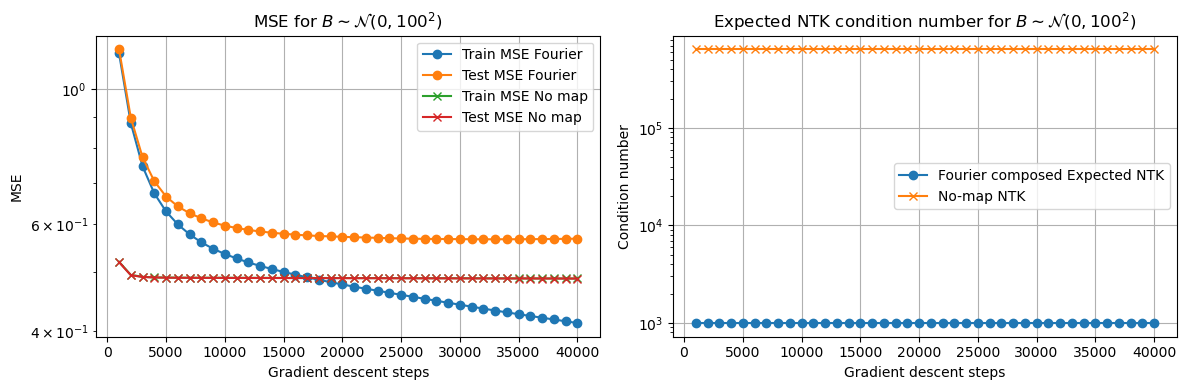

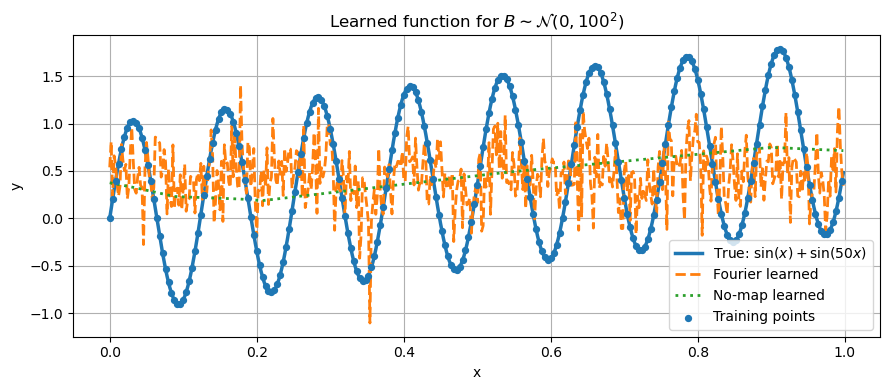


Maximum errors for sigma = 100 at 40,000 GD steps
---------------------------------------------
Fourier maximum signed (f_theta - y_true): 1.828784e+00 at x = 0.222000
Fourier maximum absolute |f_theta - y_true|:     1.828784e+00 at x = 0.222000
No-map maximum signed (f_theta - y_true):   1.134839e+00 at x = 0.094000
No-map maximum absolute |f_theta - y_true|:       1.134839e+00 at x = 0.094000



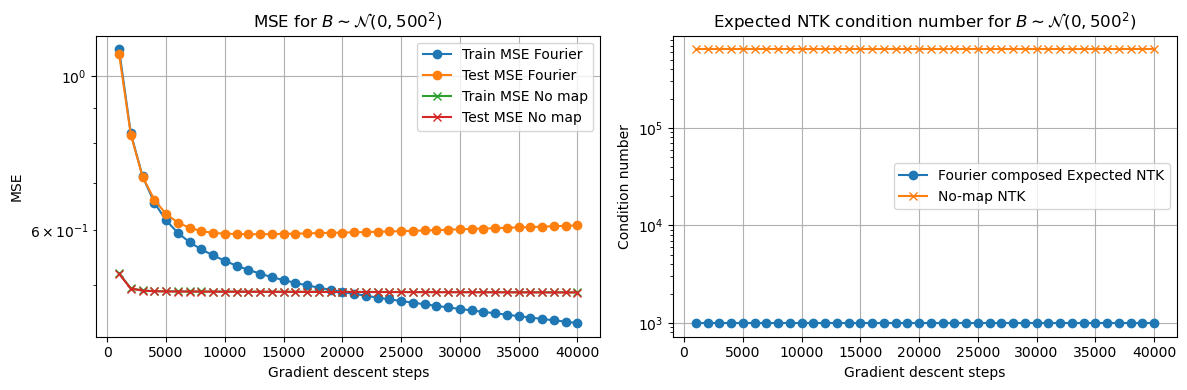

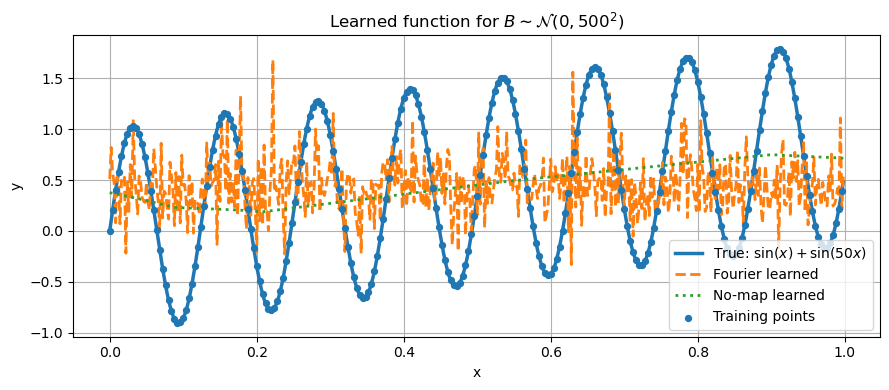


Maximum errors for sigma = 500 at 40,000 GD steps
---------------------------------------------
Fourier maximum signed (f_theta - y_true): 2.454848e+00 at x = 0.222000
Fourier maximum absolute |f_theta - y_true|:     2.454848e+00 at x = 0.222000
No-map maximum signed (f_theta - y_true):   1.134839e+00 at x = 0.094000
No-map maximum absolute |f_theta - y_true|:       1.134839e+00 at x = 0.094000



In [8]:
# ----- Condition number and MSE plots, also actual plots of true function vs learnt function as fourier feature training vs vanilla ----------

num_basis = 128
p = 0  # keeps a_j = 1
master_key = random.PRNGKey(0)

key_model_vanilla = random.fold_in(
    master_key,
    1,
)


X_train, y_train, X_test, y_test, X_all, y_all = make_data(
    n_total=500,
    train_every=2,
)

width=16
depth=2

print("Shapes")
print("------")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)
print("X_all:  ", X_all.shape)
print()

sigma_values = [0.1, 1, 5, 10, 20, 50, 100, 500]

for sigma_idx, sigma in enumerate(sigma_values):
    key_model = random.fold_in(master_key, 1)
    key_B = random.fold_in(master_key, sigma_idx + 100)

    B, a = make_fourier_params(
        num_basis=num_basis,
        sigma=sigma,
        key=key_B,
    )

    X_train_ff = fourier_features(X_train, B, a)
    X_test_ff = fourier_features(X_test, B, a)
    X_all_ff = fourier_features(X_all, B, a)

    X_train_n = X_train
    X_test_n = X_test
    X_all_n = X_all

    steps_list = []

    train_mse_ff_list = []
    test_mse_ff_list = []

    train_mse_n_list = []
    test_mse_n_list = []

    cond_ff_list = []
    cond_n_list = []
    #NTK INIT WITH INPUT SIZE OF TRAINING DATA
    #mlp_init_params=init_mlp_params(key_model,X_train_ff.shape[-1])
    true_NTK,_=analytic_ntk_matrix_2(X_train_ff)
    cond_true_NTK=condition_number_psd(true_NTK, rtol=1e-9)[0]

    #refactor makes faster but requires init--> could make this better by not toggling
    params_ff = init_mlp_params(
        key_model,
        input_dim=X_train_ff.shape[-1],
        width=width,
        depth=depth,
        use_bias=True,
    )

    params_n = init_mlp_params(
        key_model_vanilla,
        input_dim=X_train.shape[-1],
        width=width,
        depth=depth,
        use_bias=use_bias,
    )
    
    for step_idx in range(1, 41):
        n_steps = 1000 * step_idx
        # Fourier features model
        params_ff, _ = train_checkpoint(
        params_ff,
        X_train_ff,
        y_train,
        number_of_steps=1000,
        lr=1e-3
    )
    
        train_mse_ff = float(
        mse_loss(
            params_ff,
            X_train_ff,
            y_train,
            sigma_w_sq=2.0,
            sigma_b_sq=1.0,
            use_bias=True,
        )
    )
    
        test_mse_ff = float(
        mse_loss(
            params_ff,
            X_test_ff,
            y_test,
            sigma_w_sq=2.0,
            sigma_b_sq=1.0,
            use_bias=True,
        )
    )

        y_pred_all_ff = mlp_apply(
            params_ff,
            X_all_ff,
        )
        #new call for computation of expected NTK
        K_comp_ff,_ = analytic_ntk_matrix_2(X_train_ff)

        cond_ff, eigvals_ff = condition_number_psd(
            K_comp_ff
        )

        # No Fourier features model
        params_n, _ = train_checkpoint(
        params_n,
        X_train_n,
        y_train,
        number_of_steps=1000,
        lr=1e-3,
    )
    
        train_mse_n = float(
        mse_loss(
            params_n,
            X_train_n,
            y_train,
            sigma_w_sq=2.0,
            sigma_b_sq=1.0,
            use_bias=True,
        )
    )
    
        test_mse_n = float(
        mse_loss(
            params_n,
            X_test_n,
            y_test,
            sigma_w_sq=2.0,
            sigma_b_sq=1.0,
            use_bias=True,
        )
    )

        y_pred_all_n = mlp_apply(
            params_n,
            X_all_n,
        )
        #THIS HAS BEEN CHANGED AS NTK IS AT INITIALISATION
        '''
        # NTK condition number for no Fourier feature map
        K_comp_n, _ = empirical_ntk_matrix(
            params_n,
            X_train_n,
        )

        cond_n, eigvals_n = condition_number_psd(
            K_comp_n
        )
        '''
        #This now computes exptected NTK and so mlp_init is not needed
        #mlp_init_params=init_mlp_params(key_model,X_train_n.shape[-1])
        #K_comp_n,_=empirical_ntk_matrix(mlp_init_params,X_train_n)
        K_comp_n,_=analytic_ntk_matrix_2(X_train_n)
        cond_n,eigenvals_n=condition_number_psd(K_comp_n, rtol=1e-9)
        
        steps_list.append(n_steps)

        train_mse_ff_list.append(train_mse_ff)
        test_mse_ff_list.append(test_mse_ff)

        train_mse_n_list.append(train_mse_n)
        test_mse_n_list.append(test_mse_n)

        cond_ff_list.append(float(cond_ff))
        cond_n_list.append(float(cond_n))

    title = bj_title(
        sigma=sigma,
        b_tog=True,
    )

    # =====================================================
    # Plot 1: MSE and condition number
    # =====================================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 4),
    )

    # Left: MSE plot
    axes[0].plot(
        steps_list,
        train_mse_ff_list,
        marker="o",
        label="Train MSE Fourier",
    )

    axes[0].plot(
        steps_list,
        test_mse_ff_list,
        marker="o",
        label="Test MSE Fourier",
    )

    axes[0].plot(
        steps_list,
        train_mse_n_list,
        marker="x",
        label="Train MSE No map",
    )

    axes[0].plot(
        steps_list,
        test_mse_n_list,
        marker="x",
        label="Test MSE No map",
    )

    axes[0].set_xlabel(
        "Gradient descent steps"
    )

    axes[0].set_ylabel(
        "MSE"
    )

    axes[0].set_yscale(
        "log"
    )

    axes[0].set_title(
        "MSE for " + title
    )

    axes[0].legend()
    axes[0].grid(True)
    axes[1].plot(
        steps_list,
        [cond_true_NTK for i in range(len(cond_ff_list))],
        marker="o",
        label="Fourier composed Expected NTK",
    )

    axes[1].plot(
        steps_list,
        cond_n_list,
        marker="x",
        label="No-map NTK",
    )

    axes[1].set_xlabel(
        "Gradient descent steps"
    )

    axes[1].set_ylabel(
        "Condition number"
    )

    axes[1].set_yscale(
        "log"
    )

    axes[1].set_title(
        "Expected NTK condition number for " + title
    )

    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    # =====================================================
    # Plot 2: learned functions against
    # sin(x) + sin(50x)
    # =====================================================

    x_plot = X_all.reshape(-1)

    y_true_plot = (
        jnp.sin(x_plot)
        + jnp.sin(50 * x_plot)
    )

    y_pred_ff_plot = y_pred_all_ff.reshape(-1)
    y_pred_n_plot = y_pred_all_n.reshape(-1)

    plt.figure(
        figsize=(9, 4)
    )

    plt.plot(
        x_plot,
        y_true_plot,
        linewidth=2.5,
        label=r"True: $\sin(x) + \sin(50x)$",
    )

    plt.plot(
        x_plot,
        y_pred_ff_plot,
        linewidth=2,
        linestyle="--",
        label="Fourier learned",
    )

    plt.plot(
        x_plot,
        y_pred_n_plot,
        linewidth=2,
        linestyle=":",
        label="No-map learned",
    )

    plt.scatter(
        X_train.reshape(-1),
        y_train.reshape(-1),
        s=18,
        label="Training points",
        zorder=3,
    )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(
        "Learned function for " + title
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # =====================================================
    # ADDED:
    # Maximum pointwise errors at the final checkpoint
    #
    # The final inner-loop iteration has:
    # n_steps = 20,000.
    #
    # error_all = f_theta(X_all) - y_all
    # =====================================================

    y_all_flat = jnp.asarray(
        y_all
    ).reshape(-1)

    x_all_flat = jnp.asarray(
        X_all
    ).reshape(-1)

    error_all_ff = (
        y_pred_ff_plot - y_all_flat
    )

    error_all_n = (
        y_pred_n_plot - y_all_flat
    )

    # Maximum signed errors:
    #
    # max_x [f_theta(x) - y_true(x)]
    max_signed_idx_ff = int(
        jnp.argmax(error_all_ff)
    )

    max_signed_idx_n = int(
        jnp.argmax(error_all_n)
    )

    # Maximum absolute errors:
    #
    # max_x |f_theta(x) - y_true(x)|
    max_abs_idx_ff = int(
        jnp.argmax(jnp.abs(error_all_ff))
    )

    max_abs_idx_n = int(
        jnp.argmax(jnp.abs(error_all_n))
    )

    print()
    print(
        f"Maximum errors for sigma = {sigma} "
        f"at {n_steps:,} GD steps"
    )

    print(
        "---------------------------------------------"
    )

    print(
        "Fourier maximum signed "
        "(f_theta - y_true): "
        f"{float(error_all_ff[max_signed_idx_ff]):.6e} "
        f"at x = "
        f"{float(x_all_flat[max_signed_idx_ff]):.6f}"
    )

    print(
        "Fourier maximum absolute "
        "|f_theta - y_true|:     "
        f"{float(jnp.abs(error_all_ff[max_abs_idx_ff])):.6e} "
        f"at x = "
        f"{float(x_all_flat[max_abs_idx_ff]):.6f}"
    )

    print(
        "No-map maximum signed "
        "(f_theta - y_true):   "
        f"{float(error_all_n[max_signed_idx_n]):.6e} "
        f"at x = "
        f"{float(x_all_flat[max_signed_idx_n]):.6f}"
    )

    print(
        "No-map maximum absolute "
        "|f_theta - y_true|:       "
        f"{float(jnp.abs(error_all_n[max_abs_idx_n])):.6e} "
        f"at x = "
        f"{float(x_all_flat[max_abs_idx_n]):.6f}"
    )

    print()

In [10]:

import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import random


def bj_title(sigma, b_tog=True):
    """
    Function for graph titles.
    """
    if b_tog:
        return rf"$B \sim \mathcal{{N}}(0, {sigma}^2)$"
    else:
        return r"$b_j = j$"

## Below is a refactored version of one of the older cells to track error in Fourier Space.

## SECTION 2

In [28]:
def error_fft_magnitude(y_pred, y_true):
    """
    Compute the one-sided regular rFFT magnitude spectrum. This only returns positive 
    frequencies so won't be able to form a basis of C^N. There's another function to do 
    that if needs be.
    
    Returns a list where each index is the ith error (mangnitude of fourier coeff) of the ith frequency, of form 2pi*i
    """
    error = y_pred.reshape(-1) - y_true.reshape(-1)
    ehat = jnp.fft.rfft(error)

    return jnp.abs(ehat) / error.shape[0]


# ============================================================
# Error transform at specified angular frequencies
#
# omega = 2*pi*b
# ============================================================
def error_at_angular_frequencies(
    y_pred,
    y_true,
    x,
    omega_values,
):
    """
    Evaluate the error Fourier transform directly at specified
    angular frequencies omega. I.e this takes in omega, say 1 or
    50 and outputs the error associated with the angular frequency 
    1 or 50, in line with sin(1x)+sin(50x) where 1 and 50 are angular
    frequencies as opposed to frequencies

    ehat(omega)
        = (1/N) sum_n e(x_n) exp(-i omega x_n)

    If omega values are of form 2*k*pi for natural number k, will do the same thing as error_fft_mag but return a compressed list   

    This returns the error component of the sampled frequencies, but only gets the exact error of said freq if they have bj in naturals
    """
    error = (
        y_pred.reshape(-1)
        - y_true.reshape(-1)
    )

    x = x.reshape(-1)

    omega_values = jnp.asarray(
        omega_values,
        dtype=x.dtype,
    )

    basis = jnp.exp(
        -1j
        * x[:, None]
        * omega_values[None, :]
    )

    coefficients = jnp.mean(
        error[:, None] * basis,
        axis=0,
    )

    return jnp.abs(coefficients)

def nearest_integer_b_omegas(
    omega_values,
    allow_zero=True,
):
    """
    Snap non-negative angular frequencies to the nearest
    omega = 2*pi*b, where b is a non-negative integer.

    This isn't really used anymore but was my attempt to be able to toggle using 2pi values or just raw 1,50.
    """
    omega_values = jnp.asarray(omega_values)

    b_values = jnp.rint(
        omega_values / (2.0 * jnp.pi)
    ).astype(jnp.int32)

    if not allow_zero:
        b_values = jnp.maximum(
            b_values,
            1,
        )

    return (
        2.0
        * jnp.pi
        * b_values.astype(omega_values.dtype)
    )

Shapes
------
X_train: (1500, 1)
y_train: (1500, 1)
X_test:  (1500, 1)
y_test:  (1500, 1)
X_all:   (3000, 1)



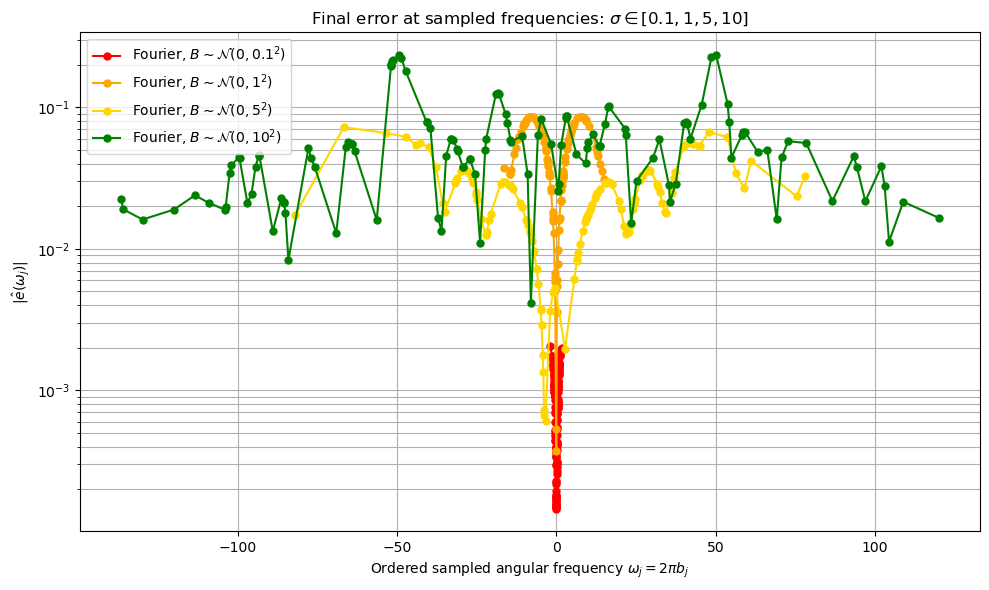

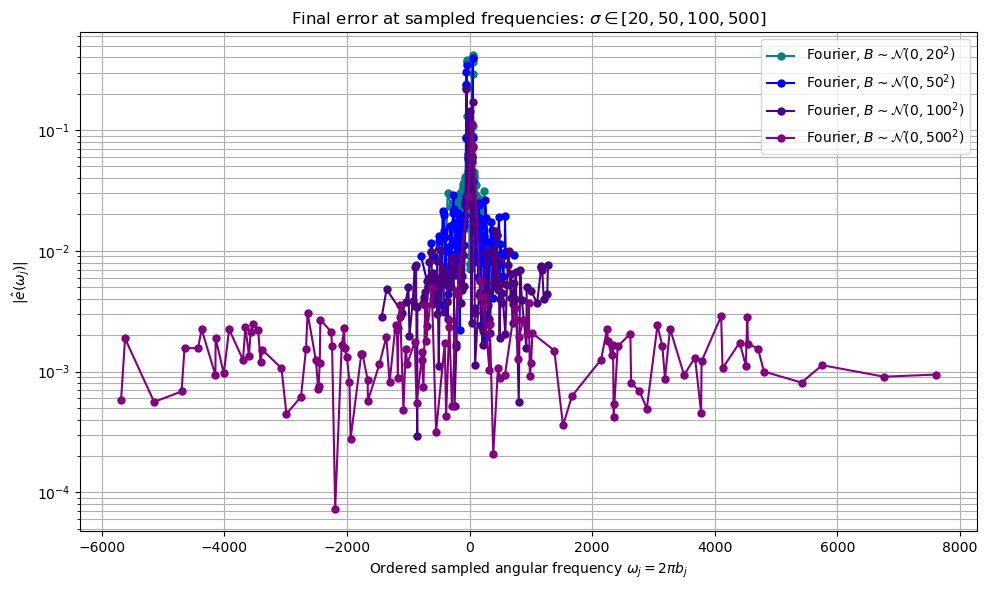

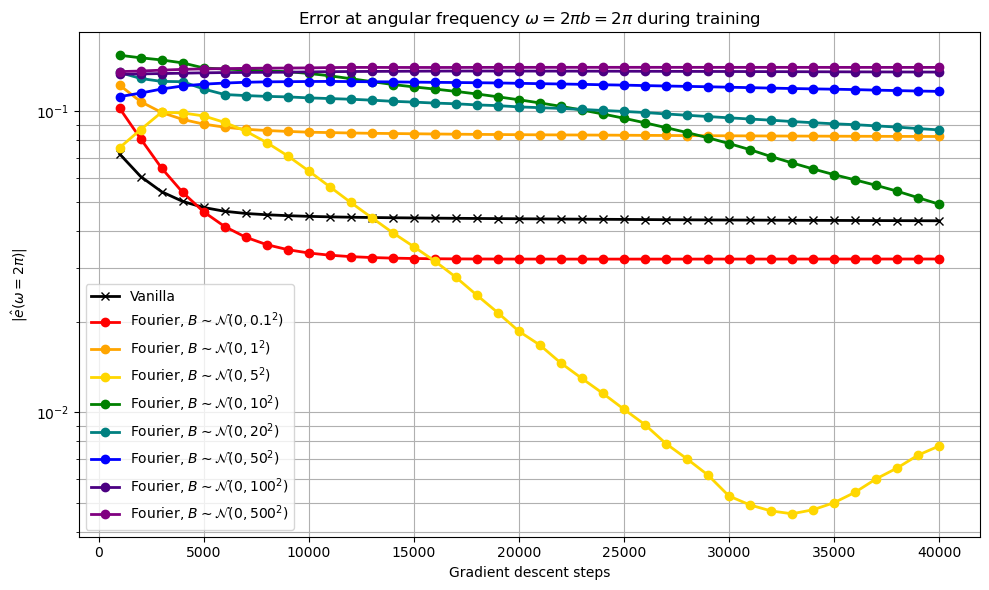

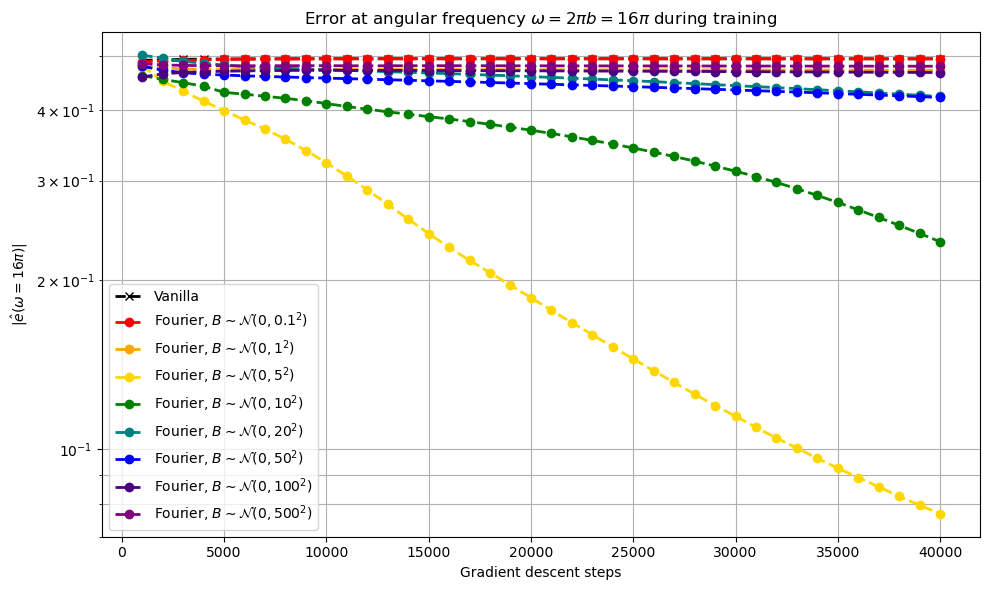

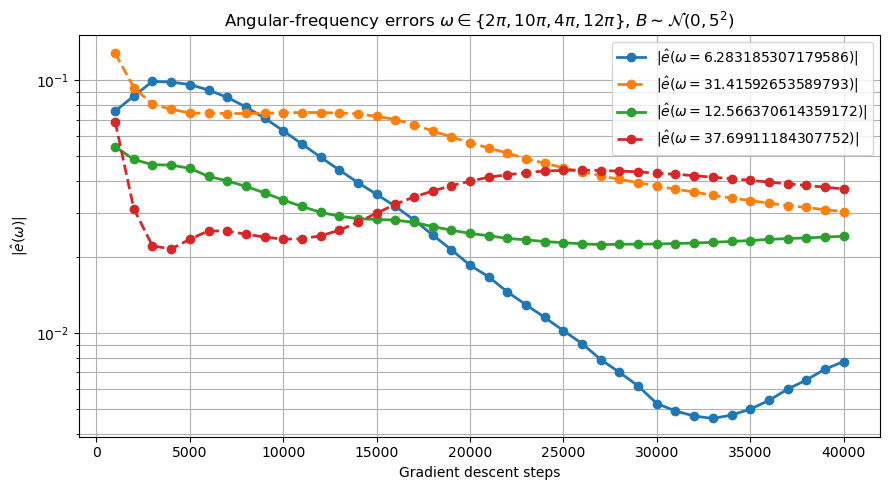

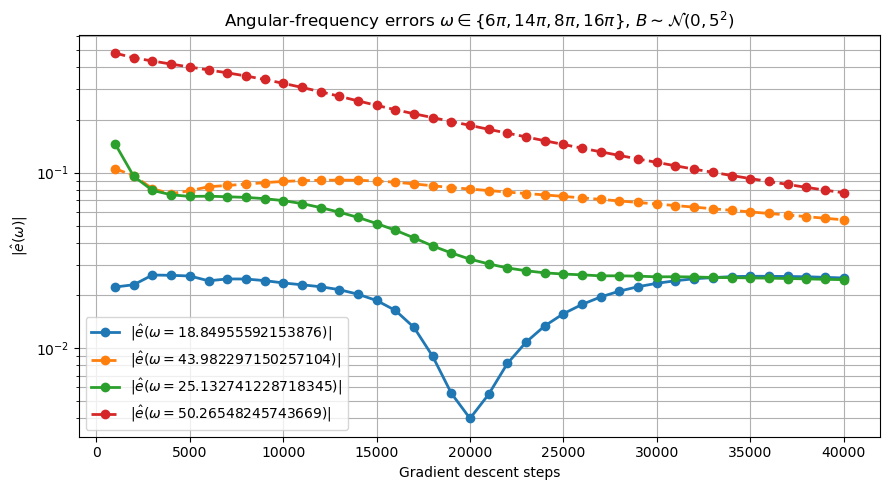


MSE recovered from final regular rFFT spectra
---------------------------------------------
Vanilla: 4.9711166793e-01
B ~ N(0, 0.1^2): 4.9481827635e-01
B ~ N(0, 1^2): 4.8671670247e-01
B ~ N(0, 5^2): 5.6032858512e-02
B ~ N(0, 10^2): 2.1127682931e-01
B ~ N(0, 20^2): 4.3676656082e-01
B ~ N(0, 50^2): 4.4948095648e-01
B ~ N(0, 100^2): 5.0921999566e-01
B ~ N(0, 500^2): 5.2621592644e-01


In [11]:
# ============================================================
# Settings
# ============================================================
num_basis = 128
p = 0
master_key = random.PRNGKey(0)

use_bias=True 
sigma_w_sq=2
sigma_b_sq=1

key_model_vanilla = random.fold_in(
    master_key,
    1,
)

sigma_values = [0.1, 1, 5, 10, 20, 50, 100, 500]

# These are now angular frequencies omega, not FFT-bin indices.
sigma5_plot1_omegas = [2*np.pi, 10*np.pi, 4*np.pi, 12*np.pi]
sigma5_plot2_omegas = [6*np.pi, 14*np.pi, 8*np.pi, 16*np.pi]

low_omegas = [2*np.pi, 4*np.pi, 6*np.pi, 8*np.pi]
high_omegas =[10*np.pi, 12*np.pi, 14*np.pi, 16*np.pi]

all_selected_omegas = (
    sigma5_plot1_omegas
    + sigma5_plot2_omegas
)


# ============================================================
# Data

#note, need bj not omega, but also need to accomodate for -ve values,
#for max sigma 500, omega was a bit under 8000, so bj needs to be a bit over a thousand, so as then bj_max about 1200, need N/2 > 1200
#done 3000 for safe keeping, should run faster

# ============================================================
X_train, y_train, X_test, y_test, X_all, y_all = make_data(
    n_total=3000,
    train_every=2,
)

print("Shapes")
print("------")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)
print("X_all:  ", X_all.shape)
print()

x_plot = X_all.reshape(-1)
y_true_plot = y_all.reshape(-1)

# ============================================================
# Storage
# ============================================================
results = {}
vanilla_done = False


# ============================================================
# Training
# ============================================================
for sigma_idx, sigma in enumerate(sigma_values):
    key_model = random.fold_in(
        master_key,
        1,
    )

    key_B = random.fold_in(
        master_key,
        sigma_idx + 100,
    )

    B, a = make_fourier_params(
        num_basis=num_basis,
        sigma=sigma,
        key=key_B,
    )

    X_train_ff = fourier_features(
        X_train,
        B,
        a,
    )

    X_test_ff = fourier_features(
        X_test,
        B,
        a,
    )

    X_all_ff = fourier_features(
        X_all,
        B,
        a,
    )
    #this is just a formality to rename them so they're correctly fed into vanilla no ff
    X_train_n = X_train
    X_test_n = X_test
    X_all_n = X_all

    # --------------------------------------------------------
    # Actual sampled frequencies
    #
    # omega_j = 2*pi*b_j
    # --------------------------------------------------------
    b_sampled = B.reshape(-1)

    omega_sampled = (
        2.0
        * jnp.pi
        * b_sampled
    )

    omega_sort_idx = jnp.argsort(
        omega_sampled
    )

    omega_sorted = omega_sampled[
        omega_sort_idx
    ]
    #please note this is not a basis since the bj are very unlikely to all be integers
    #code or maths does not 
    sampled_frequency_basis = jnp.exp(
        -1j
        * x_plot[:, None]
        * omega_sampled[None, :]
    )

    steps_list = []

    # Track angular frequencies omega=1 and omega=50
    #THIS TRACKS THE CLOSEST NOW, SINCE THESE WON'T BE ORTHOG
    #there is a toggle to choose if omega =1 aligns more with 2pi or 0
    ehat_omega1_ff_list = []
    ehat_omega50_ff_list = []

    ehat_omega1_n_list = []
    ehat_omega50_n_list = []

    # Additional angular frequencies for sigma=5
    selected_omega_history = {
        omega: []
        for omega in all_selected_omegas
    }

    final_error_spectrum_ff = None
    final_error_spectrum_n = None

    final_error_at_sampled_freqs = None
    #I doubled this to see the convergence behaviour a bit better as we don't get an exact plateau at the moment--> high GD steps
    #41 is very slow put back to 20k steps as many other things to run right now!

    params_ff = init_mlp_params(
        key_model,
        input_dim=X_train_ff.shape[-1],
        width=4,
        depth=2,
        use_bias=True,
    )

    params_n = init_mlp_params(
    key_model_vanilla,
    input_dim=X_train.shape[-1],
    width=4,
    depth=2,
    use_bias=use_bias,
    )
    
    for step_idx in range(1, 41):
        n_steps = 1000 * step_idx
        # ----------------------------------------------------
        # Fourier-feature model
        # ----------------------------------------------------

        # Fourier features model
        params_ff, _ = train_checkpoint(
        params_ff,
        X_train_ff,
        y_train,
        number_of_steps=1000,
        lr=1e-3,
        )
    
        train_mse_ff = float(
        mse_loss(
            params_ff,
            X_train_ff,
            y_train,
            sigma_w_sq=2.0,
            sigma_b_sq=1.0,
            use_bias=True,
        )
    )
    
        test_mse_ff = float(
        mse_loss(
            params_ff,
            X_test_ff,
            y_test,
            sigma_w_sq=2.0,
            sigma_b_sq=1.0,
            use_bias=True,
        )
    )

        y_pred_all_ff = mlp_apply(
            params_ff,
            X_all_ff,
        ).reshape(-1)

        error_ff = (
            y_pred_all_ff
            - y_true_plot
        )

        #this now corresponds to bj=1 and 8. this does not align exactly with x and 50x
        #new nearest code
        omega_orthog1=nearest_integer_b_omegas([1,50],False)
   
        omega1_omega50_values = (
            error_at_angular_frequencies(
                y_pred_all_ff,
                y_true_plot,
                x_plot,
                omega_orthog1,
            )
        )

        ehat_omega1_ff_list.append(
            float(
                omega1_omega50_values[0]
            )
        )

        ehat_omega50_ff_list.append(
            float(
                omega1_omega50_values[1]
            )
        )
        #THE SAME FIX
        omega_orthog_2=nearest_integer_b_omegas(all_selected_omegas,False)
        
        # ----------------------------------------------------
        # Additional angular frequencies for sigma=5
        # ----------------------------------------------------
        if sigma == 5:
            selected_values = (
                error_at_angular_frequencies(
                    y_pred_all_ff,
                    y_true_plot,
                    x_plot,
                    omega_orthog_2,
                )
            )

            for omega, value in zip(
                all_selected_omegas,
                selected_values,
            ):
                selected_omega_history[
                    omega
                ].append(
                    float(value)
                )

        # ----------------------------------------------------
        # Regular rFFT retained only for Parseval
        # ----------------------------------------------------
        error_mag_ff = error_fft_magnitude(
            y_pred_all_ff,
            y_true_plot,
        )

        final_error_spectrum_ff = (
            error_mag_ff
        )

        # ----------------------------------------------------
        # Error evaluated at the actual sampled omega_j values
        #note that this is a tad misleading as you won't be able to get precise errors
        #since aren't orthog
        # ----------------------------------------------------
        error_at_sampled_freqs = jnp.abs(
            jnp.mean(
                error_ff[:, None]
                * sampled_frequency_basis,
                axis=0,
            )
        )

        final_error_at_sampled_freqs = (
            error_at_sampled_freqs[
                omega_sort_idx
            ]
        )

        steps_list.append(n_steps)

        # ----------------------------------------------------
        # Vanilla model
        # ----------------------------------------------------
        if not vanilla_done:
            params_n, _ = train_checkpoint(
            params_n,
            X_train_n,
            y_train,
            number_of_steps=1000,
            lr=1e-3,
        )
        
            train_mse_n = float(
            mse_loss(
                params_n,
                X_train_n,
                y_train,
                sigma_w_sq=2.0,
                sigma_b_sq=1.0,
                use_bias=True,
            )
        )
        
            test_mse_n = float(
            mse_loss(
                params_n,
                X_test_n,
                y_test,
                sigma_w_sq=2.0,
                sigma_b_sq=1.0,
                use_bias=True,
            )
        )

            y_pred_all_n = mlp_apply(
                params_n,
                X_all_n,
            ).reshape(-1)

            vanilla_omega_values = (
                error_at_angular_frequencies(
                    y_pred_all_n,
                    y_true_plot,
                    x_plot,
                    [2*np.pi, 16*np.pi],
                )
            )

            ehat_omega1_n_list.append(
                float(
                    vanilla_omega_values[0]
                )
            )

            ehat_omega50_n_list.append(
                float(
                    vanilla_omega_values[1]
                )
            )

            # Regular rFFT only for Parseval
            error_mag_n = error_fft_magnitude(
                y_pred_all_n,
                y_true_plot,
            )

            final_error_spectrum_n = (
                error_mag_n
            )

    # --------------------------------------------------------
    # Store Fourier-feature results
    # --------------------------------------------------------
    results[sigma] = {
        "steps": steps_list,

        # Angular-frequency histories
        "ehat_omega1":
            ehat_omega1_ff_list,

        "ehat_omega50":
            ehat_omega50_ff_list,

        # Actual sampled frequencies
        "omega_sorted":
            omega_sorted,

        "final_error_at_sampled_freqs":
            final_error_at_sampled_freqs,

        # Regular rFFT retained for Parseval only
        "final_error_spectrum":
            final_error_spectrum_ff,
    }

    if sigma == 5:
        results[sigma][
            "selected_omega_history"
        ] = selected_omega_history

    # --------------------------------------------------------
    # Store vanilla once
    # --------------------------------------------------------
    if not vanilla_done:
        results["vanilla"] = {
            "steps": steps_list,

            "ehat_omega1":
                ehat_omega1_n_list,

            "ehat_omega50":
                ehat_omega50_n_list,

            "final_error_spectrum":
                final_error_spectrum_n,
        }

        vanilla_done = True


# ============================================================
# Plot settings
# ============================================================
colors = {
    "vanilla": "black",
    0.1: "red",
    1: "orange",
    5: "gold",
    10: "green",
    20: "teal",
    50: "blue",
    100: "indigo",
    500: "purple",
}

split_idx = len(sigma_values) // 2

sigma_values_first = (
    sigma_values[:split_idx]
)

sigma_values_second = (
    sigma_values[split_idx:]
)


# ============================================================
# Plot 1: actual sampled omega_j, first sigma group
#again won't get their exact error decomp from this as not orthog
# ============================================================
plt.figure(figsize=(10, 6))

for sigma in sigma_values_first:
    title = bj_title(
        sigma=sigma,
        b_tog=True,
    )

    plt.semilogy(
        results[sigma]["omega_sorted"],
        results[sigma][
            "final_error_at_sampled_freqs"
        ],
        color=colors[sigma],
        marker="o",
        markersize=5,
        label=rf"Fourier, {title}",
    )

plt.xlabel(
    r"Ordered sampled angular frequency "
    r"$\omega_j=2\pi b_j$"
)

plt.ylabel(
    r"$|\hat e(\omega_j)|$"
)

plt.title(
    r"Final error at sampled frequencies: "
    rf"$\sigma \in {sigma_values_first}$"
)

plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.show()


# ============================================================
# Plot 2: actual sampled omega_j, second sigma group
#same applies here as in 1
# ============================================================
plt.figure(figsize=(10, 6))

for sigma in sigma_values_second:
    title = bj_title(
        sigma=sigma,
        b_tog=True,
    )

    plt.semilogy(
        results[sigma]["omega_sorted"],
        results[sigma][
            "final_error_at_sampled_freqs"
        ],
        color=colors[sigma],
        marker="o",
        markersize=5,
        label=rf"Fourier, {title}",
    )

plt.xlabel(
    r"Ordered sampled angular frequency "
    r"$\omega_j=2\pi b_j$"
)

plt.ylabel(
    r"$|\hat e(\omega_j)|$"
)

plt.title(
    r"Final error at sampled frequencies: "
    rf"$\sigma \in {sigma_values_second}$"
)

plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.show()


# ============================================================
# Plot 3: error at angular frequency omega=2pi

#this used to be 1 but was changed to be closest to and not 0
#so that has a valid orthonormal basis.

# ============================================================
plt.figure(figsize=(10, 6))

plt.semilogy(
    results["vanilla"]["steps"],
    results["vanilla"]["ehat_omega1"],
    color=colors["vanilla"],
    linestyle="-",
    marker="x",
    linewidth=2,
    label="Vanilla",
)

for sigma in sigma_values:
    title = bj_title(
        sigma=sigma,
        b_tog=True,
    )

    plt.semilogy(
        results[sigma]["steps"],
        results[sigma]["ehat_omega1"],
        color=colors[sigma],
        linestyle="-",
        marker="o",
        linewidth=2,
        label=rf"Fourier, {title}",
    )

plt.xlabel("Gradient descent steps")

plt.ylabel(
    r"$|\hat e(\omega=2\pi)|$"
)

plt.title(
    r"Error at angular frequency "
    r"$\omega=2\pi b=2\pi$ during training"
)

plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.show()


# ============================================================
# Plot 4: error at angular frequency omega=16 pi (50.2)
# ============================================================
plt.figure(figsize=(10, 6))

plt.semilogy(
    results["vanilla"]["steps"],
    results["vanilla"]["ehat_omega50"],
    color=colors["vanilla"],
    linestyle="--",
    marker="x",
    linewidth=2,
    label="Vanilla",
)

for sigma in sigma_values:
    title = bj_title(
        sigma=sigma,
        b_tog=True,
    )

    plt.semilogy(
        results[sigma]["steps"],
        results[sigma]["ehat_omega50"],
        color=colors[sigma],
        linestyle="--",
        marker="o",
        linewidth=2,
        label=rf"Fourier, {title}",
    )

plt.xlabel("Gradient descent steps")

plt.ylabel(
    r"$|\hat e(\omega=16 \pi)|$"
)

plt.title(
    r"Error at angular frequency "
    r"$\omega=2\pi b=16 \pi$ during training"
)

plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.show()


# ============================================================
# Plot 5: sigma=5, omega=fixed 2 pi vals
#
# Low omega: solid
# High omega: dashed
# ============================================================
sigma_selected = 5

plt.figure(figsize=(9, 5))

for omega in sigma5_plot1_omegas:
    if omega in low_omegas:
        line_style = "-"
    else:
        line_style = "--"

    plt.semilogy(
        results[sigma_selected]["steps"],
        results[sigma_selected][
            "selected_omega_history"
        ][omega],
        linestyle=line_style,
        marker="o",
        linewidth=2,
        label=rf"$|\hat e(\omega={omega})|$",
    )

plt.xlabel("Gradient descent steps")

plt.ylabel(
    r"$|\hat e(\omega)|$"
)

plt.title(
    r"Angular-frequency errors "
    r"$\omega\in\{2\pi,10\pi,4\pi,12\pi \}$, "
    r"$B\sim\mathcal{N}(0,5^2)$"
)

plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.show()


# ============================================================
# Plot 6: sigma=5, omega=fixed 2pi vals
# ============================================================
plt.figure(figsize=(9, 5))

for omega in sigma5_plot2_omegas:
    if omega in low_omegas:
        line_style = "-"
    else:
        line_style = "--"

    plt.semilogy(
        results[sigma_selected]["steps"],
        results[sigma_selected][
            "selected_omega_history"
        ][omega],
        linestyle=line_style,
        marker="o",
        linewidth=2,
        label=rf"$|\hat e(\omega={omega})|$",
    )

plt.xlabel("Gradient descent steps")

plt.ylabel(
    r"$|\hat e(\omega)|$"
)

plt.title(
    r"Angular-frequency errors "
    r"$\omega\in\{6\pi,14\pi,8\pi,16\pi \}$, "
    r"$B\sim\mathcal{N}(0,5^2)$"
)

plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.show()


# ============================================================
# Parseval MSE from the regular rFFT
#
# This must remain based on the evenly spaced FFT bins.
# ============================================================
print("\nMSE recovered from final regular rFFT spectra")
print("---------------------------------------------")

mag = results["vanilla"]["final_error_spectrum"]
#double to account for negative values (2jnp.sum)
vanilla_mse_from_fft = (
    mag[0] ** 2
    + mag[-1] ** 2
    + 2*jnp.sum(
        mag[1:-1] ** 2
    )
)

print(
    f"Vanilla: "
    f"{float(vanilla_mse_from_fft):.10e}"
)

for sigma in sigma_values:
    mag = results[sigma][
        "final_error_spectrum"
    ]
    #double to account for negative values (2jnp.sum)
    mse_from_fft = (
        mag[0] ** 2
        + mag[-1] ** 2
        + 2*jnp.sum(
            mag[1:-1] ** 2
        )
    )

    print(
        f"B ~ N(0, {sigma}^2): "
        f"{float(mse_from_fft):.10e}"
    )

In [29]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import random


def threshold_eigvals(eigvals, tol_factor=1e-9):
    """
    Remove eigenvalues below a tolerance relative to the largest eigenvalue. 

    Parameters
    ----------
    eigvals : array
        Eigenvalues to filter.
    tol_factor : float
        Relative tolerance. Eigenvalues below
        tol_factor * max_eigenvalue are removed.

    Returns
    -------
    array
        Retained eigenvalues sorted in descending order.
        No padding or duplication is performed.
    """
    # Remove small negative values caused by numerical error.
    eigvals = jnp.maximum(eigvals, 0.0)

    max_eig = jnp.max(eigvals)
    tol = tol_factor * max_eig

    kept = eigvals[eigvals >= tol]
    kept = jnp.sort(kept)[::-1]

    return kept


def effective_rank_from_eigvals(eigvals, eps=1e-12):
    """
    Compute effective rank from an array of eigenvalues.
    """
    eigvals = jnp.maximum(eigvals, 0.0)
    total = jnp.sum(eigvals)

    probs = eigvals / (total + eps)

    # Only retained positive eigenvalues are used.
    entropy = -jnp.sum(probs * jnp.log(probs + eps))

    return jnp.exp(entropy)

Vanilla eigenvalues surviving tolerance: 250
sigma=0.1: eigenvalues surviving tolerance=250
sigma=1: eigenvalues surviving tolerance=250
sigma=5: eigenvalues surviving tolerance=250
sigma=10: eigenvalues surviving tolerance=250
sigma=20: eigenvalues surviving tolerance=250
sigma=50: eigenvalues surviving tolerance=250
sigma=100: eigenvalues surviving tolerance=250
sigma=500: eigenvalues surviving tolerance=250


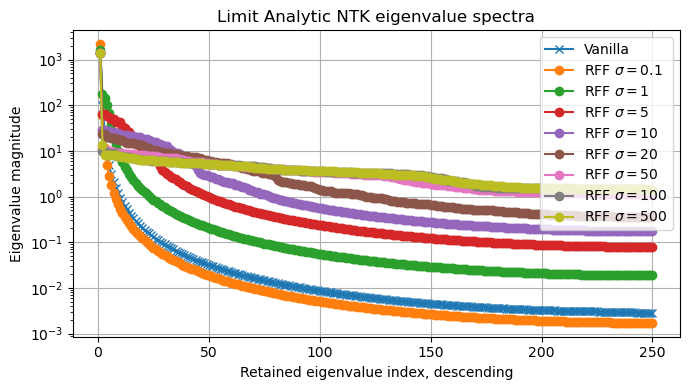

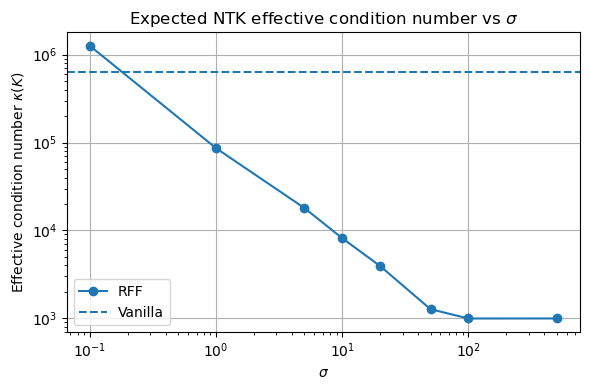

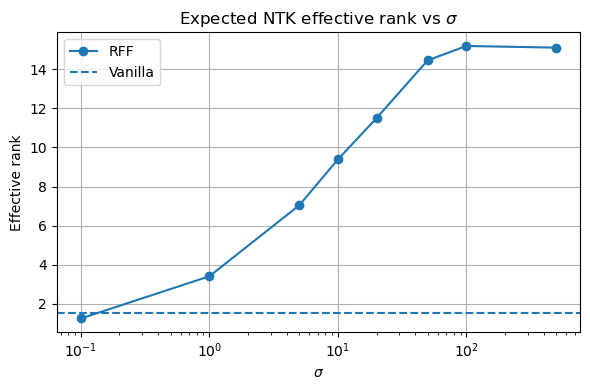


Vanilla condition number: 640267.1041238515
Vanilla effective rank: 1.5461472174770532
Vanilla retained eigenvalues: 250
sigma=0.1: condition number=1.254e+06, effective rank=1.250, retained eigenvalues=250
sigma=1: condition number=8.606e+04, effective rank=3.408, retained eigenvalues=250
sigma=5: condition number=1.802e+04, effective rank=7.037, retained eigenvalues=250
sigma=10: condition number=8.152e+03, effective rank=9.384, retained eigenvalues=250
sigma=20: condition number=3.924e+03, effective rank=11.500, retained eigenvalues=250
sigma=50: condition number=1.272e+03, effective rank=14.455, retained eigenvalues=250
sigma=100: condition number=9.970e+02, effective rank=15.191, retained eigenvalues=250
sigma=500: condition number=9.980e+02, effective rank=15.104, retained eigenvalues=250


In [16]:
num_basis = 128
p = 0  # keeps a_j = 1
width = 256
depth = 2
master_key = random.PRNGKey(0)

sigma_values = [0.1, 1, 5, 10, 20, 50, 100, 500]

eig_tol_factor = 1e-9
#n_total was changed to 1000 so that the sigma to condition number plots match the same conditions as a later cell
X_train, y_train, X_test, y_test, X_all, y_all = make_data(
    n_total=500,
    train_every=2,
)
spectra = {}
condition_numbers = []
effective_ranks = []


# ------------------------------------------------------------
# Vanilla/no-map initial NTK
# ------------------------------------------------------------
key_model = random.fold_in(master_key, 0)

params_init_n = init_mlp_params(
    key_model,
    input_dim=X_train.shape[-1],
    width=width,
    depth=depth,
)

K_init_n, _ = analytic_ntk_matrix_2(X_train)
#empirical fix 
cond_n, eigvals_n_raw = condition_number_psd(
    K_init_n,
    rtol=1e-9,
)

eigvals_n = threshold_eigvals(
    eigvals_n_raw,
    tol_factor=eig_tol_factor,
)

rank_n = effective_rank_from_eigvals(eigvals_n)

print(
    "Vanilla eigenvalues surviving tolerance:",
    len(eigvals_n),
)


# ------------------------------------------------------------
# RFF initial NTKs for each sigma
# ------------------------------------------------------------
for sigma_idx, sigma in enumerate(sigma_values):
    key_B = random.fold_in(master_key, 100 + sigma_idx)
    key_model = random.fold_in(master_key, 200 + sigma_idx)

    B, a = make_fourier_params(
        num_basis=num_basis,
        sigma=sigma,
        key=key_B,
    )

    X_train_ff = fourier_features(
        X_train,
        B,
        a,
    )
    #I don't think this is needed
    """
    params_init_ff = init_mlp_params(
        key_model,
        input_dim=X_train_ff.shape[-1],
        width=width,
        depth=depth,
    )
    """

    K_init_ff, _ = analytic_ntk_matrix_2(X_train_ff)
    #empirical fix

    cond_ff, eigvals_ff_raw = condition_number_psd(
        K_init_ff,
        rtol=1e-9,
    )

    eigvals_ff = threshold_eigvals(
        eigvals_ff_raw,
        tol_factor=eig_tol_factor,
    )

    spectra[sigma] = eigvals_ff
    condition_numbers.append(float(cond_ff))
    effective_ranks.append(
        float(effective_rank_from_eigvals(eigvals_ff))
    )

    print(
        f"sigma={sigma}: "
        f"eigenvalues surviving tolerance={len(eigvals_ff)}"
    )


# ------------------------------------------------------------
# Plot 1: eigenvalue spectra
# ------------------------------------------------------------
plt.figure(figsize=(7, 4))

plt.semilogy(
    range(1, len(eigvals_n) + 1),
    eigvals_n,
    marker="x",
    label="Vanilla",
)

for sigma in sigma_values:
    eigvals = spectra[sigma]

    plt.semilogy(
        range(1, len(eigvals) + 1),
        eigvals,
        marker="o",
        label=rf"RFF $\sigma={sigma}$",
    )

plt.xlabel("Retained eigenvalue index, descending")
plt.ylabel("Eigenvalue magnitude")
plt.title("Limit Analytic NTK eigenvalue spectra")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot 2: condition number versus sigma
# ------------------------------------------------------------
plt.figure(figsize=(6, 4))

plt.plot(
    sigma_values,
    condition_numbers,
    marker="o",
    label="RFF",
)

plt.axhline(
    float(cond_n),
    linestyle="--",
    label="Vanilla",
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\sigma$")
plt.ylabel(r"Effective condition number $\kappa(K)$")
plt.title(r"Expected NTK effective condition number vs $\sigma$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot 3: effective rank versus sigma
# ------------------------------------------------------------
plt.figure(figsize=(6, 4))

plt.plot(
    sigma_values,
    effective_ranks,
    marker="o",
    label="RFF",
)

plt.axhline(
    float(rank_n),
    linestyle="--",
    label="Vanilla",
)

plt.xscale("log")
plt.xlabel(r"$\sigma$")
plt.ylabel("Effective rank")
plt.title(r"Expected NTK effective rank vs $\sigma$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Numerical results
# ------------------------------------------------------------
print()
print("Vanilla condition number:", float(cond_n))
print("Vanilla effective rank:", float(rank_n))
print("Vanilla retained eigenvalues:", len(eigvals_n))

for sigma, cond, rank in zip(
    sigma_values,
    condition_numbers,
    effective_ranks,
):
    print(
        f"sigma={sigma}: "
        f"condition number={cond:.3e}, "
        f"effective rank={rank:.3f}, "
        f"retained eigenvalues={len(spectra[sigma])}"
    )

**Note setting sigma_b=0.1 causes vanilla's condition number to explode and eigenvalues to follow the sigma=0.1 pretty much exactly.**

The condition number and effective rank are only done with one sample and so look different to the other results that run on the same x_values and width. Eg; sigma = 0.1 became singular in this seed but in other seeds or when sampled multiple times does not and hence has a value around where sigma=1 is.
## Condition Number Code Check

In [14]:
theta = 0.7
Q = jnp.array([
    [jnp.cos(theta), -jnp.sin(theta), 0.0],
    [jnp.sin(theta),  jnp.cos(theta), 0.0],
    [0.0,             0.0,            1.0],
], dtype=jnp.float64)

D_rotated = jnp.diag(jnp.array([1e-4, 1.0, 10.0], dtype=jnp.float64))

example_matrices = {
    # Eigenvalues: [1, 2, 4]
    # True condition number = 4 / 1 = 4
    "easy_diagonal": jnp.diag(jnp.array([1.0, 2.0, 4.0])),

    # Eigenvalues: [1e-2, 1, 10]
    # True condition number = 10 / 1e-2 = 1000
    "medium_diagonal_small_eigenvalue": jnp.diag(jnp.array([1e-2, 1.0, 10.0])),

    # Eigenvalues: [1e-6, 1e-3, 1, 100]
    # True condition number = 100 / 1e-6 = 1e8
    "hard_diagonal_tiny_eigenvalue": jnp.diag(jnp.array([1e-6, 1e-3, 1.0, 100.0])),

    # Eigenvalues: [0, 0, 2, 5]
    # True nonzero condition number = 5 / 2 = 2.5
    "rank_deficient_diagonal": jnp.diag(jnp.array([0.0, 0.0, 2.0, 5.0])),

    # K = Q diag([1e-4, 1, 10]) Q.T
    # Eigenvalues: [1e-4, 1, 10]
    # True condition number = 10 / 1e-4 = 100000
    "rotated_psd_hard": Q @ D_rotated @ Q.T,
}

true_condition_numbers = {
    "easy_diagonal": 4.0,
    "medium_diagonal_small_eigenvalue": 1_000.0,
    "hard_diagonal_tiny_eigenvalue": 1e8,
    "rank_deficient_diagonal": 2.5,
    "rotated_psd_hard": 100_000.0,
}

for name, K in example_matrices.items():
    cond, eigvals = condition_number_psd(K)

    print(f"\n{name}")
    print("K =")
    print(K)
    print("eigvals =", eigvals)
    print("computed condition number =", cond)
    print("true condition number     =", true_condition_numbers[name])


easy_diagonal
K =
[[1. 0. 0.]
 [0. 2. 0.]
 [0. 0. 4.]]
eigvals = [1. 2. 4.]
computed condition number = 4.0
true condition number     = 4.0

medium_diagonal_small_eigenvalue
K =
[[ 0.01  0.    0.  ]
 [ 0.    1.    0.  ]
 [ 0.    0.   10.  ]]
eigvals = [ 0.01  1.   10.  ]
computed condition number = 1000.0
true condition number     = 1000.0

hard_diagonal_tiny_eigenvalue
K =
[[1.e-06 0.e+00 0.e+00 0.e+00]
 [0.e+00 1.e-03 0.e+00 0.e+00]
 [0.e+00 0.e+00 1.e+00 0.e+00]
 [0.e+00 0.e+00 0.e+00 1.e+02]]
eigvals = [1.e-06 1.e-03 1.e+00 1.e+02]
computed condition number = 100000000.0
true condition number     = 100000000.0

rank_deficient_diagonal
K =
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 5.]]
eigvals = [0. 0. 2. 5.]
computed condition number = 2.5
true condition number     = 2.5

rotated_psd_hard
K =
[[ 0.41507493 -0.49267559  0.        ]
 [-0.49267559  0.58502507  0.        ]
 [ 0.          0.         10.        ]]
eigvals = [1.e-04 1.e+00 1.e+01]
computed condition number 

## We see the matrix with a wide spread of eigenvalues is the only 'incorrect' condition number but this is due to the artifical limit in place relative to the largest eigenvalue so I beleive the plots are accurate.

## Multiple Draws for Given Sigma Values

## SECTION 3

1
Trained model
2
Trained model
3
Trained model
4
Trained model
5
Trained model
6
Trained model
7
Trained model
8
Trained model
9
Trained model
10
Trained model
1
Trained model
2
Trained model
3
Trained model
4
Trained model
5
Trained model
6
Trained model
7
Trained model
8
Trained model
9
Trained model
10
Trained model
1
Trained model
2
Trained model
3
Trained model
4
Trained model
5
Trained model
6
Trained model
7
Trained model
8
Trained model
9
Trained model
10
Trained model
1
Trained model
2
Trained model
3
Trained model
4
Trained model
5
Trained model
6
Trained model
7
Trained model
8
Trained model
9
Trained model
10
Trained model
1
Trained model
2
Trained model
3
Trained model
4
Trained model
5
Trained model
6
Trained model
7
Trained model
8
Trained model
9
Trained model
10
Trained model
1
Trained model
2
Trained model
3
Trained model
4
Trained model
5
Trained model
6
Trained model
7
Trained model
8
Trained model
9
Trained model
10
Trained model
1
Trained model
2
Trained model
3


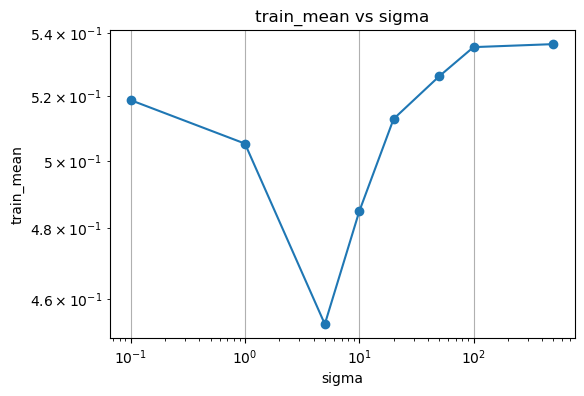

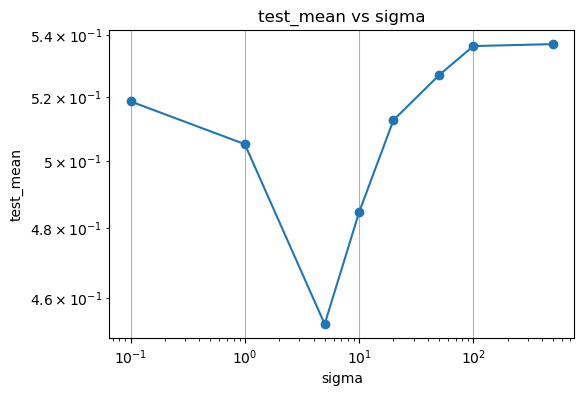

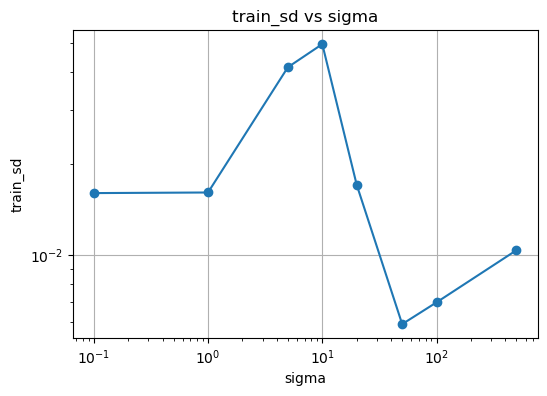

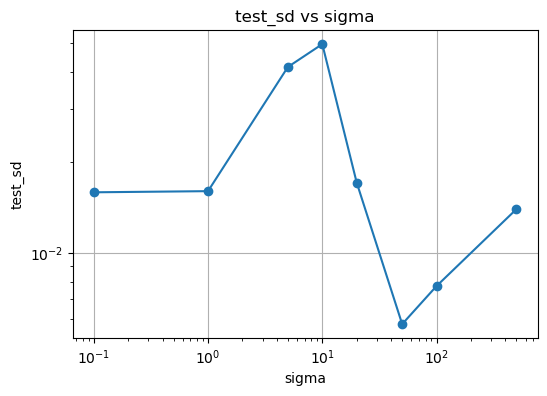

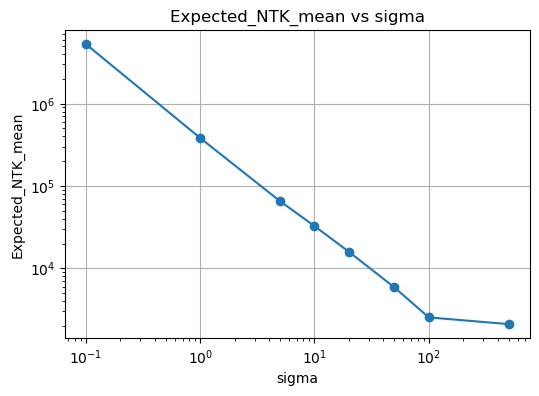

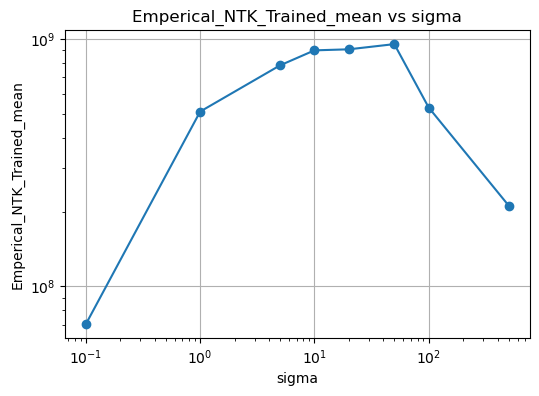

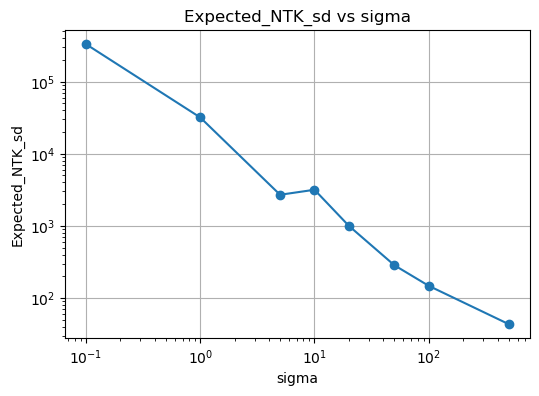

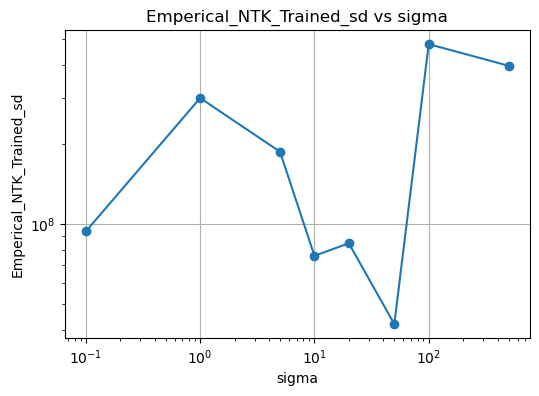

In [15]:
#too slow otherwise, smaller sample
results2={}
#make every needs to be higher but I think this only effects signals giving the wrong error individually not totally
X_train, y_train, X_test, y_test, X_all, y_all = make_data(
    n_total=1000,
    train_every=2,
)

sigma_values_new=[0.1,1,5,10,20,50,100,500]
key_model = random.fold_in(master_key, 1)

for sigma_idx, sigma in enumerate(sigma_values_new):
    cond_init=[]
    cond_trained=[]
    train_mse_ff_list = []
    test_mse_ff_list = []
    
    for j in range(1,11):
        print(j)
        #new master keys when compared to before
        experiment_key = random.fold_in(
        master_key,
        1000 * sigma_idx + j,
        )
        
        key_B, key_model_j = random.split(
            experiment_key,
        )
    
        B, a = make_fourier_params(
            num_basis=num_basis,
            sigma=sigma,
            key=key_B,
        )
    
        X_train_ff = fourier_features(X_train, B, a)
        X_test_ff = fourier_features(X_test, B, a)
        X_all_ff = fourier_features(X_all, B, a)
    
        X_train_n = X_train
        X_test_n = X_test
        X_all_n = X_all
    

        n_steps = 5000
        #this used to be a variable in a loop, now set to 5000

        #INIT CONDITION NUMBER
        #these are different each time now
        params_init_ff = init_mlp_params(
                key_model,
                input_dim=X_train_ff.shape[-1],
                width=4,
                depth=2,
            )

        K_init_ff, _ = analytic_ntk_matrix_2(X_train_ff)
        #empirical fix
        cond_ff_i, eigvals_ff_raw_i = condition_number_psd(K_init_ff, rtol=1e-9)

        
    
        # Fourier features model
        params_ff, y_pred_test_ff, train_mse_ff, test_mse_ff = train_one_model(
                key_model_j,
                X_train_ff,
                y_train,
                X_test_ff,
                y_test,
                width=4,
                depth=2,
                steps=n_steps,
                lr=1e-3,
                verbose=False,
            )
        print("Trained model")
        train_mse_ff_list.append(train_mse_ff)
        test_mse_ff_list.append(test_mse_ff)

        #TRAINED CONDITION NUMBER
        K_comp_ff, _ = empirical_ntk_matrix(params_ff,X_train_ff)
        #this should stay as it is since its trained out nn I think. Not sure how meaningful this metric actually is 
        cond_ff, eigvals_ff = condition_number_psd(K_comp_ff,rtol=1e-9)

        cond_init.append(float(cond_ff_i))
        cond_trained.append(float(cond_ff))

        #new bit
        #ASSUME WE SAMPLE FROM THE INITIAL DIST AS IN THE PAPER 
        #You can't do this and have differing condition numbers? vector length is fixed ()
        #but the available values change. No you can just choose different keys. Just do both?
            
    train_mse_avg=np.mean(train_mse_ff_list)
    test_mse_avg=np.mean(test_mse_ff_list)
    train_sd=np.std(train_mse_ff_list, ddof=1)
    test_sd=np.std(test_mse_ff_list, ddof=1)
    cond_init_avg=np.mean(cond_init)
    cond_trained_avg=np.mean(cond_trained)

    cond_init_sd=np.std(cond_init,ddof=1)
    cond_trained_sd=np.std(cond_trained,ddof=1)
        
    
    results2[sigma] = {
            "train_mean": train_mse_avg,
            "test_mean": test_mse_avg,
            "train_sd": train_sd,
            "test_sd": test_sd,
            "Expected_NTK_mean": cond_init_avg,
            "Emperical_NTK_Trained_mean": cond_trained_avg,
            "Expected_NTK_sd": cond_init_sd,
            "Emperical_NTK_Trained_sd": cond_trained_sd,
        }


sigmas = sorted(results2.keys())

metrics = [
    "train_mean",
    "test_mean",
    "train_sd",
    "test_sd",
    "Expected_NTK_mean",
    "Emperical_NTK_Trained_mean",
    "Expected_NTK_sd",
    "Emperical_NTK_Trained_sd",
]
print("Averaged Results from 10 Tests Per Sigma Value")
for metric in metrics:
    y = [results2[sigma][metric] for sigma in sigmas]

    plt.figure(figsize=(6, 4))
    plt.plot(sigmas, y, marker="o")
    plt.yscale("log")
    plt.xscale("log")
    plt.xlabel("sigma")
    plt.ylabel(metric)
    plt.title(f"{metric} vs sigma")
    plt.grid(True)
    plt.show()
    

width to 4, training size back up to 1000 ---> discussed last meeting but this takes a while to run so I'm sending over as is!

## Cell to test how Width changes error of both low and high frequencies

## SECTION 4

In [30]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import random

Number of sampled frequencies: 128
Minimum omega: -81.88844310024506
Maximum omega: 78.07921364229027

Training width = 4
  steps=1000, |ehat(omega=2*pi)|=7.5544e-02, |ehat(omega=8*pi)|=1.4584e-01
  steps=2000, |ehat(omega=2*pi)|=8.6712e-02, |ehat(omega=8*pi)|=9.5208e-02
  steps=3000, |ehat(omega=2*pi)|=9.9052e-02, |ehat(omega=8*pi)|=7.9296e-02
  steps=4000, |ehat(omega=2*pi)|=9.8461e-02, |ehat(omega=8*pi)|=7.4832e-02
  steps=5000, |ehat(omega=2*pi)|=9.6252e-02, |ehat(omega=8*pi)|=7.3257e-02
  steps=6000, |ehat(omega=2*pi)|=9.1584e-02, |ehat(omega=8*pi)|=7.3483e-02
  steps=7000, |ehat(omega=2*pi)|=8.5700e-02, |ehat(omega=8*pi)|=7.2943e-02
  steps=8000, |ehat(omega=2*pi)|=7.8523e-02, |ehat(omega=8*pi)|=7.2312e-02
  steps=9000, |ehat(omega=2*pi)|=7.0929e-02, |ehat(omega=8*pi)|=7.1143e-02

Training width = 16
  steps=1000, |ehat(omega=2*pi)|=4.3735e-02, |ehat(omega=8*pi)|=3.9545e-02
  steps=2000, |ehat(omega=2*pi)|=6.1125e-02, |ehat(omega=8*pi)|=4.4779e-02
  steps=3000, |ehat(omega=2*pi)|

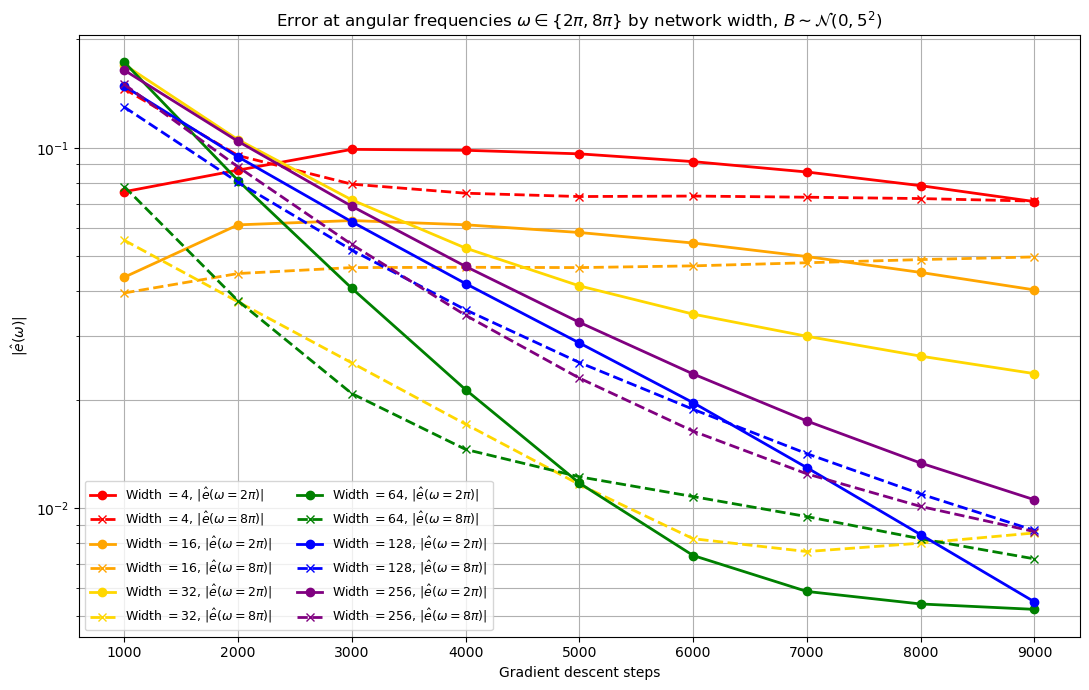

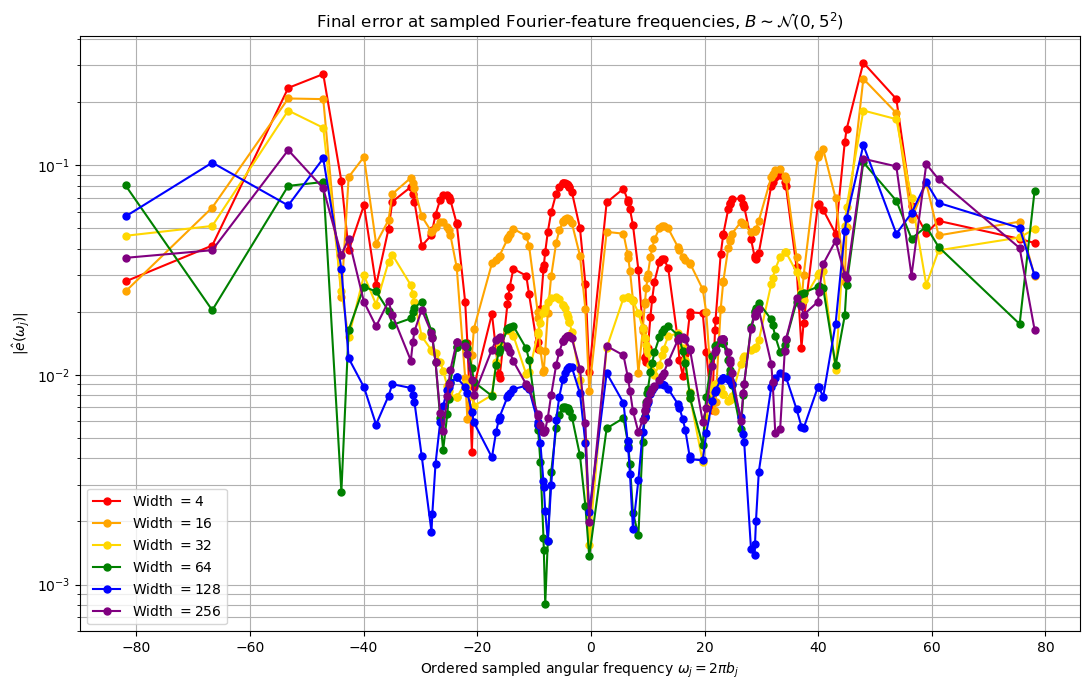


Final results after 9000 gradient-descent steps
------------------------------------------------
width=  4: |ehat(omega=2*pi)|=7.0928755131e-02, |ehat(omega=8*pi)|=7.1143328740e-02, train MSE=3.0843667026e-01, test MSE=3.0840497172e-01
width= 16: |ehat(omega=2*pi)|=4.0329334941e-02, |ehat(omega=8*pi)|=4.9793214697e-02, train MSE=2.6854608600e-01, test MSE=2.6844659180e-01
width= 32: |ehat(omega=2*pi)|=2.3609810017e-02, |ehat(omega=8*pi)|=8.5270090654e-03, train MSE=1.4944892663e-01, test MSE=1.4956081205e-01
width= 64: |ehat(omega=2*pi)|=5.2314346535e-03, |ehat(omega=8*pi)|=7.2246719936e-03, train MSE=9.3364924299e-02, test MSE=9.3542240757e-02
width=128: |ehat(omega=2*pi)|=5.4875828712e-03, |ehat(omega=8*pi)|=8.6633085743e-03, train MSE=1.0621425857e-01, test MSE=1.0658068386e-01
width=256: |ehat(omega=2*pi)|=1.0540293323e-02, |ehat(omega=8*pi)|=8.5996962490e-03, train MSE=8.6811065022e-02, test MSE=8.6716745484e-02

MSE recovered from final rFFT spectra
-----------------------------

In [17]:
# ============================================================
# Settings
# ============================================================
sigma = 5
num_basis = 128
p = 0
n_steps = 5000

depth = 2
learning_rate = 1e-3

width_values = [4, 16, 32, 64, 128, 256]

step_values = [
    1000,
    2000,
    3000,
    4000,
    5000,
    6000,
    7000,
    8000,
    9000,
]
steps_per_checkpoint=1000
master_key = random.PRNGKey(0)


# ============================================================
# Generate data again
#note, need bj not omega, but also need to accomodate for -ve values,
#for max sigma 500, omega was a bit over 6000, so bj needs to be a bit under a thousand, so two-thousand total min
#done 3000 for safe keeping, should run faster
# ============================================================
X_train, y_train, X_test, y_test, X_all, y_all = make_data(
    n_total=3000,
    train_every=2,
)

# Full-grid coordinates and target values
x_full = X_all.reshape(-1)
y_true_plot = y_all.reshape(-1)


# ============================================================
# Reproduce the sigma=5 Fourier-feature key
# ============================================================
sigma_idx = 2

key_B = random.fold_in(
    master_key,
    sigma_idx + 100,
)

B, a = make_fourier_params(
    num_basis=num_basis,
    sigma=sigma,
    key=key_B,
)


# ============================================================
# Same Fourier feature map for every network width
# ============================================================
X_train_ff = fourier_features(
    X_train,
    B,
    a,
)

X_test_ff = fourier_features(
    X_test,
    B,
    a,
)

X_all_ff = fourier_features(
    X_all,
    B,
    a,
)


# ============================================================
# Actual sampled angular frequencies
#
# omega_j = 2*pi*b_j
# ============================================================
b_sampled = B.reshape(-1)

omega_sampled = (
    2.0
    * jnp.pi
    * b_sampled
)

# Sort frequencies from smallest to largest
omega_sort_idx = jnp.argsort(
    omega_sampled
)

omega_sorted = omega_sampled[
    omega_sort_idx
]

print(
    "Number of sampled frequencies:",
    len(omega_sorted),
)

print(
    "Minimum omega:",
    float(omega_sorted[0]),
)

print(
    "Maximum omega:",
    float(omega_sorted[-1]),
)


# ============================================================
# Precompute Fourier exponentials at the sampled frequencies
#
# Shape:
#     (number of x points, number of sampled frequencies)
# ============================================================
sampled_frequency_basis = jnp.exp(
    -1j
    * x_full[:, None]
    * omega_sampled[None, :]
)


# ============================================================
# Exact angular frequencies tracked during training
#
# omega = 2*pi
# omega = 8*pi
# ============================================================
target_omegas = jnp.array(
    [
        2.0 * jnp.pi,
        8.0 * jnp.pi,
    ],
    dtype=x_full.dtype,
)

target_frequency_basis = jnp.exp(
    -1j
    * x_full[:, None]
    * target_omegas[None, :]
)


# ============================================================
# Store results for each width
# ============================================================
width_results = {}


# ============================================================
# Train each width for each requested number of steps
# ============================================================
for width in width_values:
    print(f"\nTraining width = {width}")

    # Same key convention for every width
    key_model = random.fold_in(
        master_key,
        1,
    )

    # Histories at exact angular frequencies omega=2*pi and 8*pi
    ehat_omega2pi_history = []
    ehat_omega8pi_history = []

    train_mse_history = []
    test_mse_history = []

    # Regular FFT spectrum retained for Parseval
    final_error_spectrum = None

    # Error evaluated at actual sampled omega_j values
    final_error_at_sampled_frequencies = None

    params = init_mlp_params(
            key_model,
            input_dim=X_train_ff.shape[-1],
            width=width,
            depth=depth,
            use_bias=use_bias,
        )

    for n_steps in step_values:

        params, _ = train_checkpoint(
                params,
                X_train_ff,
                y_train,
                number_of_steps=steps_per_checkpoint,
                lr=learning_rate
            )

        train_mse = mse_loss(
                params,
                X_train_ff,
                y_train,
                sigma_w_sq=sigma_w_sq,
                sigma_b_sq=sigma_b_sq,
                use_bias=use_bias,
            )

        test_mse = mse_loss(
                params,
                X_test_ff,
                y_test,
                sigma_w_sq=sigma_w_sq,
                sigma_b_sq=sigma_b_sq,
                use_bias=use_bias,
            )
        

        # Evaluate over the complete uniform grid
        y_pred_all = mlp_apply(
            params,
            X_all_ff,
        ).reshape(-1)

        # Pointwise prediction error
        error = (
            y_pred_all
            - y_true_plot
        )

        # ----------------------------------------------------
        # Exact error transform at omega=2*pi and omega=8*pi
        #
        # ehat(omega)
        #   = mean_n [
        #       error(x_n) exp(-i omega x_n)
        #     ]
        #
        # These are NOT regular FFT-bin lookups.
        # ----------------------------------------------------
        error_at_target_omegas = jnp.abs(
            jnp.mean(
                error[:, None]
                * target_frequency_basis,
                axis=0,
            )
        )

        ehat_omega2pi_history.append(
            float(
                error_at_target_omegas[0]
            )
        )

        ehat_omega8pi_history.append(
            float(
                error_at_target_omegas[1]
            )
        )

        # ----------------------------------------------------
        # Regular rFFT retained only for Parseval/MSE
        # ----------------------------------------------------
        error_spectrum = error_fft_magnitude(
            y_pred_all,
            y_true_plot,
        )

        # ----------------------------------------------------
        # Error transform evaluated at the actual sampled
        # angular frequencies omega_j = 2*pi*b_j
        # ----------------------------------------------------
        error_at_sampled_frequencies = jnp.abs(
            jnp.mean(
                error[:, None]
                * sampled_frequency_basis,
                axis=0,
            )
        )

        # Sort y-values using the same order as omega_sorted
        error_at_sampled_frequencies_sorted = (
            error_at_sampled_frequencies[
                omega_sort_idx
            ]
        )

        train_mse_history.append(
            float(train_mse)
        )

        test_mse_history.append(
            float(test_mse)
        )

        final_error_spectrum = (
            error_spectrum
        )

        final_error_at_sampled_frequencies = (
            error_at_sampled_frequencies_sorted
        )

        print(
            f"  steps={n_steps:4d}, "
            f"|ehat(omega=2*pi)|="
            f"{float(error_at_target_omegas[0]):.4e}, "
            f"|ehat(omega=8*pi)|="
            f"{float(error_at_target_omegas[1]):.4e}"
        )

    width_results[width] = {
        "steps": step_values.copy(),

        # Exact angular-frequency histories
        "ehat_omega2pi":
            ehat_omega2pi_history,

        "ehat_omega8pi":
            ehat_omega8pi_history,

        "train_mse":
            train_mse_history,

        "test_mse":
            test_mse_history,

        # Regular FFT spectrum retained for Parseval
        "final_error_spectrum":
            final_error_spectrum,

        # Actual sampled-frequency plot data
        "omega_sorted":
            omega_sorted,

        "final_error_at_sampled_frequencies":
            final_error_at_sampled_frequencies,
    }


# ============================================================
# One color for each width
# ============================================================
width_colors = {
    4: "red",
    16: "orange",
    32: "gold",
    64: "green",
    128: "blue",
    256: "purple",
}


# ============================================================
# Plot 1: exact angular frequencies omega=2*pi and omega=8*pi
#
# Same color = same width
# Solid line = omega=2*pi
# Dashed line = omega=8*pi
# ============================================================
plt.figure(figsize=(11, 7))

for width in width_values:
    plt.semilogy(
        width_results[width]["steps"],
        width_results[width][
            "ehat_omega2pi"
        ],
        color=width_colors[width],
        linestyle="-",
        marker="o",
        linewidth=2,
        label=(
            rf"Width $={width}$, "
            rf"$|\hat e(\omega=2\pi)|$"
        ),
    )

    plt.semilogy(
        width_results[width]["steps"],
        width_results[width][
            "ehat_omega8pi"
        ],
        color=width_colors[width],
        linestyle="--",
        marker="x",
        linewidth=2,
        label=(
            rf"Width $={width}$, "
            rf"$|\hat e(\omega=8\pi)|$"
        ),
    )

plt.xlabel(
    "Gradient descent steps"
)

plt.ylabel(
    r"$|\hat e(\omega)|$"
)

plt.title(
    r"Error at angular frequencies "
    r"$\omega\in\{2\pi,8\pi\}$ "
    r"by network width, "
    r"$B\sim\mathcal{N}(0,5^2)$"
)

plt.legend(
    ncol=2,
    fontsize=9,
)

plt.grid(
    True,
    which="both",
)

plt.tight_layout()
plt.show()


# ============================================================
# Plot 2: final error at actual sampled frequencies
#
# x-axis:
#     ordered omega_j = 2*pi*b_j
#
# y-axis:
#     |ehat(omega_j)|
#
# There are 128 points, one for each sampled b_j.
# ============================================================
plt.figure(figsize=(11, 7))

for width in width_values:
    plt.semilogy(
        width_results[width][
            "omega_sorted"
        ],
        width_results[width][
            "final_error_at_sampled_frequencies"
        ],
        color=width_colors[width],
        marker="o",
        markersize=5,
        label=rf"Width $={width}$",
    )

plt.xlabel(
    r"Ordered sampled angular frequency "
    r"$\omega_j=2\pi b_j$"
)

plt.ylabel(
    r"$|\hat e(\omega_j)|$"
)

plt.title(
    r"Final error at sampled Fourier-feature frequencies, "
    r"$B\sim\mathcal{N}(0,5^2)$"
)

plt.legend()

plt.grid(
    True,
    which="both",
)

plt.tight_layout()
plt.show()


# ============================================================
# Print final values after 9000 steps
# ============================================================
print(
    "\nFinal results after 9000 gradient-descent steps"
)

print(
    "------------------------------------------------"
)

for width in width_values:
    print(
        f"width={width:3d}: "
        f"|ehat(omega=2*pi)|="
        f"{width_results[width]['ehat_omega2pi'][-1]:.10e}, "
        f"|ehat(omega=8*pi)|="
        f"{width_results[width]['ehat_omega8pi'][-1]:.10e}, "
        f"train MSE="
        f"{width_results[width]['train_mse'][-1]:.10e}, "
        f"test MSE="
        f"{width_results[width]['test_mse'][-1]:.10e}"
    )


# ============================================================
# Recover final full-grid MSE from each regular rFFT spectrum
#
# This must remain based on the regular evenly spaced rFFT.
# The irregular sampled-frequency values do not satisfy this
# simple Parseval sum.
# ============================================================
print(
    "\nMSE recovered from final rFFT spectra"
)

print(
    "-------------------------------------"
)

for width in width_values:
    mag = width_results[width][
        "final_error_spectrum"
    ]

    mse_from_fft = (
        mag[0] ** 2
        + mag[-1] ** 2
        + 2.0
        * jnp.sum(
            mag[1:-1] ** 2
        )
    )

    print(
        f"width={width:3d}: "
        f"MSE from FFT="
        f"{float(mse_from_fft):.10e}"
    )

In [18]:
# ============================================================
# Sanity check: four-point discrete Fourier decomposition
#
# Standard FFT frequency ordering:
#     k = 0, 1, 2, 3
#
# Test signal:
#     e[n] = exp(2*pi*i*n/4)
#
# This is exactly the k=1 Fourier mode, so both the direct
# projection and jnp.fft.fft should return magnitudes:
#     [0, 1, 0, 0]
# ============================================================

N = 4

# Sample locations n = 0, 1, 2, 3
x_test = jnp.arange(N, dtype=jnp.float32)

# Standard FFT bin ordering k = 0, 1, 2, 3
k_values = jnp.arange(N, dtype=x_test.dtype)

# Angular frequencies omega_k = 2*pi*k/N
omega_values = 2.0 * jnp.pi * k_values / N

# Test error signal:
# e[n] = exp(2*pi*i*n/4), which is the k=1 Fourier basis vector
error_test = jnp.exp(
    2j * jnp.pi * x_test / N
)

# Construct y_pred - y_true = error_test
y_pred_test = error_test
y_true_test = jnp.zeros_like(error_test)

# Direct evaluation of the Fourier coefficients:
#
# a_k = (1/N) sum_n error[n] exp(-i*omega_k*x[n])
direct_magnitudes = error_at_angular_frequencies(
    y_pred=y_pred_test,
    y_true=y_true_test,
    x=x_test,
    omega_values=omega_values,
)

# Standard complex FFT, normalised by N
fft_coefficients = jnp.fft.fft(error_test) / N
fft_magnitudes = jnp.abs(fft_coefficients)

# The signal is purely the k=1 mode
expected = jnp.array(
    [0.0, 1.0, 0.0, 0.0],
    dtype=direct_magnitudes.dtype,
)

print("Sample indices n:")
print(x_test.astype(jnp.int32))

print("\nFFT bins k:")
print(k_values.astype(jnp.int32))

print("\nAngular frequencies omega_k:")
print(omega_values)

print("\nTest signal e[n]:")
print(error_test)

print("\nDirect projection magnitudes, ordered k = 0, 1, 2, 3:")
print(direct_magnitudes)

print("\nFFT magnitudes, ordered k = 0, 1, 2, 3:")
print(fft_magnitudes)

Sample indices n:
[0 1 2 3]

FFT bins k:
[0 1 2 3]

Angular frequencies omega_k:
[0.        1.5707964 3.1415927 4.712389 ]

Test signal e[n]:
[ 1.0000000e+00+0.000000e+00j -4.3711388e-08+1.000000e+00j
 -1.0000000e+00-8.742278e-08j  1.1924881e-08-1.000000e+00j]

Direct projection magnitudes, ordered k = 0, 1, 2, 3:
[1.9082179e-08 1.0000000e+00 1.9082179e-08 1.3909066e-08]

FFT magnitudes, ordered k = 0, 1, 2, 3:
[2.3255543e-08 1.0000000e+00 2.3255543e-08 7.9466265e-09]


## Fourier decomposition sanity check

Let the discrete Fourier basis vectors be

$$
\phi_j[n] = \exp\left(\frac{2\pi ijn}{N}\right),
\qquad j=0,\ldots,N-1.
$$

An arbitrary error signal can be written as

$$
e[n] = \sum_{j=0}^{N-1} a_j\phi_j[n].
$$

The coefficient of the $j$-th basis vector is found using the complex inner product:

$$
a_j = \langle \phi_j,e\rangle.
$$

For complex vectors, the first argument is conjugated:

$$
\langle \phi_j,e\rangle
=
\frac{1}{N}
\sum_{n=0}^{N-1}
\overline{\phi_j[n]}\,e[n].
$$

Since

$$
\overline{\phi_j[n]}
=
\exp\left(-\frac{2\pi ijn}{N}\right),
$$

the coefficient is

$$
a_j
=
\frac{1}{N}
\sum_{n=0}^{N-1}
e[n]
\exp\left(-\frac{2\pi ijn}{N}\right).
$$

The Fourier basis vectors are orthonormal:

$$
\langle \phi_j,\phi_k\rangle
=
\frac{1}{N}
\sum_{n=0}^{N-1}
\overline{\phi_j[n]}\phi_k[n]
=
\delta_{jk},
$$

where

$$
\delta_{jk}
=
\begin{cases}
1, & j=k, \\
0, & j\neq k.
\end{cases}
$$

## Four-point test signal

Take

$$
N=4
$$

and define the error signal as

$$
e[n]
=
\exp\left(\frac{2\pi in}{4}\right).
$$

This is exactly the $j=1$ Fourier basis vector:

$$
e[n] = \phi_1[n].
$$

At the four sample points $n=0,1,2,3$,

$$
e
=
\begin{bmatrix}
1 \\
i \\
-1 \\
-i
\end{bmatrix}.
$$

Therefore, the Fourier expansion contains only the $j=1$ component:

$$
e
=
0\phi_0
+
1\phi_1
+
0\phi_2
+
0\phi_3.
$$

The coefficients are

$$
a_j
=
\langle \phi_j,\phi_1\rangle
=
\delta_{j1}.
$$

Hence, using standard FFT indexing $j=0,1,2,3$, the expected coefficient magnitudes are

$$
\boxed{
\left[
|a_0|,
|a_1|,
|a_2|,
|a_3|
\right]
=
[0,1,0,0]
}
$$

## ENERGY PLOT Taking optimal sigma=5

## SECTION 5

In [31]:
def ntk_eigendecomposition(ntk_matrix):
    K = np.array(ntk_matrix, dtype=float)

    eigenvals, eigenvectors = np.linalg.eigh(K)

    # Pair each eigenvalue with its original column index,
    # then sort from largest magnitude to smallest.
    indexed_eigenvals = sorted(
        enumerate(eigenvals),
        key=lambda pair: abs(pair[1]),
        reverse=True
    )

    eigenvals_ordered = []
    eigenvectors_ordered = []

    for index, eigenvalue in indexed_eigenvals:
        eigenvals_ordered.append(eigenvalue)
        eigenvectors_ordered.append(eigenvectors[:, index])

    eigenvals_ordered = np.array(eigenvals_ordered)

    # The list currently contains eigenvectors as rows,
    # so transpose to put them back into columns.
    eigenvectors_ordered = np.array(eigenvectors_ordered).T

    return eigenvals_ordered, eigenvectors_ordered


def test_orthonormal(eigenvectors, tol=1e-9, n_checks=1000):
    Q = np.asarray(eigenvectors)
    n = Q.shape[1]
    failures = 0

    for _ in range(n_checks):
        i = np.random.randint(0, n)
        j = np.random.randint(0, n)

        dot_product = Q[:, i] @ Q[:, j]
        expected = 1 if i == j else 0

        if abs(dot_product - expected) >= tol:
            failures += 1

    print("Number of failures:", failures)
    return failures

Number of failures: 0
Keeping 200 of 200 eigenmodes
Eigenvalue threshold: 1.140e-06


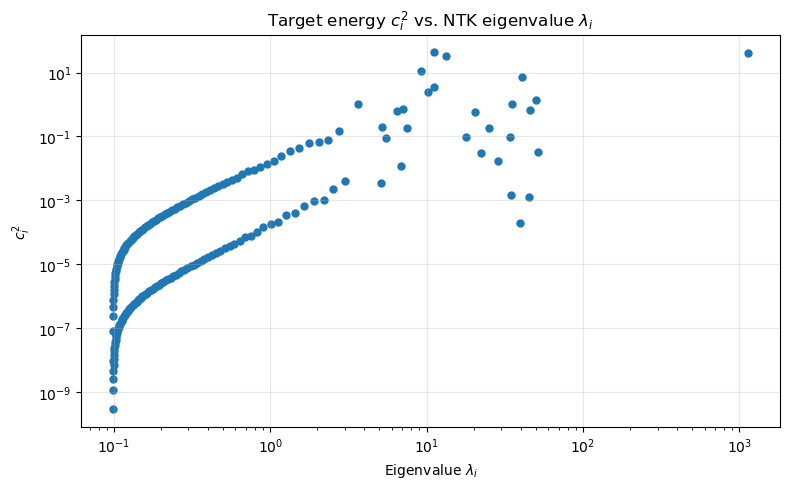

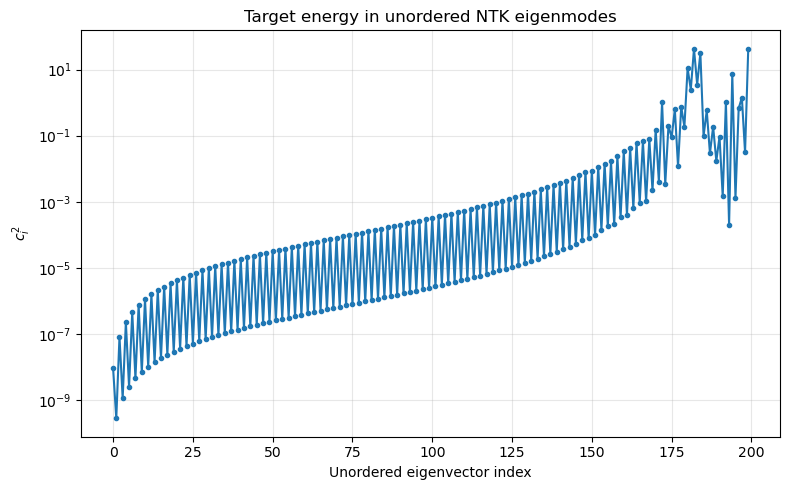

All eigenvalues distinct within tol: True


In [20]:
#init 

num_basis = 128
width = 4 # I'd like to put this higher but run time is just too slow
depth = 2
master_key = random.PRNGKey(0)
#sigma=5 so 200 should cover everything
n_total=200
#this is used to generate fourier basis here
sigma=5

#key+ making points to train + test

master_key = random.PRNGKey(0)
X_train, y_train, X_test, y_test, X_all, y_all = make_data(
    n_total=n_total,
    train_every=2,
)

# Full-grid coordinates and target values
x_full = X_all.reshape(-1)
y_true_plot = y_all.reshape(-1)
#used in the next cell

key_B = random.fold_in(
    master_key,
    2 + 100,
)
#same key throughout for sigma =5, it was third so index 2 in the list
B, a = make_fourier_params(
    num_basis=num_basis,
    sigma=sigma,
    key=key_B,
)
   
X_train_ff = fourier_features(X_train, B, a)
X_test_ff = fourier_features(X_test, B, a)
X_all_ff = fourier_features(X_all, B, a)

#INIT CONDITION NUMBER--> actually this must be X_all to match up later
#these are different each time now
#I don't think this is needed again 
"""
params_init_ff = init_mlp_params(
                key_B,
                input_dim=X_all_ff.shape[-1],
                width=1024,
                depth=2,
            )
"""

K_init_ff, _ = analytic_ntk_matrix_2(X_all_ff)
#empirical fix
#ordered
eigenvals,eigenvectors=ntk_eigendecomposition(K_init_ff)
#test
test_orthonormal(eigenvectors)

#unordered
eigenvals_u, eigenvectors_u = np.linalg.eigh(K_init_ff)

c_ordered=[]
c_unordered=[]

# Eigenvectors are stored as columns.
for i in range(eigenvectors.shape[1]):
    c_ordered.append(eigenvectors[:, i] @ y_all)
    c_unordered.append(eigenvectors_u[:, i] @ y_all)


c_ordered = np.asarray(c_ordered)
c_unordered = np.asarray(c_unordered)
eigenvals = np.asarray(eigenvals)

threshold = 1e-9 * np.max(eigenvals)
keep = eigenvals >= threshold

eigenvals_plot = eigenvals[keep]
c_ordered_plot = c_ordered[keep]

print(f"Keeping {keep.sum()} of {len(eigenvals)} eigenmodes")
print(f"Eigenvalue threshold: {threshold:.3e}")

plt.figure(figsize=(8, 5))
plt.scatter(
    eigenvals_plot,
    c_ordered_plot**2,
    s=25,
)

plt.xlabel(r"Eigenvalue $\lambda_i$")
plt.ylabel(r"$c_i^2$")
plt.title(r"Target energy $c_i^2$ vs. NTK eigenvalue $\lambda_i$")
plt.xscale("log")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Target energy against unordered eigenvector index.
plt.figure(figsize=(8, 5))
plt.plot(
    range(len(c_unordered)),
    c_unordered**2,
    marker="o",
    markersize=3,
)
plt.xlabel("Unordered eigenvector index")
plt.ylabel(r"$c_i^2$")
plt.title("Target energy in unordered NTK eigenmodes")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

tol = 1e-9

vals = np.sort(eigenvals_plot)

repeated = np.isclose(
    vals[1:],
    vals[:-1],
    atol=tol,
    rtol=tol,
)

print("All eigenvalues distinct within tol:", not np.any(repeated))

if np.any(repeated):
    print("Repeated / near-repeated pairs:")
    for i in np.where(repeated)[0]:
        print(vals[i], vals[i + 1])


## Energy Results (optimal sigma = 5)

In the above, all eigenvalues are now kept, so ignore brackets in above plot. We see higher energies have a strong linear correlation under the optimal pre-conditioning with larger eigenvalues, as you expected. Note I named the second graph unordered as I'm unsure if one of the functions I used orders eigenvectors based on the magnitude of their eigenvalues.

**The first plot is probably more useful**

# Setup --> GOAL. Take Error, for each bj, isolate fj in that error. Then, for each i, see how much lambda i contributes to the error wrt that fj component of it. Loosely, this should confirm for high frequencies, the f_50 error term is highest in lower i relating to lambda i. This is verified by using the NTK limit result, so we know how slowly the error ought to decay, and then writing the fj_error component in the eigenbasis.

Let $K \in \mathbb{R}^{n \times n}$ be symmetric positive semidefinite. Then

$$
K = \sum_{i=1}^{n} \lambda_i q_i q_i^*,
$$

where

$$
\lambda_i \geq 0,
\qquad
q_i^* q_k = \delta_{ik}.
$$

Although the eigenvectors $q_i$ may be chosen real, we may regard them as vectors in $\mathbb{C}^n$. Since $q_i$ is real,

$$
q_i^* = q_i^\top.
$$

Define the orthogonal projector onto the $i$-th eigendirection by

$$
P_i := q_i q_i^*.
$$

Then

$$
P_i P_k = \delta_{ik} P_i,
\qquad
\sum_i P_i = I,
\qquad
K = \sum_i \lambda_i P_i.
$$

Let the training-error vector be

$$
\varepsilon(t)
=
\widehat{y}_{\mathrm{train}}(t)-y,
$$

with arbitrary initial value

$$
\varepsilon(0)=\varepsilon_0.
$$

---

# Continuous-Time Fixed-NTK Dynamics

Assume the linearized NTK error dynamics

$$
\frac{d\varepsilon(t)}{dt}
=
-\eta K\varepsilon(t),
\qquad
\varepsilon(0)=\varepsilon_0.
$$

The solution is

$$
\varepsilon(t)
=
e^{-\eta Kt}\varepsilon_0.
$$

Using the eigendecomposition of $K$,

$$
e^{-\eta Kt}
=
\sum_i e^{-\eta\lambda_i t}P_i
=
\sum_i e^{-\eta\lambda_i t}q_iq_i^*.
$$

Therefore,

$$
\boxed{
\varepsilon(t)
=
\sum_i
e^{-\eta\lambda_i t}
(q_i^*\varepsilon_0)q_i
}
$$

Equivalently, the component of the error along the $i$-th eigenvector is

$$
P_i\varepsilon(t)
=
e^{-\eta\lambda_i t}
(q_i^*\varepsilon_0)q_i.
$$

Thus,

$$
\boxed{
P_i\varepsilon(t)
=
e^{-\eta\lambda_i t}P_i\varepsilon_0
}
$$

---

# Fourier Coefficients

Let

$$
F=[f_1,\ldots,f_n]\in\mathbb{C}^{n\times n}
$$

be a unitary Fourier basis:

$$
f_j^*f_k=\delta_{jk}.
$$

The Fourier coefficient of the error at frequency $j$ is defined by

$$
\boxed{
\widehat{\varepsilon}_j(t)
=
f_j^*\varepsilon(t)
}
$$

Substituting the eigenbasis evolution gives

$$
\begin{aligned}
\widehat{\varepsilon}_j(t)
&=
f_j^*
\sum_i
e^{-\eta\lambda_i t}
(q_i^*\varepsilon_0)q_i
\\
&=
\sum_i
e^{-\eta\lambda_i t}
(f_j^*q_i)
(q_i^*\varepsilon_0).
\end{aligned}
$$

Hence,

$$
\boxed{
\widehat{\varepsilon}_j(t)
=
\sum_i
e^{-\eta\lambda_i t}
(f_j^*q_i)
(q_i^*\varepsilon_0)
}
$$

---

# Isolating Eigenmode $i$ for Fixed Fourier Frequency $j$

First isolate eigenmode $i$:

$$
P_i\varepsilon(t)
=
e^{-\eta\lambda_i t}
(q_i^*\varepsilon_0)q_i.
$$

Then measure how much of that isolated vector appears at Fourier frequency $j$:

$$
c_{ij}(t)
:=
f_j^*P_i\varepsilon(t).
$$

Therefore,

$$
\begin{aligned}
c_{ij}(t)
&=
f_j^*
\left[
e^{-\eta\lambda_i t}
(q_i^*\varepsilon_0)q_i
\right]
\\
&=
e^{-\eta\lambda_i t}
(f_j^*q_i)
(q_i^*\varepsilon_0).
\end{aligned}
$$

Thus,

$$
\boxed{
c_{ij}(t)
=
e^{-\eta\lambda_i t}
(f_j^*q_i)
(q_i^*\varepsilon_0)
}
$$

At $t=0$,

$$
\boxed{
c_{ij}(0)
=
(f_j^*q_i)
(q_i^*\varepsilon_0)
}
$$

However, this is taking the entire error, need to isolate initial error for f_j.

---


# Isolating an Initial Fourier Frequency $j$

Define the projector onto the Fourier direction $f_j$ by

$$
P_j^F:=f_jf_j^*.
$$

The initial part of the error lying at frequency $j$ is

$$
\varepsilon_0^{[j]}
:=
P_j^F\varepsilon_0
=
(f_j^*\varepsilon_0)f_j
=
\widehat{\varepsilon}_j(0)f_j.
$$

Evolve only this initial Fourier component:

$$
\varepsilon^{[j]}(t)
=
e^{-\eta Kt}P_j^F\varepsilon_0.
$$

Using the eigendecomposition,

$$
\begin{aligned}
\varepsilon^{[j]}(t)
&=
\sum_i
e^{-\eta\lambda_i t}
q_iq_i^*
\left[
\widehat{\varepsilon}_j(0)f_j
\right]
\\
&=
\sum_i
\widehat{\varepsilon}_j(0)
e^{-\eta\lambda_i t}
(q_i^*f_j)q_i.
\end{aligned}
$$

Therefore, the vector contribution associated with eigenmode $i$ is

$$
\boxed{
v_{i\leftarrow j}(t)
=
\widehat{\varepsilon}_j(0)
e^{-\eta\lambda_i t}
(q_i^*f_j)q_i
}
$$

---

# Positive Error-Amplitude Contribution

Define the amplitude of the $i$-th eigenmode contribution originating from initial Fourier frequency $j$ by

$$
A_{i\leftarrow j}(t)
:=
\left\lVert v_{i\leftarrow j}(t)\right\rVert_2.
$$

Using

$$
v_{i\leftarrow j}(t)
=
\widehat{\varepsilon}_j(0)
e^{-\eta\lambda_i t}
(q_i^*f_j)q_i,
$$

we obtain

$$
\begin{aligned}
A_{i\leftarrow j}(t)
&=
\left\lVert
\widehat{\varepsilon}_j(0)
e^{-\eta\lambda_i t}
(q_i^*f_j)q_i
\right\rVert_2
\\
&=
\left|
\widehat{\varepsilon}_j(0)
e^{-\eta\lambda_i t}
(q_i^*f_j)
\right|
\left\lVert q_i\right\rVert_2.
\end{aligned}
$$

Since

$$
\left\lVert q_i\right\rVert_2=1,
$$

it follows that

$$
\boxed{
A_{i\leftarrow j}(t)
=
\left|\widehat{\varepsilon}_j(0)\right|
e^{-\eta\lambda_i t}
\left|q_i^*f_j\right|
}
$$

This is a real, nonnegative quantity. It represents the amplitude remaining at time $t$ in eigenmode $i$, originating from the initial Fourier frequency $j$.

At $t=0$,

$$
\boxed{
A_{i\leftarrow j}(0)
=
\left|\widehat{\varepsilon}_j(0)\right|
\left|q_i^*f_j\right|
}
$$

I used this and noticed the $f_{50}$ and $f_1$ values bunched together, for the convergence plots. I think this is because the $f_{50}$ error is initially higher than $f_1$s error. I then used the metric below to get a cleaner seperation but I'm not sure if this **is a fair result / thing to do?**

$$
\boxed{
R_{i\leftarrow j}(t)
=
e^{-\eta\lambda_i t}
\left|q_i^*f_j\right|
}
$$

For later plots in the notebook, since we have values that rapidly decay into $10^{-100}$ or smaller, the ratio between frequencies $j$ and $j'$ might be more important to study, which is fixed with respect to each gradient decent step;


$$
\boxed{
\operatorname{Ratio}_{i\leftarrow(j,j')}(t)
=
\frac{R_{i\leftarrow j}(t)}
{R_{i\leftarrow j'}(t)}
=
\frac{\left|q_i^*f_j\right|}
{\left|q_i^*f_{j'}\right|},
\qquad
j\neq j'
}
$$




In [32]:
def fourier_error_by_ntk_mode(
    F,
    Q,
    eigenvalues,
    epsilon0,
    j,
    step,
    eta,
):
    """
    Compute Fourier/NTK quantities for every NTK eigenmode i,
    for one fixed Fourier frequency j and one fixed training step.

    Parameters
    ----------
    F : array_like, shape (n, n_fourier_modes)
        Fourier vectors stored as columns. The selected vector f_j
        is normalized internally.

    Q : array_like, shape (n, n_eigenmodes)
        NTK eigenvectors stored as columns.

    eigenvalues : array_like, shape (n_eigenmodes,)
        NTK eigenvalues corresponding to the columns of Q.

    epsilon0 : array_like, shape (n,) or (n, 1)
        Initial prediction-error vector.

    j : int
        Fixed Fourier-mode index. THIS WILL OUTPUT AN ANGULAR FREQ OF 2pi j IMPORTANT!!!

    step : int or float
        GD checkpoint or effective continuous training time.

    eta : float
        Effective rate in the fixed-NTK error dynamics.

    Returns
    -------
    results: list of dict
        (these are different metrics I tested to see which gave the results we are looking for)
        One dictionary per eigenmode i, containing:

        - "mode"
        - "eigenvalue"
        - "decay_factor"
        - "fourier_overlap"
        - "wij"
        - "initial_fourier_amplitude"
        - "amplitude_at_step"
        - "normalized_amplitude_at_step"
        - "cij"
        - "Dij"

        Definitions
        -----------
        wij
            |q_i^* f_j|^2

        cij
            |exp(-eta lambda_i step)
             (f_j^* q_i)
             (q_i^* epsilon0)|

        Dij
            |epsilon_hat_j(0)|
            exp(-eta lambda_i step)
            |q_i^* f_j|^2

        Here f_j is normalized to unit Euclidean norm.
    Note don't use this fourier feature function in relation to the other one, or if do,
    figure out the different scalings as rfft is different and this is used in the other functions!
    """

    import numpy as np

    # -----------------------------------------------------
    # Convert inputs
    # -----------------------------------------------------

    F = np.asarray(F)
    Q = np.asarray(Q)

    eigenvalues = np.asarray(
        eigenvalues,
        dtype=float,
    ).reshape(-1)

    epsilon0 = np.asarray(
        epsilon0,
    ).reshape(-1)

    # -----------------------------------------------------
    # Handle numerical negative eigenvalues
    #
    # A true NTK is positive semidefinite. Tiny negative
    # values may arise from floating-point error.
    # -----------------------------------------------------

    eigenvalue_scale = max(
        1.0,
        float(np.max(np.abs(eigenvalues))),
    )

    negative_eigenvalue_tolerance = (
        1e-12 * eigenvalue_scale
    )

    materially_negative = (
        eigenvalues
        < -negative_eigenvalue_tolerance
    )

    if np.any(materially_negative):
        most_negative = float(
            np.min(eigenvalues)
        )

        raise ValueError(
            "The NTK contains a materially negative "
            f"eigenvalue ({most_negative:.6e}). "
            "Check that the kernel matrix is symmetric "
            "and positive semidefinite."
        )

    # Clip only tiny numerical negatives to zero.
    eigenvalues_for_decay = np.maximum(
        eigenvalues,
        0.0,
    )

    # -----------------------------------------------------
    # Select and normalize Fourier vector f_j
    #
    # The formulas assume ||f_j||_2 = 1.
    # -----------------------------------------------------

    f_j = np.asarray(
        F[:, j],
        dtype=complex,
    )

    f_j_norm = np.linalg.norm(
        f_j
    )

    if (
        not np.isfinite(f_j_norm)
        or f_j_norm == 0.0
    ):
        raise ValueError(
            f"Fourier vector f_{j} has an invalid norm."
        )

    f_j = (
        f_j / f_j_norm
    )

    # -----------------------------------------------------
    # Initial Fourier coefficient
    #
    # epsilon_hat_j(0) = f_j^* epsilon0
    # -----------------------------------------------------

    epsilon_hat_j0 = np.vdot(
        f_j,
        epsilon0,
    )

    initial_fourier_amplitude = float(
        np.abs(epsilon_hat_j0)
    )

    # -----------------------------------------------------
    # Fourier/NTK alignment
    #
    # overlaps[i] = q_i^* f_j
    # -----------------------------------------------------

    overlaps = (
        Q.conj().T @ f_j
    )

    overlap_amplitudes = np.abs(
        overlaps
    )

    # -----------------------------------------------------
    # Structural Fourier weight
    #
    # wij[i] = |q_i^* f_j|^2
    # -----------------------------------------------------

    wij_values = (
        overlap_amplitudes ** 2
    )

    # -----------------------------------------------------
    # Decay factors
    #
    # exp(-eta lambda_i step)
    # -----------------------------------------------------
    #this factor was added in, NEED TO CHECK THIS
    n = epsilon0.shape[0]
    eta_effective = 2.0 * eta / n

    decay_factors = np.exp(
        -eta_effective
        * eigenvalues_for_decay
        * step
    )

    # -----------------------------------------------------
    # A_{i <- j}(step)
    #
    # Amplitude remaining in eigenmode i after starting
    # from the isolated initial Fourier component f_j.
    #
    # A = |epsilon_hat_j(0)|
    #     exp(-eta lambda_i step)
    #     |q_i^* f_j|
    # -----------------------------------------------------

    amplitude_at_step = (
        initial_fourier_amplitude
        * decay_factors
        * overlap_amplitudes
    )

    # -----------------------------------------------------
    # R_{i <- j}(step)
    #
    # Unit-initial-amplitude eigenmode quantity.
    # -----------------------------------------------------

    normalized_amplitude_at_step = (
        decay_factors
        * overlap_amplitudes
    )

    # -----------------------------------------------------
    # |c_ij(step)|
    #
    # Contribution of eigenmode i to the current Fourier-j
    # coefficient when the entire epsilon0 is evolved.
    #
    # c_ij(step)
    #   = exp(-eta lambda_i step)
    #     (f_j^* q_i)
    #     (q_i^* epsilon0)
    # -----------------------------------------------------

    eigenmode_coefficients = (
        Q.conj().T @ epsilon0
    )

    cij_values = np.abs(
        decay_factors
        * overlaps.conj()
        * eigenmode_coefficients
    )

    # -----------------------------------------------------
    # D_ij(step)
    #
    # Isolate the initial frequency-j component, evolve its
    # eigenmode-i part, and project it back onto frequency j.
    #
    # D_ij(step)
    #   = |epsilon_hat_j(0)|
    #     exp(-eta lambda_i step)
    #     |q_i^* f_j|^2
    #
    # Equivalently:
    #
    # D_ij = A_{i <- j} |q_i^* f_j|
    # -----------------------------------------------------

    Dij_values = (
        initial_fourier_amplitude
        * decay_factors
        * wij_values
    )

    # -----------------------------------------------------
    # Return one dictionary per eigenmode i
    # -----------------------------------------------------

    results = []
    n_eigenmodes = Q.shape[1]

    for i in range(n_eigenmodes):
        results.append(
            {
                "mode": i,

                "eigenvalue": float(
                    eigenvalues[i]
                ),

                "decay_factor": float(
                    decay_factors[i]
                ),

                # |q_i^* f_j|
                "fourier_overlap": float(
                    overlap_amplitudes[i]
                ),

                # |q_i^* f_j|^2
                "wij": float(
                    wij_values[i]
                ),

                # |f_j^* epsilon0|
                "initial_fourier_amplitude": (
                    initial_fourier_amplitude
                ),

                # A_{i <- j}(step)
                "amplitude_at_step": float(
                    amplitude_at_step[i]
                ),

                # R_{i <- j}(step)
                "normalized_amplitude_at_step": float(
                    normalized_amplitude_at_step[i]
                ),

                # |c_ij(step)|
                "cij": float(
                    cij_values[i]
                ),

                # D_ij(step)
                "Dij": float(
                    Dij_values[i]
                ),
            }
        )

    return results

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display


# =========================================================
# Configuration
# =========================================================
#this has been changed upon realisation that j=50 equiv bj=50 
#99 is the largest atm, since the latter N/2 are repeats (see fourier function(s) above)
j_values = [1, 8, 16 ,32 ,50,99]

steps = [
    100,
    500,
    1000,
    5000,
    10_000,
    20_000,
]

eta_plot = 1e-3

# Retain eigenvalues satisfying:
#
# lambda_i > tolerance * lambda_max
eigenvalue_relative_tolerance = 1e-12

# Set to zero to retain every finite positive R_ij value.
R_relative_tolerance = 0.0

# In each eigenvalue panel, display the region containing
# f_50 values no smaller than 10^-20 of the largest f_50
# value at that checkpoint.
#
# For energy, this corresponds to:
#
# E >= 10^-6 E_max
#
# because E = R^2.
f50_zoom_relative_tolerance = 1e-8

plot_data = {}

#missing setup code

#this is from the last cell
eigenvalues, Q = ntk_eigendecomposition(K_init_ff)

test_orthonormal(Q)

print("eigenvalues shape:", eigenvalues.shape)
print("Q shape:", Q.shape)


y_pred0 = np.asarray(
    mlp_apply(params_init_ff, X_all_ff)
).reshape(-1)

epsilon0 = (
    y_pred0
    - np.asarray(y_all).reshape(-1)
)
#changed this so actually orthonormal instead of =N when doing dot products
N = x_full.shape[0]

vals_r = jnp.arange(N)

F = jnp.exp(
    2j
    * jnp.pi
    * x_full[:, None]
    * vals_r[None, :]
) / jnp.sqrt(N)


print("F shape:", F.shape)
print("epsilon0 shape:", epsilon0.shape)
#--- end 

# =========================================================
# Figure rendering helper
# =========================================================

def render_figure(fig):
    fig.tight_layout()
    display(fig)
    plt.close(fig)


# =========================================================
# Compute R_ij(t) and E_ij(t)
#
# R_ij(t)
#   = exp(-eta * lambda_i * t) |q_i^* f_j|
#
# E_ij(t)
#   = R_ij(t)^2
#   = exp(-2 eta * lambda_i * t) |q_i^* f_j|^2
# =========================================================

# A test to confirm how many eigenvalues are repeated:

grouped = jnp.unique_counts(eigenvalues)

duplicate_mask = grouped.counts > 1
duplicate_values = grouped.values[duplicate_mask]
duplicate_counts = grouped.counts[duplicate_mask]

for value, count in zip(
    np.asarray(duplicate_values),
    np.asarray(duplicate_counts),
):
    print(f"{value}: {count} occurrences")
print("If nothing above this, no repeated eigenvalues!")

#main loop of sampling gd steps and 1,50 freq choices for first two plot series
for gd_step in steps:
    for j in j_values:
        #asdf
        results_j = fourier_error_by_ntk_mode(
            F=F,
            Q=Q,
            eigenvalues=eigenvalues,
            epsilon0=epsilon0,
            j=j,
            step=gd_step,
            eta=eta_plot,
        )

        R_values = np.asarray(
            [
                result["normalized_amplitude_at_step"] #this can be changed to see the different metrics from result
                for result in results_j
            ],
            dtype=float,
        )

        plot_data[(gd_step, j)] = {
            "mode_indices": np.asarray(
                [
                    result["mode"]
                    for result in results_j
                ],
                dtype=int,
            ),
            "eigenvalues": np.asarray(
                [
                    result["eigenvalue"]
                    for result in results_j
                ],
                dtype=float,
            ),
            "R": R_values,
            "E": R_values ** 2,
        }


# =========================================================
# Establish common eigenvalue tolerance
# =========================================================

reference_eigenvalues = plot_data[
    (steps[0], j_values[0])
]["eigenvalues"]

finite_eigenvalues = reference_eigenvalues[
    np.isfinite(reference_eigenvalues)
]


lambda_max = np.max(
    finite_eigenvalues
)


lambda_tolerance = (
    eigenvalue_relative_tolerance
    * lambda_max
)


# ==================================================================================================
#This section was to try is toisolate or zoom in in the plot to where the largest error was occuring
# ==================================================================================================

all_R_values = np.concatenate(
    [
        data["R"]
        for data in plot_data.values()
    ]
)

finite_positive_R = all_R_values[
    np.isfinite(all_R_values)
    & (all_R_values > 0.0)
]

R_max = np.max(
    finite_positive_R
)

if R_relative_tolerance > 0.0:
    R_tolerance = (
        R_relative_tolerance
        * R_max
    )
else:
    R_tolerance = 0.0


# ==============================================================================================================================================
#remove all eigenvalues which are less than billionth largest or points which have error less than error tol so that can infer meaning for plots
# ==============================================================================================================================================

def get_valid_mask(data):

    eigenvalues_plot = data["eigenvalues"]
    R_values = data["R"]

    return (
        np.isfinite(eigenvalues_plot)
        & np.isfinite(R_values)
        & (eigenvalues_plot > lambda_tolerance)
        & (R_values > R_tolerance)
    )


# =========================================================
# Shared limits for the global plots
# =========================================================

all_retained_mode_numbers = []
all_retained_eigenvalues = []
all_retained_R = []
all_retained_E = []

for gd_step in steps:
    for j in j_values:

        data = plot_data[
            (gd_step, j)
        ]

        valid = get_valid_mask(
            data
        )

        if np.any(valid):

            all_retained_mode_numbers.append(
                data["mode_indices"][valid] + 1
            )

            all_retained_eigenvalues.append(
                data["eigenvalues"][valid]
            )

            all_retained_R.append(
                data["R"][valid]
            )

            all_retained_E.append(
                data["E"][valid]
            )
##this is now defining the limits to but into the last function


all_retained_mode_numbers = np.concatenate(
    all_retained_mode_numbers
)

all_retained_eigenvalues = np.concatenate(
    all_retained_eigenvalues
)

all_retained_R = np.concatenate(
    all_retained_R
)

all_retained_E = np.concatenate(
    all_retained_E
)


mode_lower_limit = max(
    1.0,
    np.min(all_retained_mode_numbers) / 1.05,
)

mode_upper_limit = (
    np.max(all_retained_mode_numbers)
    * 1.05
)

eigenvalue_lower_limit = (
    np.min(all_retained_eigenvalues)
    / 1.05
)

eigenvalue_upper_limit = (
    np.max(all_retained_eigenvalues)
    * 1.05
)

R_lower_limit = (
    np.min(all_retained_R)
    / 1.05
)

R_upper_limit = (
    np.max(all_retained_R)
    * 1.05
)

E_lower_limit = (
    np.min(all_retained_E)
    / 1.05
)

E_upper_limit = (
    np.max(all_retained_E)
    * 1.05
)


# =========================================================
# FIGURE 1
#
# R_ij(t) against NTK eigenmode number
# =========================================================

fig1, axes1 = plt.subplots(
    2,
    3,
    figsize=(18, 9),
    sharex=True,
    sharey=True,
)

axes1 = axes1.ravel()

for ax, gd_step in zip(
    axes1,
    steps,
):

    for j in j_values:

        data = plot_data[
            (gd_step, j)
        ]

        valid = get_valid_mask(
            data
        )

        ax.plot(
            data["mode_indices"][valid] + 1,
            data["R"][valid],
            linewidth=0.8,
            label=rf"$f_{{{j}}}$",
        )

    ax.set_title(
        f"{gd_step:,} GD steps"
    )

    ax.set_xlabel(
        r"NTK eigenmode number $i+1$"
    )

    ax.set_ylabel(
        r"$R_{ij}(t)"
        r"=e^{-\eta\lambda_i t}|q_i^*f_j|$"
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlim(
        mode_lower_limit,
        mode_upper_limit,
    )

    ax.set_ylim(
        R_lower_limit,
        R_upper_limit,
    )

    ax.grid(
        alpha=0.3,
        which="both",
    )

    ax.legend(
        title="Fourier mode"
    )


fig1.suptitle(
    r"Remaining unit-amplitude Fourier component"
    r"$R_{ij}(t)$ across NTK eigenmodes (x-axis scaled by index not abs eigenvalues but ordered / index determined from magnitudes of eigenvalues)",
    fontsize=14,
)

render_figure(fig1)


# =========================================================
# FIGURE 2
#
# R_ij(t) against NTK eigenvalue
#
# Each panel uses independent axes focused on f_50.
# =========================================================

fig2, axes2 = plt.subplots(
    2,
    3,
    figsize=(18, 9),
    sharex=False,
    sharey=False,
)

axes2 = axes2.ravel()

for ax, gd_step in zip(
    axes2,
    steps,
):

    # -----------------------------------------------------
    # Determine the panel region using f_50
    # -----------------------------------------------------

    f50_data = plot_data[
        (gd_step, 8)
    ]

    f50_valid = get_valid_mask(
        f50_data
    )

    f50_eigenvalues = (
        f50_data["eigenvalues"][f50_valid]
    )

    f50_R = (
        f50_data["R"][f50_valid]
    )

    f50_R_max = np.max(
        f50_R
    )

    f50_R_threshold = (
        f50_zoom_relative_tolerance
        * f50_R_max
    )

    f50_zoom_mask = (
        f50_R >= f50_R_threshold
    )

    zoom_eigenvalues = (
        f50_eigenvalues[f50_zoom_mask]
    )

    panel_x_min = (
        np.min(zoom_eigenvalues)
        / 1.10
    )

    panel_x_max = (
        np.max(zoom_eigenvalues)
        * 1.10
    )

    panel_R_min = (
        f50_R_threshold
    )

    panel_R_max = (
        f50_R_max
        * 1.10
    )

    if np.isclose(
        panel_x_min,
        panel_x_max,
    ):
        panel_x_min = (
            np.min(zoom_eigenvalues)
            / 2.0
        )

        panel_x_max = (
            np.max(zoom_eigenvalues)
            * 2.0
        )

    # -----------------------------------------------------
    # Plot f_1 and f_50
    # -----------------------------------------------------

    for j in j_values:

        data = plot_data[
            (gd_step, j)
        ]

        valid = get_valid_mask(
            data
        )

        ax.scatter(
            data["eigenvalues"][valid],
            data["R"][valid],
            s=9,
            alpha=0.7,
            label=rf"$f_{{{j}}}$",
        )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlim(
        panel_x_min,
        panel_x_max,
    )

    ax.set_ylim(
        panel_R_min,
        panel_R_max,
    )

    ax.set_title(
        f"{gd_step:,} GD steps\n"
        rf"$R_{{i,8}}\geq"
        rf"10^{{-8}}\max_i R_{{i,8}}$"
    )

    ax.set_xlabel(
        r"NTK eigenvalue $\lambda_i$"
    )

    ax.set_ylabel(
        r"$R_{ij}(t)$"
    )

    ax.grid(
        alpha=0.3,
        which="both",
    )

    ax.legend(
        title="Fourier mode"
    )


fig2.suptitle(
    r"$R_{ij}(t)$ against NTK eigenvalue "
    r"with independent $f_{8}$-focused axes",
    fontsize=14,
)

render_figure(fig2)


# =========================================================
# FIGURE 3
#
# E_ij(t) against NTK eigenvalue
#
# E_ij(t) = R_ij(t)^2
# =========================================================

fig3, axes3 = plt.subplots(
    2,
    3,
    figsize=(18, 9),
    sharex=False,
    sharey=False,
)

axes3 = axes3.ravel()

for ax, gd_step in zip(
    axes3,
    steps,
):

    # -----------------------------------------------------
    # Determine the panel region using f_50
    # -----------------------------------------------------

    f50_data = plot_data[
        (gd_step, 8)
    ]

    f50_valid = get_valid_mask(
        f50_data
    )

    f50_eigenvalues = (
        f50_data["eigenvalues"][f50_valid]
    )

    f50_R = (
        f50_data["R"][f50_valid]
    )

    f50_E = (
        f50_data["E"][f50_valid]
    )

    if f50_E.size == 0:
        raise ValueError(
            f"No valid f_50 energies exist at "
            f"{gd_step:,} GD steps."
        )

    f50_R_max = np.max(
        f50_R
    )

    f50_R_threshold = (
        f50_zoom_relative_tolerance
        * f50_R_max
    )

    # Use exactly the same modal selection as Figure 2.
    f50_zoom_mask = (
        f50_R >= f50_R_threshold
    )

    zoom_eigenvalues = (
        f50_eigenvalues[f50_zoom_mask]
    )

    zoom_f50_E = (
        f50_E[f50_zoom_mask]
    )

    panel_x_min = (
        np.min(zoom_eigenvalues)
        / 1.10
    )

    panel_x_max = (
        np.max(zoom_eigenvalues)
        * 1.10
    )

    panel_E_min = (
        f50_R_threshold ** 2
    )

    panel_E_max = (
        np.max(zoom_f50_E)
        * 1.10
    )

    if np.isclose(
        panel_x_min,
        panel_x_max,
    ):
        panel_x_min = (
            np.min(zoom_eigenvalues)
            / 2.0
        )

        panel_x_max = (
            np.max(zoom_eigenvalues)
            * 2.0
        )

    # -----------------------------------------------------
    # Plot f_1 and f_50 energy
    # -----------------------------------------------------

    for j in j_values:

        data = plot_data[
            (gd_step, j)
        ]

        valid = get_valid_mask(
            data
        )

        ax.scatter(
            data["eigenvalues"][valid],
            data["E"][valid],
            s=9,
            alpha=0.7,
            label=rf"$f_{{{j}}}$",
        )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlim(
        panel_x_min,
        panel_x_max,
    )

    ax.set_ylim(
        panel_E_min,
        panel_E_max,
    )

    ax.set_title(
        f"{gd_step:,} GD steps\n"
        rf"$E_{{i,8}}\geq"
        rf"10^{{-8}}\max_i E_{{i,8}}$"
    )

    ax.set_xlabel(
        r"NTK eigenvalue $\lambda_i$"
    )

    ax.set_ylabel(
        r"$E_{ij}(t)"
        r"=e^{-2\eta\lambda_i t}|q_i^*f_j|^2$"
    )

    ax.grid(
        alpha=0.3,
        which="both",
    )

    ax.legend(
        title="Fourier mode"
    )


fig3.suptitle(
    r"Remaining Fourier-mode energy $E_{ij}(t)$ "
    r"against NTK eigenvalue",
    fontsize=14,
)

render_figure(fig3)


# =========================================================
# FIGURE 4
#
# Combined R_ij(t) plot
#
# Colour = GD checkpoint
# x      = f_1
# circle = f_50
# =========================================================

default_colours = plt.rcParams[
    "axes.prop_cycle"
].by_key()["color"]

step_colours = {
    gd_step: default_colours[
        index % len(default_colours)
    ]
    for index, gd_step in enumerate(steps)
}

mode_markers = {
    1: "x",
    8: "o",
}


fig4, ax4 = plt.subplots(
    figsize=(12, 7)
)

for gd_step in steps:
    #added more j_values
    for j in j_values[0:2]:

        data = plot_data[
            (gd_step, j)
        ]

        valid = get_valid_mask(
            data
        )

        ax4.scatter(
            data["eigenvalues"][valid],
            data["R"][valid],
            color=step_colours[gd_step],
            marker=mode_markers[j],
            s=20,
            alpha=0.7,
        )


step_legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor=step_colours[gd_step],
        markeredgecolor=step_colours[gd_step],
        markersize=7,
        label=f"{gd_step:,}",
    )
    for gd_step in steps
]

mode_legend_handles = [
    Line2D(
        [0],
        [0],
        marker="x",
        linestyle="none",
        color="black",
        markersize=8,
        label=r"$f_1$",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="none",
        markeredgecolor="black",
        markersize=7,
        label=r"$f_{8}$",
    ),
]

step_legend = ax4.legend(
    handles=step_legend_handles,
    title="GD steps",
    loc="upper right",
    ncol=2,
)

ax4.add_artist(
    step_legend
)

ax4.legend(
    handles=mode_legend_handles,
    title="Fourier mode",
    loc="lower left",
)

ax4.set_xscale("log")
ax4.set_yscale("log")

ax4.set_xlim(
    eigenvalue_lower_limit,
    eigenvalue_upper_limit,
)

ax4.set_ylim(
    R_lower_limit,
    R_upper_limit,
)

ax4.set_xlabel(
    r"NTK eigenvalue $\lambda_i$"
)

ax4.set_ylabel(
    r"$R_{ij}(t)"
)

ax4.set_title(
    r"Remaining unit-amplitude Fourier components "
    r"across GD checkpoints"
)

ax4.grid(
    alpha=0.3,
    which="both",
)

render_figure(fig4)


# =========================================================
# FIGURE 5
#
# Ratio between f_50 and f_1:
#
# R_{i,50}(t) / R_{i,1}(t)
#   = |q_i^* f_50| / |q_i^* f_1|
#
# The common decay factor cancels, so this ratio is
# independent of GD step.
# =========================================================

F_array = np.asarray(F)
Q_array = np.asarray(Q)

eigenvalues_array = np.asarray(
    eigenvalues,
    dtype=float,
).reshape(-1)
#edit_note

#THIS WASN'T FIXED BEFORE BUT IT IS NOW
#8 used to be 50
#2*pi*8 approx 50
f1 = F_array[:, 1]
f50 = F_array[:, 8]

f1_alignment = np.abs(
    Q_array.conj().T @ f1
)

f50_alignment = np.abs(
    Q_array.conj().T @ f50
)

if eigenvalues_array.size != f1_alignment.size:
    raise ValueError(
        "The number of eigenvalues does not match the "
        "number of NTK eigenvectors."
    )

ratio = np.full(
    eigenvalues_array.shape,
    np.nan,
    dtype=float,
)

ratio_valid = (
    np.isfinite(eigenvalues_array)
    & np.isfinite(f1_alignment)
    & np.isfinite(f50_alignment)
    & (
        eigenvalues_array
        > lambda_tolerance
    )
    & (
        f1_alignment
        > 0.0
    )
    & (
        f50_alignment
        > 0.0
    )
)

ratio[ratio_valid] = (
    f50_alignment[ratio_valid]
    / f1_alignment[ratio_valid]
)

finite_positive_ratio = (
    ratio_valid
    & np.isfinite(ratio)
    & (
        ratio > 0.0
    )
)

if not np.any(finite_positive_ratio):
    raise ValueError(
        "No finite positive f_8/f_1 ratios are available."
    )

ratio_eigenvalues = eigenvalues_array[
    finite_positive_ratio
]

ratio_values = ratio[
    finite_positive_ratio
]

ratio_x_lower = (
    np.min(ratio_eigenvalues)
    / 1.05
)

ratio_x_upper = (
    np.max(ratio_eigenvalues)
    * 1.05
)

ratio_y_lower = (
    np.min(ratio_values)
    / 1.05
)

ratio_y_upper = (
    np.max(ratio_values)
    * 1.05
)

fig5, ax5 = plt.subplots(
    figsize=(12, 7)
)

ax5.scatter(
    ratio_eigenvalues,
    ratio_values,
    s=12,
    alpha=0.7,
)

ax5.axhline(
    1.0,
    linestyle="--",
    linewidth=1.2,
    label=r"$R_{i,8}/R_{i,1}=1$",
)

ax5.set_xscale("log")
ax5.set_yscale("log")

ax5.set_xlim(
    ratio_x_lower,
    ratio_x_upper,
)

ax5.set_ylim(
    ratio_y_lower,
    ratio_y_upper,
)

ax5.set_xlabel(
    r"NTK eigenvalue $\lambda_i$"
)

ax5.set_ylabel(
    r"$R_{i,50}(t)/R_{i,1}(t)$"
)

ax5.set_title(
    r"Relative alignment of $f_{50}$ and $f_1$ "
    r"across the full retained NTK eigenspectrum"
)

ax5.grid(
    alpha=0.3,
    which="both",
)

ax5.legend()

render_figure(fig5)


## Conclusion

I believe the last plot shows that in the 'hump', we have the ratio is >>1, showing f_50 is represented by directions in the eigenbasis that are associated with smaller eigenvalues and is therefore going to be learnt slowly vs f_1 which is more associated with larger values and will be learnt faster.

I investigated the ratio as the second last plot had a very large range of values and I think doing this has paid off? 

The only issue could be if there are repeated eigenvalues, but I think this can be fixed by swapping out the eigen value decomp with a spectral decomp but I wanted to see if we had something first.

It also might make sense to see this wrt just the index as opposed to scaling wrt the eigenvalue but again, the indicies are ordered off of eigenvalue magnitude.

Also the first plot is different from the rest since high i implies high lambda i so the trend swaps.


# Thoughts

* Unsure why there's a bump instead of a decreasing relationship.

* **This plot shows the ratios f_1 to f_50 and maybe the plot below is a bit clearer to support the above. Also, the plots above the relative alignment I think show that f_50 in theory converges to f_1s error for large eigenvalues but as zoom in on the largest error for each gradient decent step, we see the biggest errors occur in the larger eigenvalues and that f_50 trails f_1 by several magnitudes. I think this is just masked a bit by the immensely small numbers + log axis**

* I used the R metric shown in the latex above to get a separation at the worst lambda_i values for GD but using A (ie scaling error wrt the initial error component for that frequency at 0 GD) seems to, in all plots, mix the orange and the blue points nearly perfectly?

# Final plot below is of $$
w_{ij}=\left|q_i^*f_j\right|^2
$$

This simply shows how aligned a fixed frequency j is to each eigenvector i associated with eigenvalue lambda i. **Actually I've just realised everything from Rij nicely cancels so the above ratio plot is just dividing wi 50 by wi 1 for each i**

f_1: sum_i w_ij = 1.000000000000
f_8: sum_i w_ij = 1.000000000000
f_16: sum_i w_ij = 1.000000000000
f_32: sum_i w_ij = 1.000000000000
f_50: sum_i w_ij = 1.000000000000
f_99: sum_i w_ij = 1.000000000000


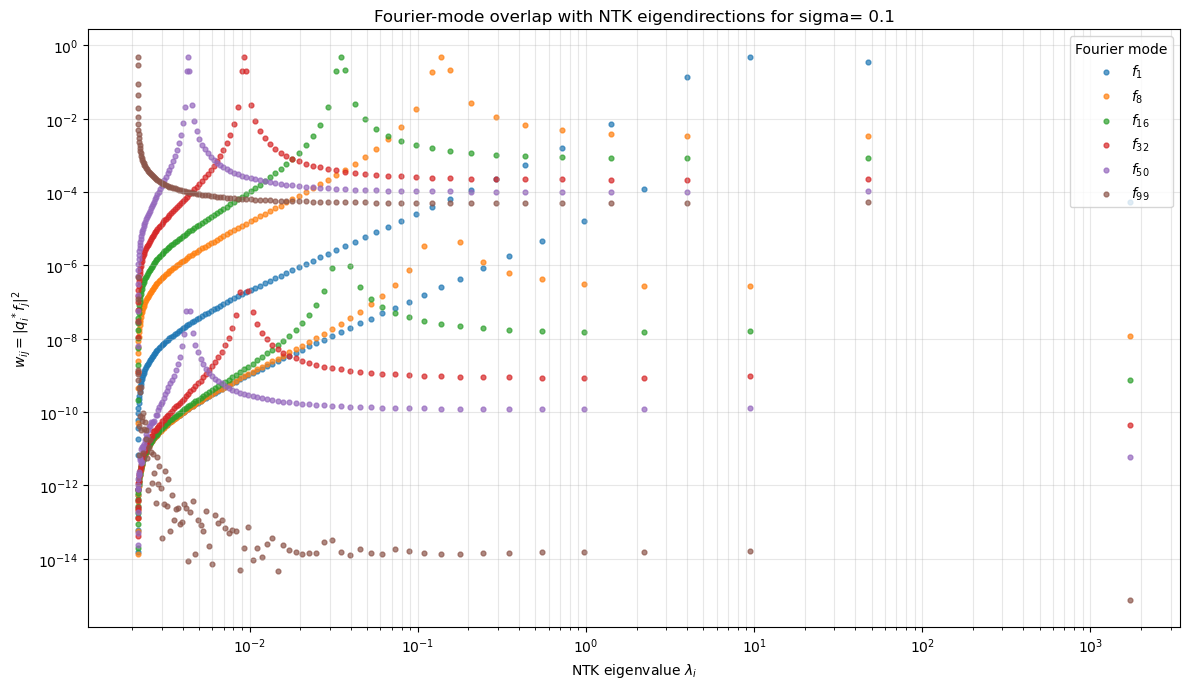

f_1: sum_i w_ij = 1.000000000000
f_8: sum_i w_ij = 1.000000000000
f_16: sum_i w_ij = 1.000000000000
f_32: sum_i w_ij = 1.000000000000
f_50: sum_i w_ij = 1.000000000000
f_99: sum_i w_ij = 1.000000000000


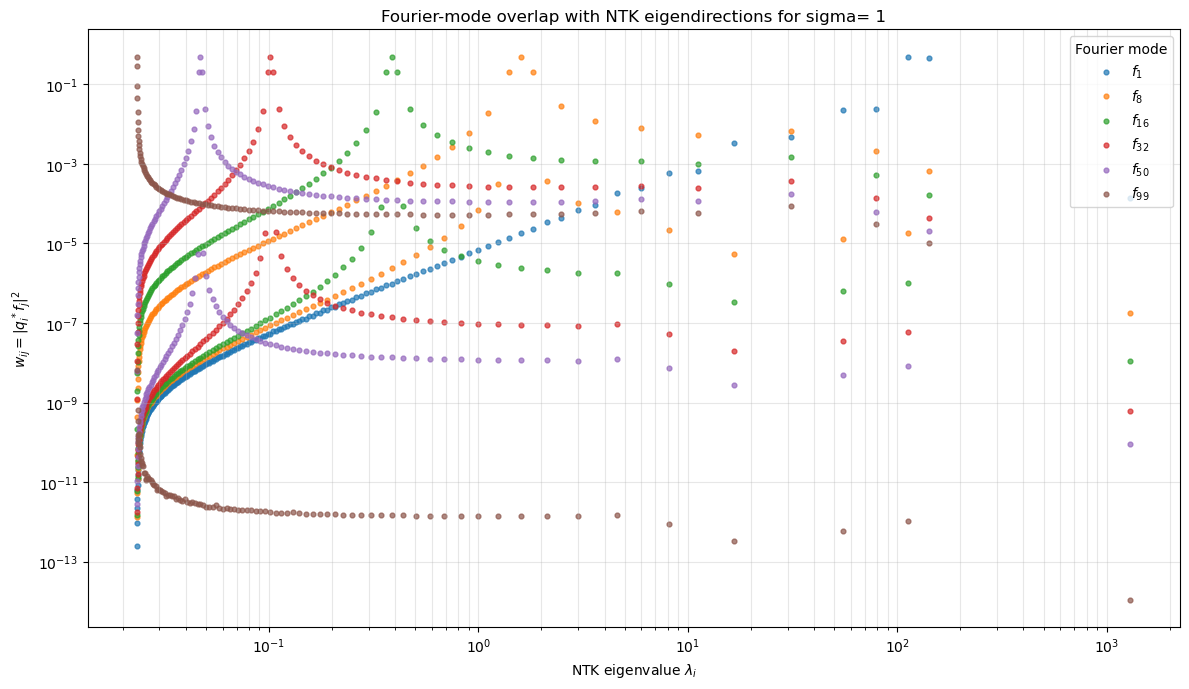

f_1: sum_i w_ij = 1.000000000000
f_8: sum_i w_ij = 1.000000000000
f_16: sum_i w_ij = 1.000000000000
f_32: sum_i w_ij = 1.000000000000
f_50: sum_i w_ij = 1.000000000000
f_99: sum_i w_ij = 1.000000000000


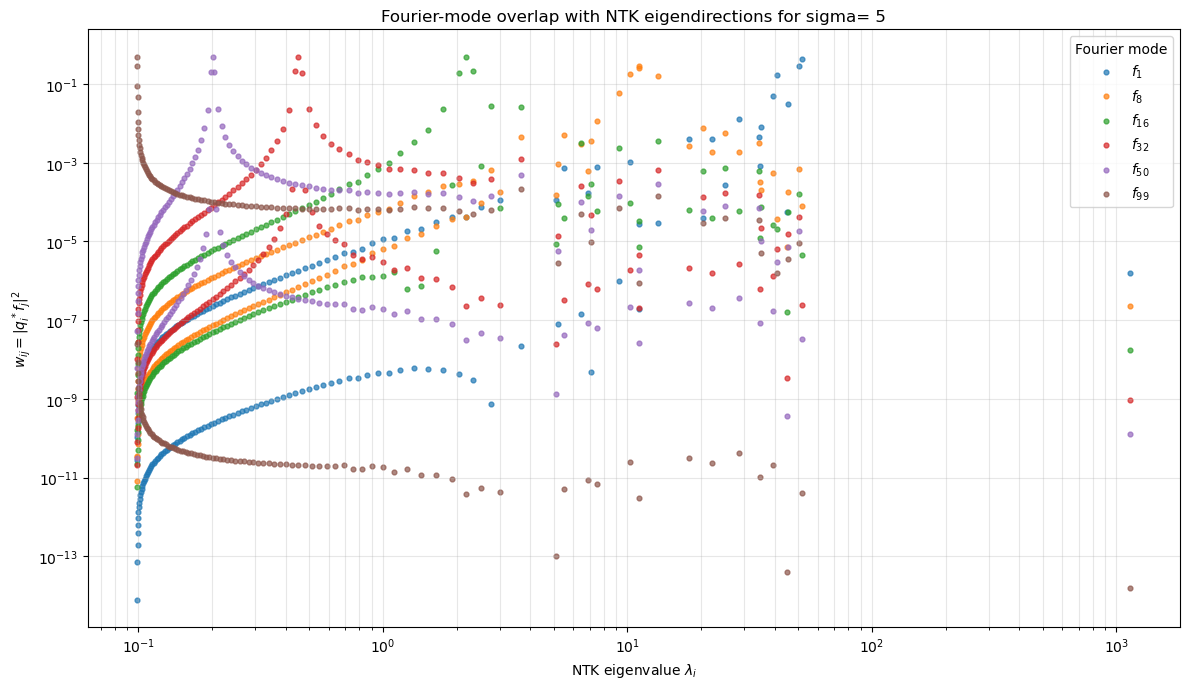

f_1: sum_i w_ij = 1.000000000000
f_8: sum_i w_ij = 1.000000000000
f_16: sum_i w_ij = 1.000000000000
f_32: sum_i w_ij = 1.000000000000
f_50: sum_i w_ij = 1.000000000000
f_99: sum_i w_ij = 1.000000000000


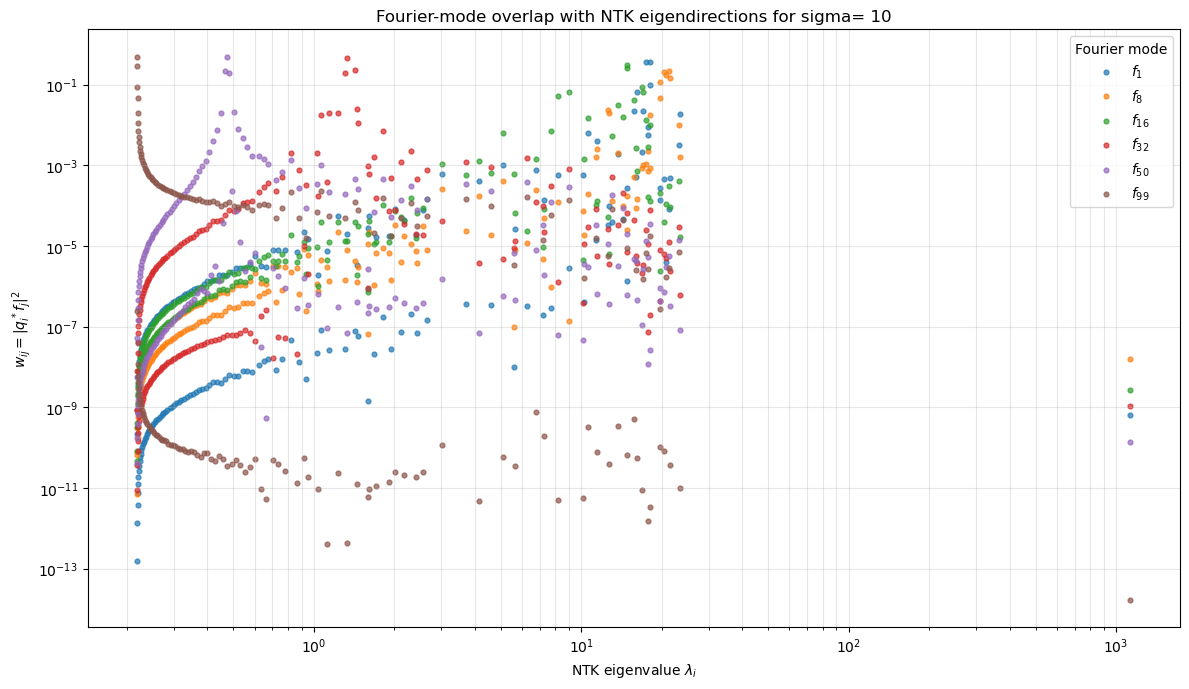

f_1: sum_i w_ij = 1.000000000000
f_8: sum_i w_ij = 1.000000000000
f_16: sum_i w_ij = 1.000000000000
f_32: sum_i w_ij = 1.000000000000
f_50: sum_i w_ij = 1.000000000000
f_99: sum_i w_ij = 1.000000000000


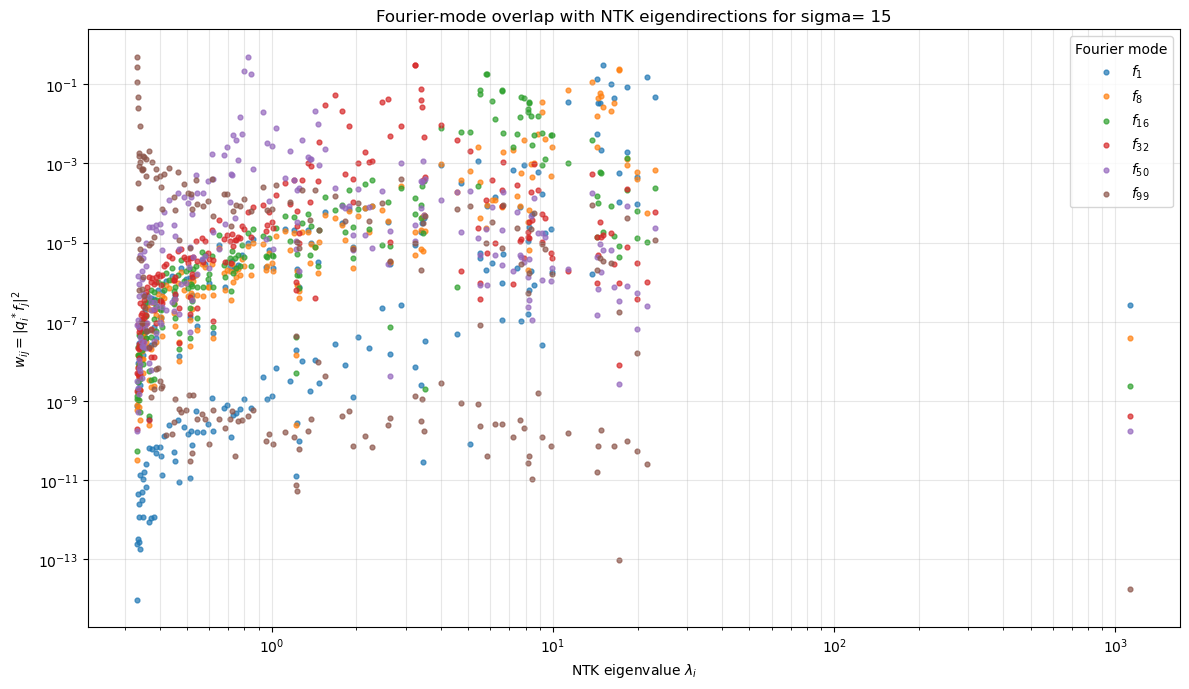

f_1: sum_i w_ij = 1.000000000000
f_8: sum_i w_ij = 1.000000000000
f_16: sum_i w_ij = 1.000000000000
f_32: sum_i w_ij = 1.000000000000
f_50: sum_i w_ij = 1.000000000000
f_99: sum_i w_ij = 1.000000000000


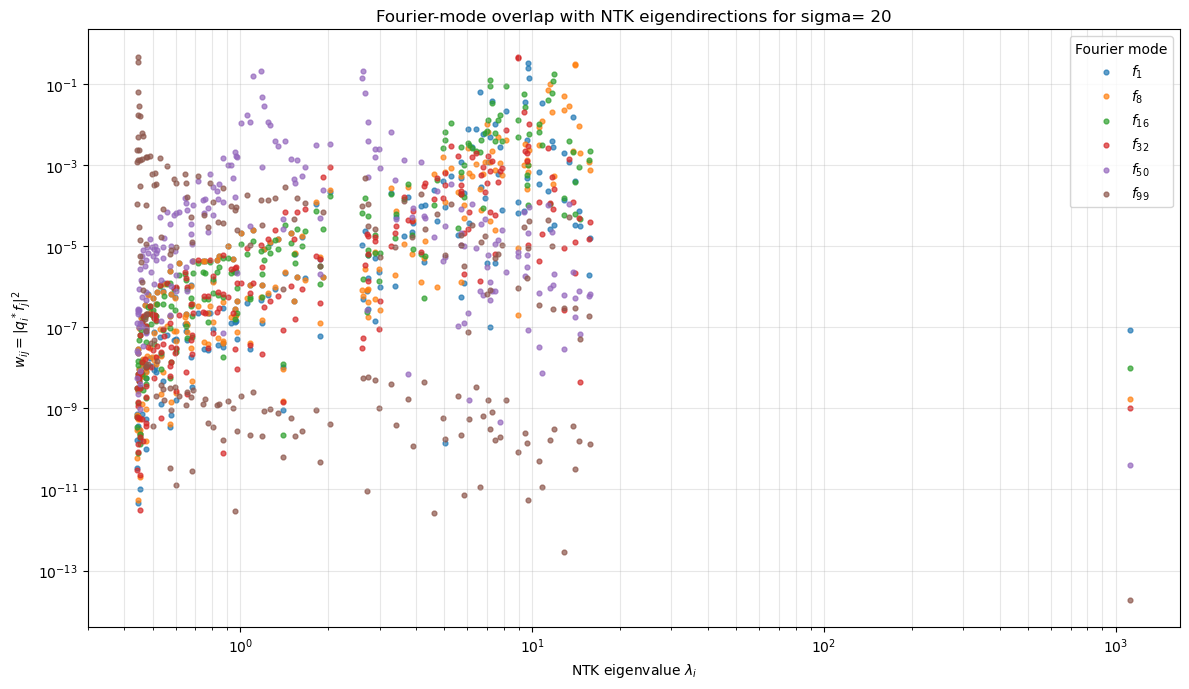

f_1: sum_i w_ij = 1.000000000000
f_8: sum_i w_ij = 1.000000000000
f_16: sum_i w_ij = 1.000000000000
f_32: sum_i w_ij = 1.000000000000
f_50: sum_i w_ij = 1.000000000000
f_99: sum_i w_ij = 1.000000000000


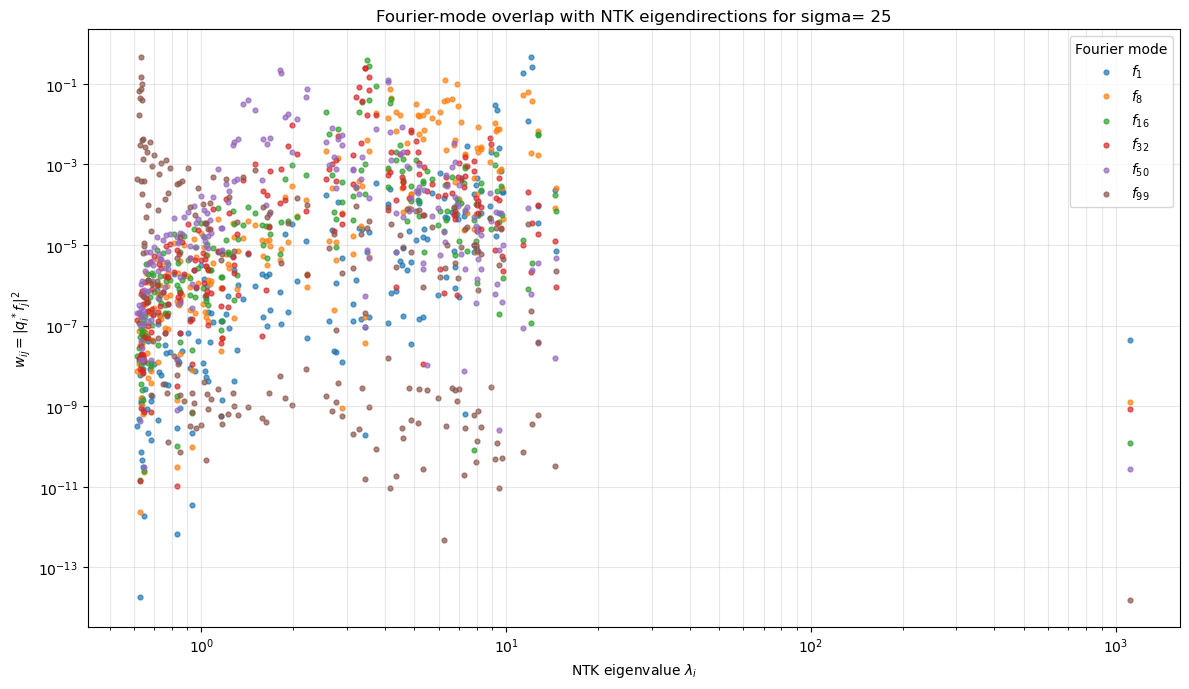

f_1: sum_i w_ij = 1.000000000000
f_8: sum_i w_ij = 1.000000000000
f_16: sum_i w_ij = 1.000000000000
f_32: sum_i w_ij = 1.000000000000
f_50: sum_i w_ij = 1.000000000000
f_99: sum_i w_ij = 1.000000000000


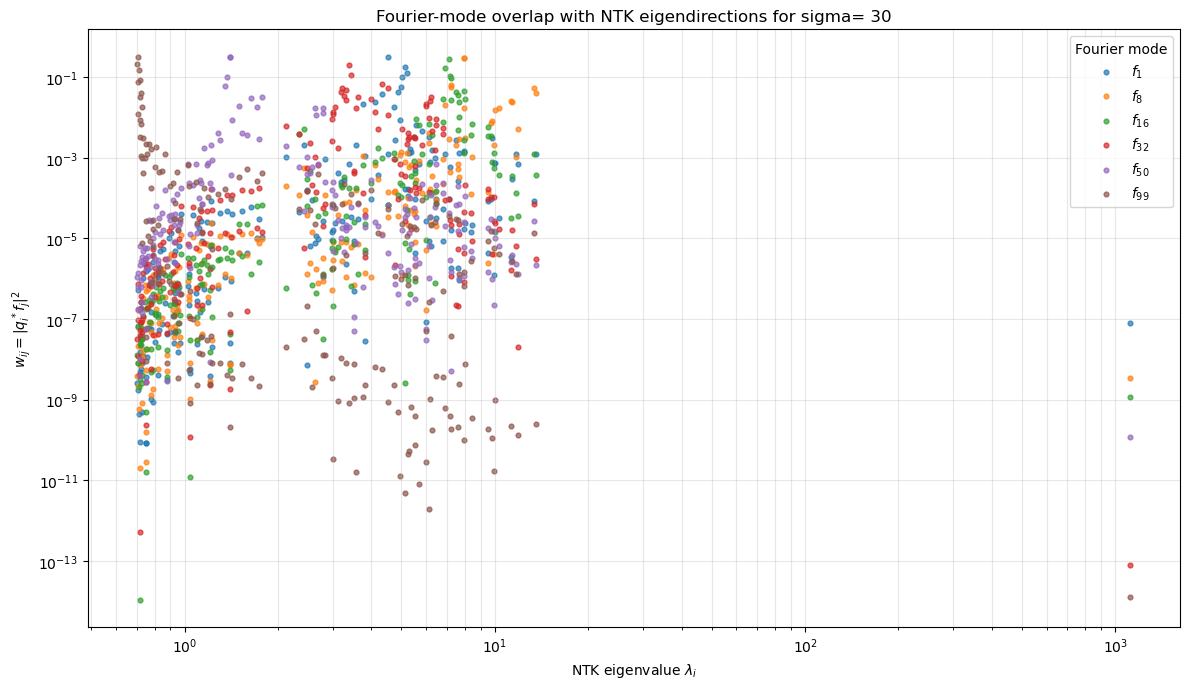

In [23]:
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# Plot w_ij = |q_i^* f_j|^2 against NTK eigenvalue lambda_i
#
# The function normalizes f_j internally, so w_ij is
# independent of epsilon0, eta, and training step.
# =========================================================


master_key = random.PRNGKey(0)
X_train, y_train, X_test, y_test, X_all, y_all = make_data(
    n_total=n_total,
    train_every=2,
)

# Full-grid coordinates and target values
x_full = X_all.reshape(-1)
y_true_plot = y_all.reshape(-1)
#used in the next cell
sigma_vals=[0.1,1,5,10,15,20,25,30]
for i, sigma in enumerate(sigma_vals): 
    key_B = random.fold_in(
        master_key,
        i + 100,
    )
    #same key throughout for sigma =5, it was third so index 2 in the list
    B, a = make_fourier_params(
        num_basis=num_basis,
        sigma=sigma,
        key=key_B,
    )
       
    X_train_ff = fourier_features(X_train, B, a)
    X_test_ff = fourier_features(X_test, B, a)
    X_all_ff = fourier_features(X_all, B, a)
    
    #INIT CONDITION NUMBER--> actually this must be X_all to match up later
    #these are different each time now
    #Again, don't think needed
    """
    params_init_ff = init_mlp_params(
                    key_B,
                    input_dim=X_all_ff.shape[-1],
                    width=1024,
                    depth=2,
                )
    """
    
    K_init_ff, _ = analytic_ntk_matrix_2(X_all_ff)
    eigenvalues, Q = ntk_eigendecomposition(K_init_ff)
    
    
    fig, ax = plt.subplots(
        figsize=(12, 7)
    )
    
    for j in j_values:
    
        results_j = fourier_error_by_ntk_mode(
            F=F,
            Q=Q,
            eigenvalues=eigenvalues,
            epsilon0=epsilon0,
            j=j,
            step=0,
            eta=eta_plot,
        )
    
        lambda_values = np.asarray(
            [
                result["eigenvalue"]
                for result in results_j
            ],
            dtype=float,
        )
    
        wij_values = np.asarray(
            [
                result["wij"]
                for result in results_j
            ],
            dtype=float,
        )
    
        # Logarithmic axes cannot display zero or negative
        # values. This removes only invalid log-plot points;
        # it does not impose a numerical tolerance.
        valid = (
            np.isfinite(lambda_values)
            & np.isfinite(wij_values)
            & (lambda_values > 0.0)
            & (wij_values > 0.0)
        )
    
        ax.scatter(
            lambda_values[valid],
            wij_values[valid],
            s=12,
            alpha=0.7,
            label=rf"$f_{{{j}}}$",
        )
    
        print(
            f"f_{j}: sum_i w_ij = "
            f"{np.sum(wij_values):.12f}"
        )
    
    
    ax.set_xscale("log")
    ax.set_yscale("log")
    
    ax.set_xlabel(
        r"NTK eigenvalue $\lambda_i$"
    )
    
    ax.set_ylabel(
        r"$w_{ij}=|q_i^*f_j|^2$"
    )
    
    ax.set_title(
        "Fourier-mode overlap with NTK eigendirections for sigma= "+str(sigma)
    )
    
    ax.grid(
        alpha=0.3,
        which="both",
    )
    
    ax.legend(
        title="Fourier mode"
    )
    
    plt.tight_layout()
    plt.show()

**The last plot is probably the most useful with the other plots justifying some of my reasoning**

## Section 6 - Extra Plots Mentioned In Email - Same as condition number section but now focusing on corrolation of A_{sigma} metric to MSE at end of training vs condition number vs effective rank to see what corrolates the most.

In [ ]:
import matplotlib.pyplot as plt
#HERE 1x2
scale = 1.5

plt.rcParams.update({
    "font.size": 10 * scale,
    "axes.titlesize": 12 * scale,
    "axes.labelsize": 10 * scale,
    "xtick.labelsize": 10 * scale,
    "ytick.labelsize": 10 * scale,
    "legend.fontsize": 10 * scale,
    "figure.titlesize": 12 * scale,
})

print("start")
# ----- Condition number, MSE, A metric and effective-rank plots -----

num_basis = 128
p = 0
width = 4
depth = 2
master_key = random.PRNGKey(0)
n_steps = 20000

X_train, y_train, X_test, y_test, X_all, y_all = make_data(
    n_total=500,
    train_every=2,
)

sigma_values = [0.1, 1, 5, 10, 20, 50, 100, 500]

MSE_TRAIN_S = []
MSE_TEST_S = []
A_METRIC_S = []
COND_NTK_S = []
EFF_RANK_S = []

for sigma_idx, sigma in enumerate(sigma_values):

    train_mse_ff_list = []
    test_mse_ff_list = []
    cond_ff_list = []
    A_list = []
    eff_r_list = []

    for j in range(5):

        key_model = random.fold_in(master_key + j, 1)
        key_B = random.fold_in(
            master_key + j,
            sigma_idx + 100,
        )

        B, a = make_fourier_params(
            num_basis=num_basis,
            sigma=sigma,
            key=key_B,
        )

        X_train_ff = fourier_features(X_train, B, a)
        X_test_ff = fourier_features(X_test, B, a)
        X_all_ff = fourier_features(X_all, B, a)

        (
            params_ff,
            y_pred_test_ff,
            train_mse_ff,
            test_mse_ff,
        ) = train_one_model(
            key_model,
            X_train_ff,
            y_train,
            X_test_ff,
            y_test,
            width=width,
            depth=depth,
            steps=n_steps,
            lr=1e-3,
            verbose=False,
        )

        K_comp_ff, _ = analytic_ntk_matrix_2(X_all_ff
        
        )
        #empirical fix

        cond_ff, _ = condition_number_psd(
            K_comp_ff,
            rtol=1e-9,
        )

        eigenvalues, eigenvectors = ntk_eigendecomposition(
            K_comp_ff
        )

        eigenvalues = np.asarray(eigenvalues).reshape(-1)
        eigenvectors = np.asarray(eigenvectors)

        c_ordered = (
            eigenvectors.T
            @ np.asarray(y_all).reshape(-1)
        )

        n_remove = int(np.ceil(0.10 * len(eigenvalues)))

        keep = np.zeros(len(eigenvalues), dtype=bool)
        keep[n_remove:] = True

        A = (
            np.sum(c_ordered[keep] ** 2)
            / np.sum(c_ordered ** 2)
        )

        effective_rank = effective_rank_from_eigvals(
            eigenvalues
        )

        train_mse_ff_list.append(float(train_mse_ff))
        test_mse_ff_list.append(float(test_mse_ff))
        cond_ff_list.append(float(cond_ff))
        A_list.append(float(A))
        eff_r_list.append(float(effective_rank))

    MSE_TRAIN_S.append(np.mean(train_mse_ff_list))
    MSE_TEST_S.append(np.mean(test_mse_ff_list))
    A_METRIC_S.append(np.mean(A_list))
    COND_NTK_S.append(np.mean(cond_ff_list))
    EFF_RANK_S.append(np.mean(eff_r_list))

    print(
        f"sigma={sigma}: "
        f"A={A_METRIC_S[-1]:.3e}, "
        f"train={MSE_TRAIN_S[-1]:.3e}, "
        f"test={MSE_TEST_S[-1]:.3e}, "
        f"condition={COND_NTK_S[-1]:.3e}, "
        f"rank={EFF_RANK_S[-1]:.3f}"
    )


# =========================================================
# Log-log plots with least-squares best-fit lines
# =========================================================

def plot_loglog_fit(ax, x, y, ylabel):

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = (
        np.isfinite(x)
        & np.isfinite(y)
        & (x > 0)
        & (y > 0)
    )

    x = x[valid]
    y = y[valid]

    # Least-squares fit:
    # log10(y) = slope * log10(x) + intercept
    slope, intercept = np.polyfit(
        np.log10(x),
        np.log10(y),
        1,
    )

    # Evaluate only at the existing x values.
    order = np.argsort(x)
    x_sorted = x[order]

    y_fit = 10 ** np.polyval(
        [slope, intercept],
        np.log10(x_sorted),
    )

    ax.loglog(
        x,
        y,
        "o",
        label="Data",
    )

    ax.loglog(
        x_sorted,
        y_fit,
        "--",
        label=rf"Best fit: $y \propto x^{{{slope:.2f}}}$",
    )

    ax.set_xlabel("A metric")
    ax.set_ylabel(ylabel)
    ax.grid(True, which="both")
    ax.legend()


fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9),
)

plot_loglog_fit(
    axes[0, 0],
    A_METRIC_S,
    MSE_TRAIN_S,
    "Mean train MSE",
)

plot_loglog_fit(
    axes[0, 1],
    A_METRIC_S,
    MSE_TEST_S,
    "Mean test MSE",
)

plot_loglog_fit(
    axes[1, 0],
    A_METRIC_S,
    COND_NTK_S,
    "Mean NTK condition number",
)

plot_loglog_fit(
    axes[1, 1],
    A_METRIC_S,
    EFF_RANK_S,
    "Mean effective rank",
)

plt.tight_layout()
plt.show()

start


## Cell below confirms if previous averaged-condition numbers + effective rank still match up 

They didn't because these ones run on (xi,xj) 500. Ie they use x_all since x_all is needed when doing decomposition into the eigenbasis. Formally, we needed the same number of vectors as there were points sampled when I was relating the Fourier basis to the eigenbasis. I might be able to change this to just have it be on x_train as opposed to x_all (ie init the mlp weights to be of length x_train and pass x_train only for the condition number but it would mess up my other plots I think).

The old discrepancy was caused by the number of sampled points differing by a factor of 10 and they are now the same. I revisited the earlier section and changed it.



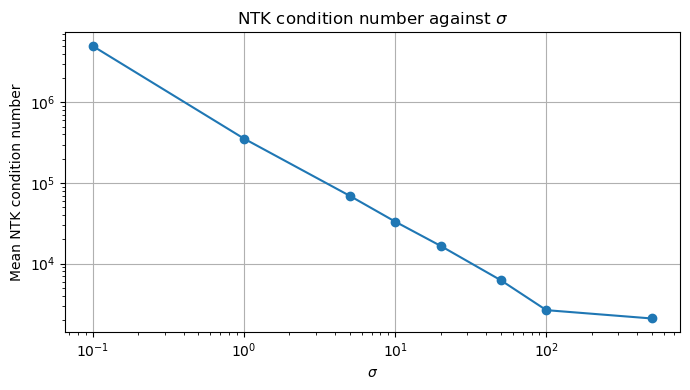

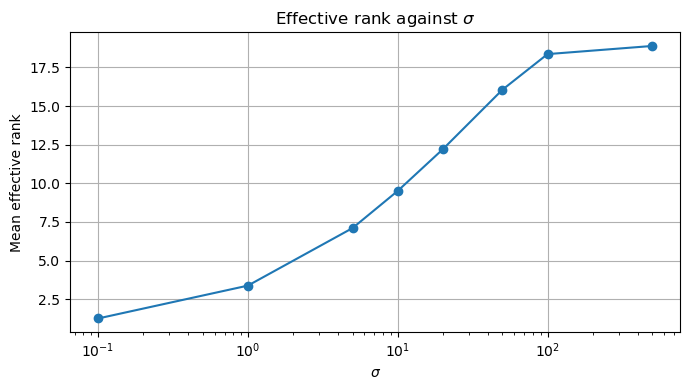

In [25]:
plt.figure(figsize=(7, 4))

plt.plot(
    sigma_values,
    COND_NTK_S,
    marker="o",
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$\sigma$")
plt.ylabel("Mean NTK condition number")
plt.title(r"NTK condition number against $\sigma$")

plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(
    figsize=(7, 4)
)

plt.plot(
    sigma_values,
    EFF_RANK_S,
    marker="o",
)

plt.xscale(
    "log"
)

plt.xlabel(
    r"$\sigma$"
)

plt.ylabel(
    "Mean effective rank"
)

plt.title(
    r"Effective rank against $\sigma$"
)

plt.grid(True)
plt.tight_layout()
plt.show()

## A controlled Experiment to show for fixed sigma=5, how varying the number of sampled points effects the expected NTK condition Number

sample_n = 100, condition number = 2.627798e+03
sample_n = 500, condition number = 6.121000e+04
sample_n = 1000, condition number = 2.891335e+05
sample_n = 2000, condition number = 1.074340e+06
sample_n = 4000, condition number = 4.469675e+06
sample_n = 8000, condition number = 1.824998e+07
sample_n = 16000, condition number = 7.028574e+07


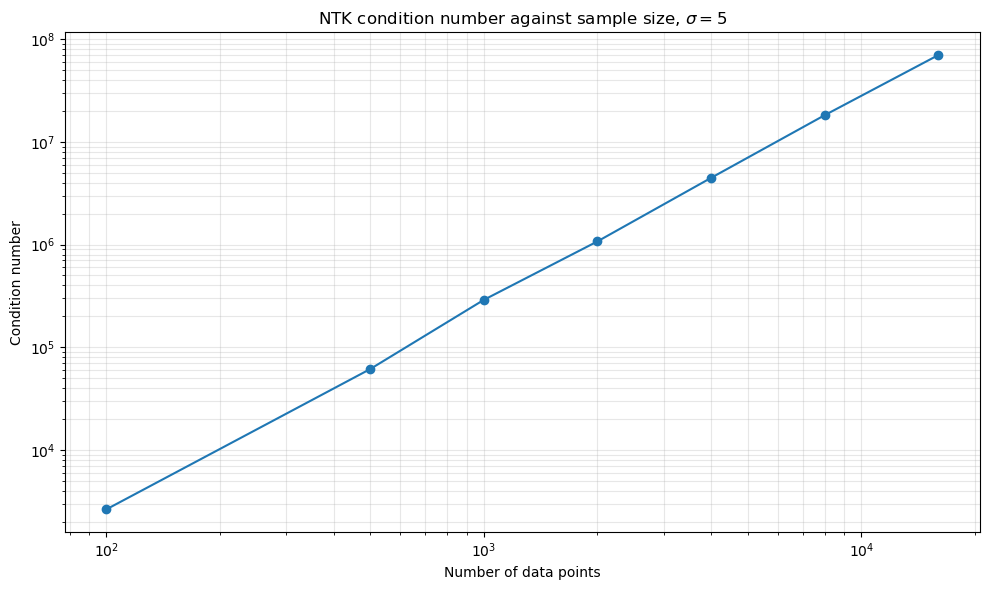

In [26]:
make_data_vals = [100, 500, 1000, 2000, 4000, 8000, 16000] #runs out of memory for anything higher! or well, for 32k
sigma = 5

master_key = random.PRNGKey(0)
cond_s_plot = []

for ind, sample_n in enumerate(make_data_vals):
    X_train_s, y_train_s, X_test_s, y_test_s, X_all_s, y_all_s = make_data(
        n_total=sample_n,
        train_every=2,
    )

    # Full-grid coordinates and target values
    x_full_s = X_all_s.reshape(-1)
    y_true_plot_s = y_all_s.reshape(-1)

    key_B = random.fold_in(
        master_key,
        ind + 100,
    )

    B_s, a_s = make_fourier_params(
        num_basis=num_basis,
        sigma=sigma,
        key=key_B,
    )

    X_train_ff_s = fourier_features(X_train_s, B_s, a_s)
    X_test_ff_s = fourier_features(X_test_s, B_s, a_s)
    X_all_ff_s = fourier_features(X_all_s, B_s, a_s)

    K_init_ff_s, _s = analytic_ntk_matrix_2(X_all_ff_s)

    # Eigenvalues are assumed to be handled in ascending order internally.
    cond_s, _s = condition_number_psd(K_init_ff_s)
    cond_s_plot.append(float(cond_s))

    print(
        f"sample_n = {sample_n}, "
        f"condition number = {float(cond_s):.6e}"
    )


plt.figure(figsize=(10, 6))

plt.plot(
    make_data_vals,
    cond_s_plot,
    marker="o",
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Number of data points")
plt.ylabel("Condition number")
plt.title(r"NTK condition number against sample size, $\sigma=5$")

plt.grid(
    alpha=0.3,
    which="both",
)

plt.tight_layout()
plt.show()

    
    

## As Discussed, Eigenvalues may be 'similar' and so a spectral decomp might be better, since if repeated eigens, then choice of eigenbasis for decomp not unique. Spectral guarantees uniqueness, but all results so far I don't think have had 'noisy eigenvalues' since the expected NTK calc was correctly done.

The following repeats the previous experiment. For each fixed sampled Fourier mode

$$
\mathbf{f}_j,
$$

I compute

$$
\left|P_{\lambda_i}\mathbf{f}_j\right|_2^2
$$

over all (i), where (|\cdot|_2) denotes the Euclidean norm on (\mathbb{C}^N).



In [17]:
def spectral_projectors(matrix, tol=1e-9):
    """takes in matrix, within tol then finds eigenvalues.
        will consider those eigenvalues within tol of one and other 
        as repeated and sum their projections to get the overall projection
        into that eigenspace which is the unique quantity we want"""
    
    A = np.asarray(matrix, dtype=float)

    # Only check: A must be symmetric.
    if not np.allclose(A, A.T, atol=tol, rtol=tol):
        raise ValueError("Matrix must be symmetric.")

    # Eigenvalues are returned smallest to largest.
    # The columns of eigenvectors are the corresponding eigenvectors.
    eigenvalues, eigenvectors = np.linalg.eigh(A)

    projectors = []
    start = 0

    while start < len(eigenvalues):
        eigenvalue = eigenvalues[start]
        end = start + 1

        # Collect all eigenvectors belonging to the same repeated eigenvalue.
        while (
            end < len(eigenvalues)
            and np.isclose(
                eigenvalues[end],
                eigenvalue,
                atol=tol,
                rtol=tol,
            )
        ):
            end += 1

        # Orthonormal basis for the whole eigenspace E_lambda.
        Q_lambda = eigenvectors[:, start:end]

        # Orthogonal projector onto E_lambda.
        P_lambda = Q_lambda @ Q_lambda.T

        # Use the average because numerically repeated eigenvalues may differ
        # by tiny floating-point errors.
        eigenvalue = np.mean(eigenvalues[start:end])

        projectors.append((eigenvalue, P_lambda))

        start = end

    return projectors

def spectral_error_bins(F, spec_list, j):
    """for j, take fourier basis matrix F, find the jth vector
        and then for each spectral projection,
        project f_j into that eigenspace, take the norm square and 
        return the list of all projections"""
    f_j = F[:, j]
    coeffs = []

    for eigenvalue, P_lambda in spec_list:
        coeff = np.linalg.norm(P_lambda @ f_j, ord=2) ** 2
        coeffs.append(coeff)

    return coeffs
        
        




sigma = 0.1
smallest eigenvalue = 4.306683595138e-04
largest eigenvalue  = 8.643475026929e+03
within tol

sigma = 0.1
smallest eigenvalue = 4.306683595138e-04
largest eigenvalue  = 8.643475026929e+03
within tol

sigma = 0.1
smallest eigenvalue = 4.306683595138e-04
largest eigenvalue  = 8.643475026929e+03
within tol

sigma = 0.1
smallest eigenvalue = 4.306683595138e-04
largest eigenvalue  = 8.643475026929e+03
within tol

sigma = 0.1
smallest eigenvalue = 4.306683595138e-04
largest eigenvalue  = 8.643475026929e+03
within tol

sigma = 0.1
smallest eigenvalue = 4.306683595138e-04
largest eigenvalue  = 8.643475026929e+03
within tol

sigma = 0.1
smallest eigenvalue = 4.306683595138e-04
largest eigenvalue  = 8.643475026929e+03
within tol


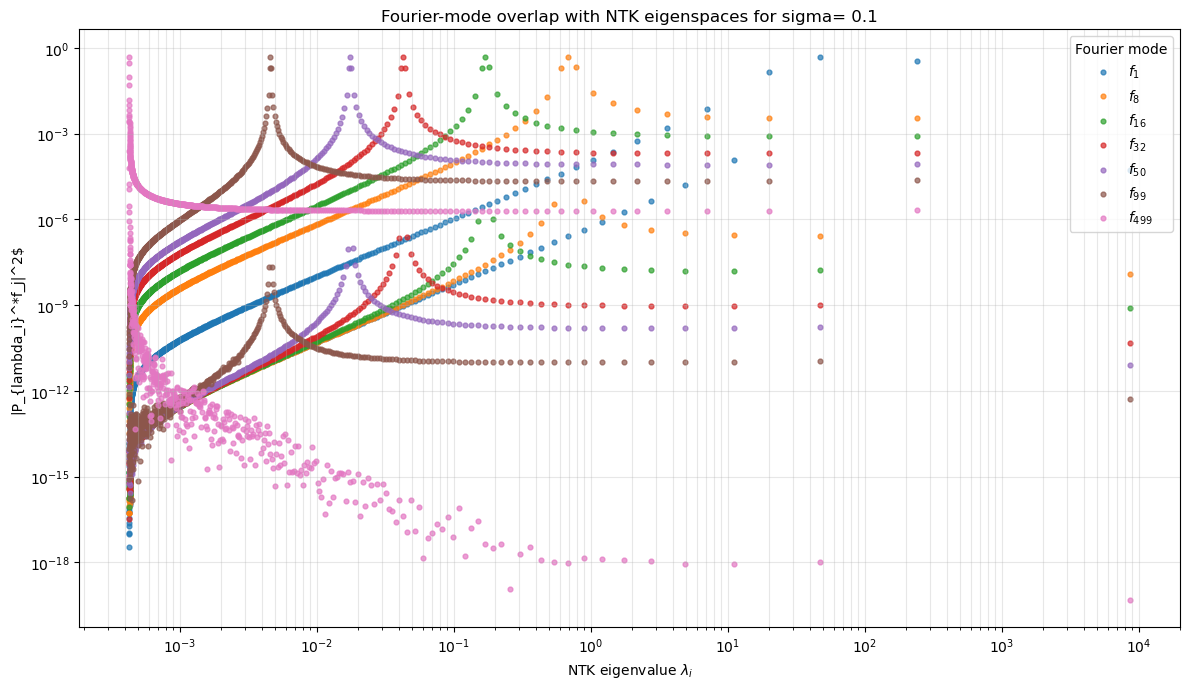


sigma = 1
smallest eigenvalue = 4.703184735972e-03
largest eigenvalue  = 6.477173330508e+03
within tol

sigma = 1
smallest eigenvalue = 4.703184735972e-03
largest eigenvalue  = 6.477173330508e+03
within tol

sigma = 1
smallest eigenvalue = 4.703184735972e-03
largest eigenvalue  = 6.477173330508e+03
within tol

sigma = 1
smallest eigenvalue = 4.703184735972e-03
largest eigenvalue  = 6.477173330508e+03
within tol

sigma = 1
smallest eigenvalue = 4.703184735972e-03
largest eigenvalue  = 6.477173330508e+03
within tol

sigma = 1
smallest eigenvalue = 4.703184735972e-03
largest eigenvalue  = 6.477173330508e+03
within tol

sigma = 1
smallest eigenvalue = 4.703184735972e-03
largest eigenvalue  = 6.477173330508e+03
within tol


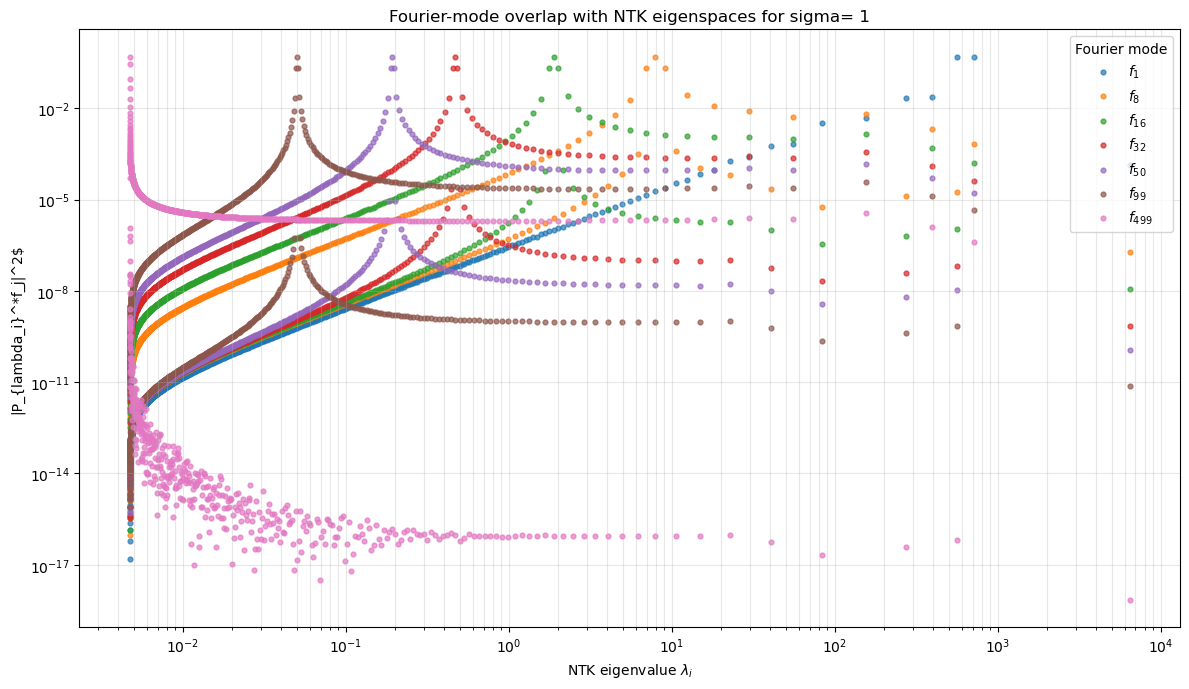


sigma = 5
smallest eigenvalue = 1.970972910311e-02
largest eigenvalue  = 5.698743340120e+03
within tol

sigma = 5
smallest eigenvalue = 1.970972910311e-02
largest eigenvalue  = 5.698743340120e+03
within tol

sigma = 5
smallest eigenvalue = 1.970972910311e-02
largest eigenvalue  = 5.698743340120e+03
within tol

sigma = 5
smallest eigenvalue = 1.970972910311e-02
largest eigenvalue  = 5.698743340120e+03
within tol

sigma = 5
smallest eigenvalue = 1.970972910311e-02
largest eigenvalue  = 5.698743340120e+03
within tol

sigma = 5
smallest eigenvalue = 1.970972910311e-02
largest eigenvalue  = 5.698743340120e+03
within tol

sigma = 5
smallest eigenvalue = 1.970972910311e-02
largest eigenvalue  = 5.698743340120e+03
within tol


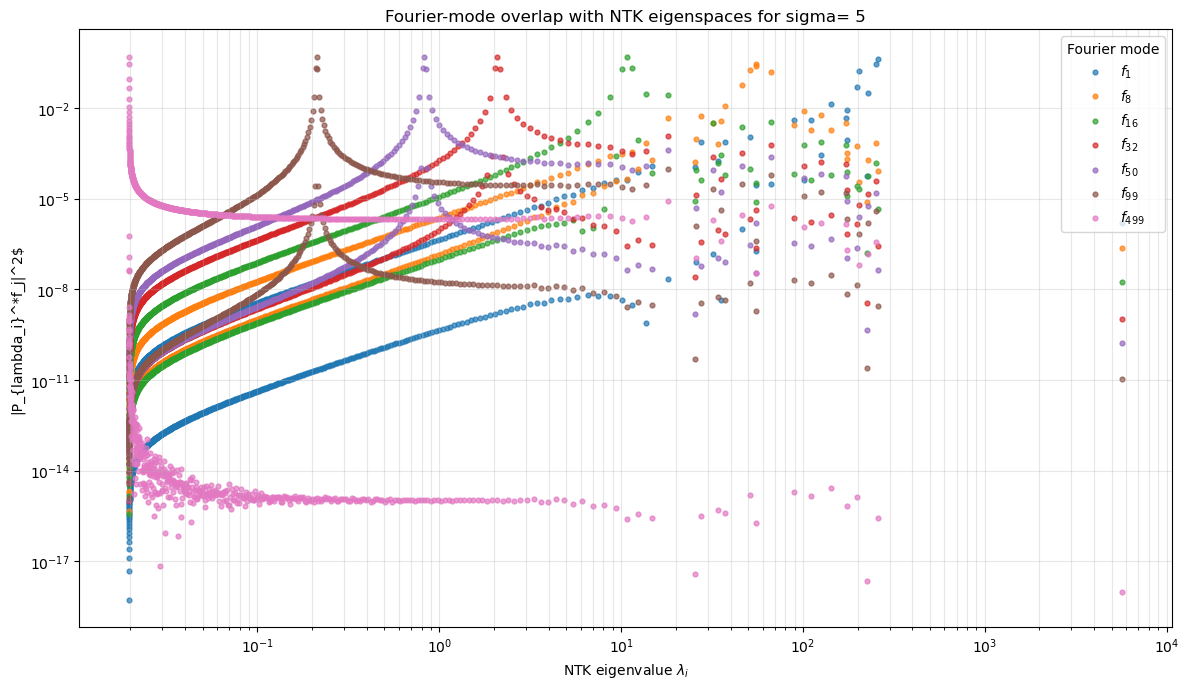


sigma = 10
smallest eigenvalue = 4.280003357566e-02
largest eigenvalue  = 5.657196194558e+03
within tol

sigma = 10
smallest eigenvalue = 4.280003357566e-02
largest eigenvalue  = 5.657196194558e+03
within tol

sigma = 10
smallest eigenvalue = 4.280003357566e-02
largest eigenvalue  = 5.657196194558e+03
within tol

sigma = 10
smallest eigenvalue = 4.280003357566e-02
largest eigenvalue  = 5.657196194558e+03
within tol

sigma = 10
smallest eigenvalue = 4.280003357566e-02
largest eigenvalue  = 5.657196194558e+03
within tol

sigma = 10
smallest eigenvalue = 4.280003357566e-02
largest eigenvalue  = 5.657196194558e+03
within tol

sigma = 10
smallest eigenvalue = 4.280003357566e-02
largest eigenvalue  = 5.657196194558e+03
within tol


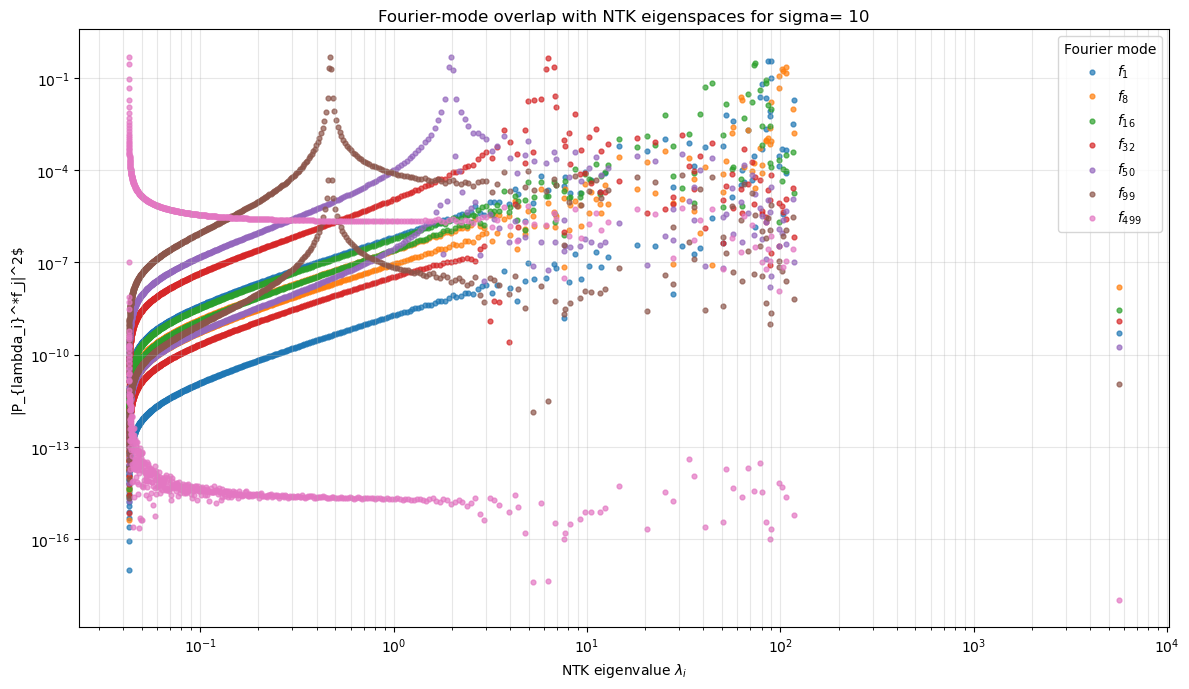


sigma = 15
smallest eigenvalue = 6.263422424136e-02
largest eigenvalue  = 5.652780636737e+03
within tol

sigma = 15
smallest eigenvalue = 6.263422424136e-02
largest eigenvalue  = 5.652780636737e+03
within tol

sigma = 15
smallest eigenvalue = 6.263422424136e-02
largest eigenvalue  = 5.652780636737e+03
within tol

sigma = 15
smallest eigenvalue = 6.263422424136e-02
largest eigenvalue  = 5.652780636737e+03
within tol

sigma = 15
smallest eigenvalue = 6.263422424136e-02
largest eigenvalue  = 5.652780636737e+03
within tol

sigma = 15
smallest eigenvalue = 6.263422424136e-02
largest eigenvalue  = 5.652780636737e+03
within tol

sigma = 15
smallest eigenvalue = 6.263422424136e-02
largest eigenvalue  = 5.652780636737e+03
within tol


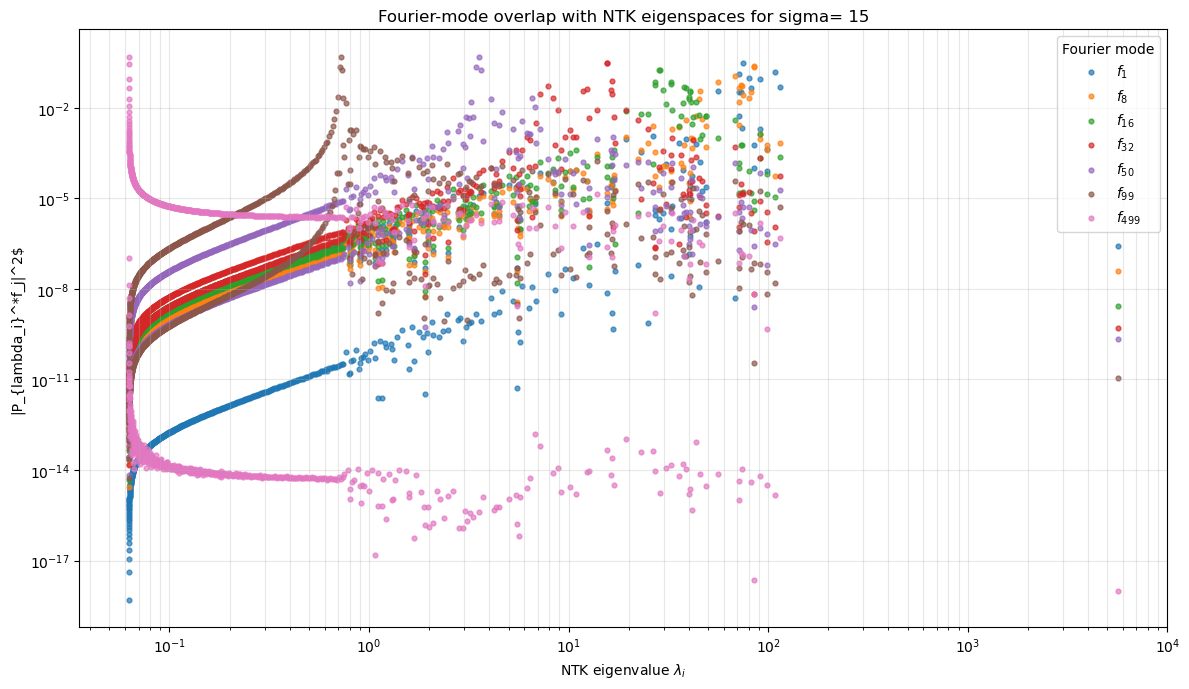


sigma = 20
smallest eigenvalue = 8.097160675794e-02
largest eigenvalue  = 5.610212182665e+03
within tol

sigma = 20
smallest eigenvalue = 8.097160675794e-02
largest eigenvalue  = 5.610212182665e+03
within tol

sigma = 20
smallest eigenvalue = 8.097160675794e-02
largest eigenvalue  = 5.610212182665e+03
within tol

sigma = 20
smallest eigenvalue = 8.097160675794e-02
largest eigenvalue  = 5.610212182665e+03
within tol

sigma = 20
smallest eigenvalue = 8.097160675794e-02
largest eigenvalue  = 5.610212182665e+03
within tol

sigma = 20
smallest eigenvalue = 8.097160675794e-02
largest eigenvalue  = 5.610212182665e+03
within tol

sigma = 20
smallest eigenvalue = 8.097160675794e-02
largest eigenvalue  = 5.610212182665e+03
within tol


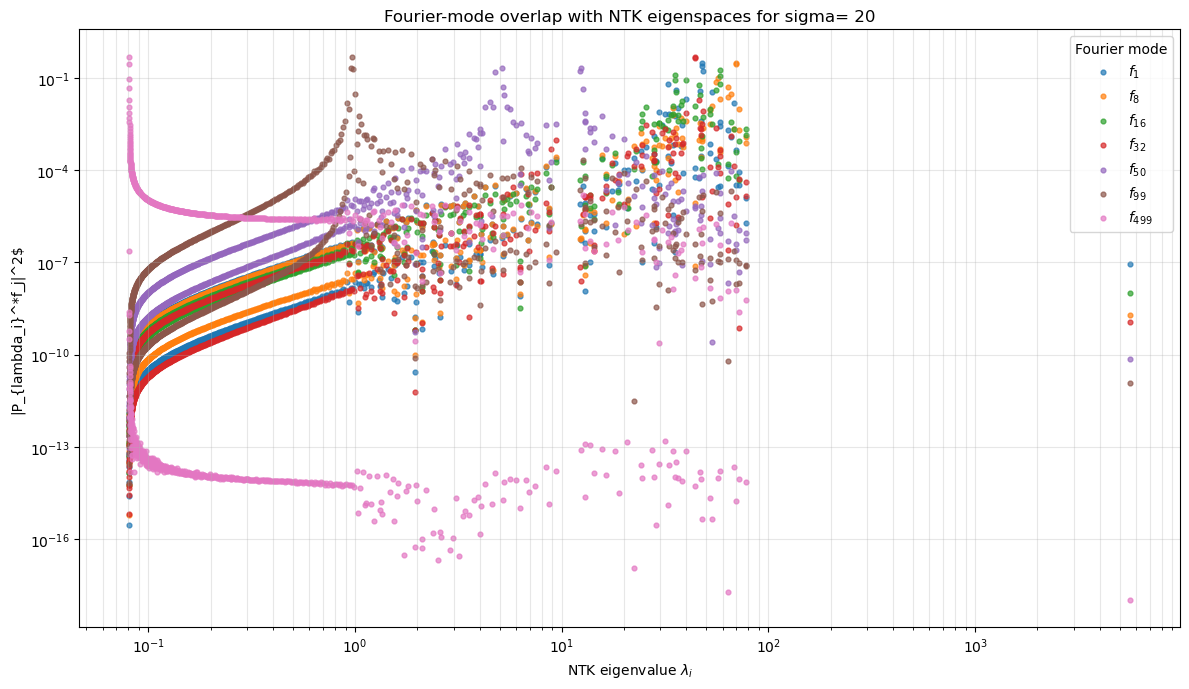


sigma = 25
smallest eigenvalue = 1.056940784539e-01
largest eigenvalue  = 5.590573429726e+03
within tol

sigma = 25
smallest eigenvalue = 1.056940784539e-01
largest eigenvalue  = 5.590573429726e+03
within tol

sigma = 25
smallest eigenvalue = 1.056940784539e-01
largest eigenvalue  = 5.590573429726e+03
within tol

sigma = 25
smallest eigenvalue = 1.056940784539e-01
largest eigenvalue  = 5.590573429726e+03
within tol

sigma = 25
smallest eigenvalue = 1.056940784539e-01
largest eigenvalue  = 5.590573429726e+03
within tol

sigma = 25
smallest eigenvalue = 1.056940784539e-01
largest eigenvalue  = 5.590573429726e+03
within tol

sigma = 25
smallest eigenvalue = 1.056940784539e-01
largest eigenvalue  = 5.590573429726e+03
within tol


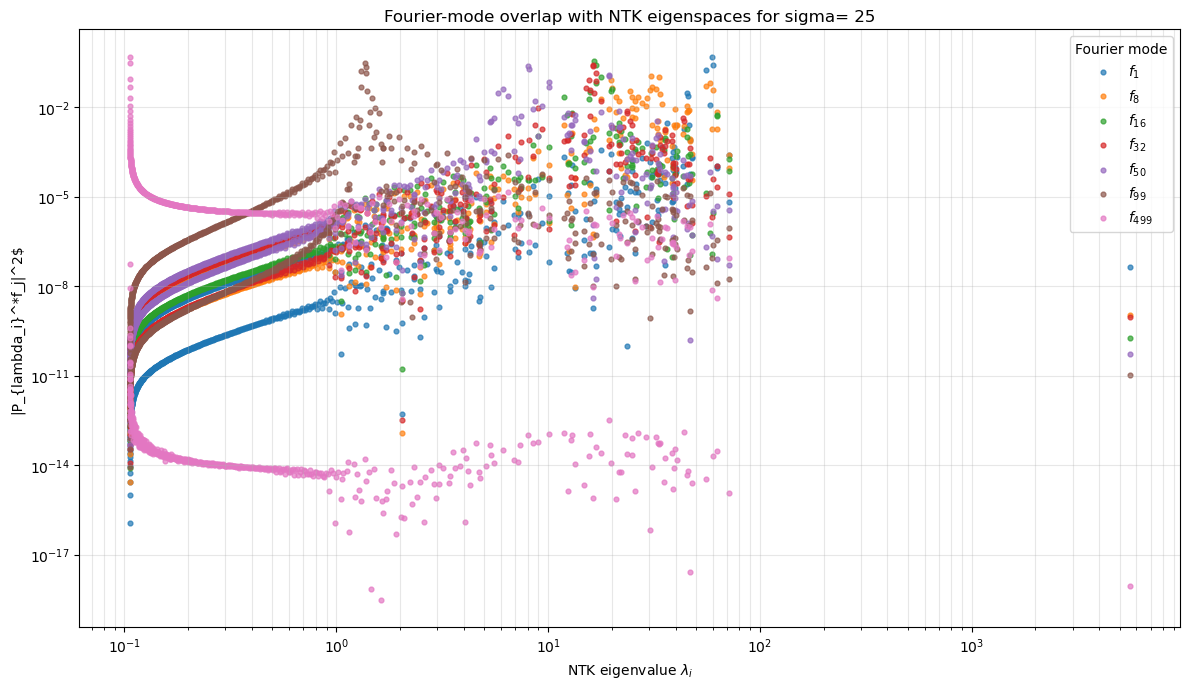


sigma = 30
smallest eigenvalue = 1.151034648992e-01
largest eigenvalue  = 5.587263649196e+03
within tol

sigma = 30
smallest eigenvalue = 1.151034648992e-01
largest eigenvalue  = 5.587263649196e+03
within tol

sigma = 30
smallest eigenvalue = 1.151034648992e-01
largest eigenvalue  = 5.587263649196e+03
within tol

sigma = 30
smallest eigenvalue = 1.151034648992e-01
largest eigenvalue  = 5.587263649196e+03
within tol

sigma = 30
smallest eigenvalue = 1.151034648992e-01
largest eigenvalue  = 5.587263649196e+03
within tol

sigma = 30
smallest eigenvalue = 1.151034648992e-01
largest eigenvalue  = 5.587263649196e+03
within tol

sigma = 30
smallest eigenvalue = 1.151034648992e-01
largest eigenvalue  = 5.587263649196e+03
within tol


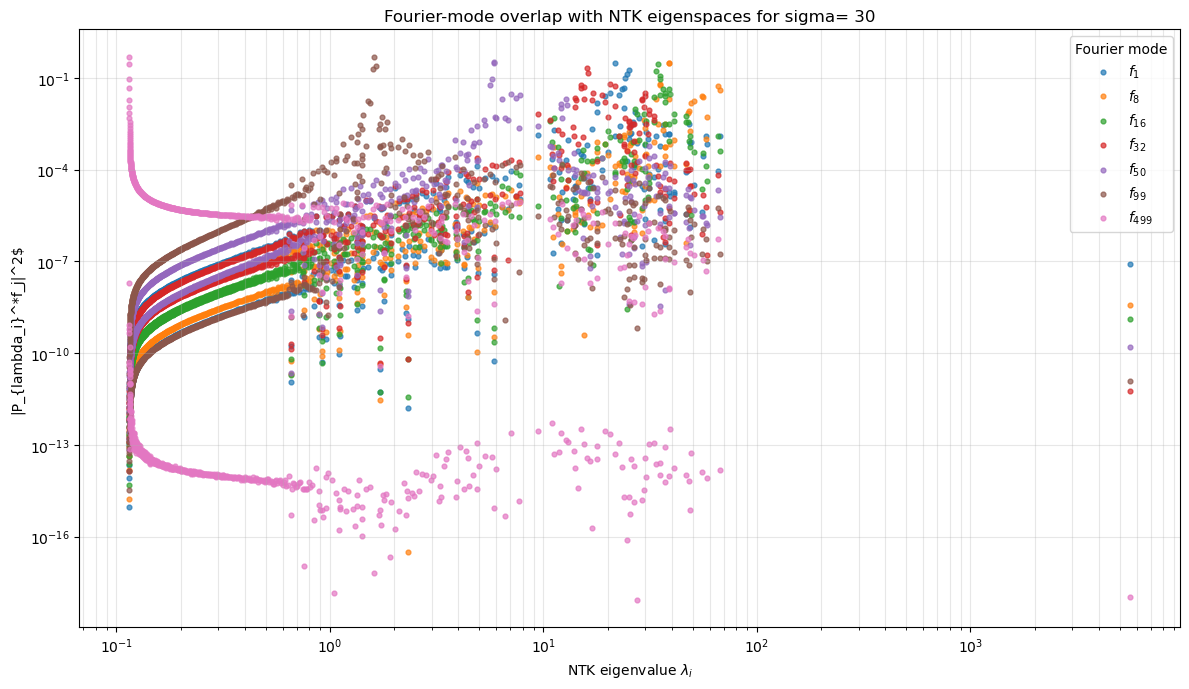

In [19]:
import numpy as np
import matplotlib.pyplot as plt

n_total=1000
# =========================================================
# Plot w_ij = |q_i^* f_j|^2 against NTK eigenvalue lambda_i
#
# The function normalizes f_j internally, so w_ij is
# independent of epsilon0, eta, and training step.
# =========================================================


master_key = random.PRNGKey(0)
X_train, y_train, X_test, y_test, X_all, y_all = make_data(
    n_total=n_total,
    train_every=2,
)

# Full-grid coordinates and target values
x_full = X_all.reshape(-1)
y_true_plot = y_all.reshape(-1)
#used in the next cell
sigma_vals=[0.1,1,5,10,15,20,25,30]
for i, sigma in enumerate(sigma_vals): 
    key_B = random.fold_in(
        master_key,
        i + 100,
    )
    #same key throughout for sigma =5, it was third so index 2 in the list
    B, a = make_fourier_params(
        num_basis=num_basis,
        sigma=sigma,
        key=key_B,
    )
       
    X_train_ff = fourier_features(X_train, B, a)
    X_test_ff = fourier_features(X_test, B, a)
    X_all_ff = fourier_features(X_all, B, a)
    
    #INIT CONDITION NUMBER--> actually this must be X_all to match up later
    #these are different each time now
    #i dont think this is needed?
    params_init_ff = init_mlp_params(
                    key_B,
                    input_dim=X_all_ff.shape[-1],
                    width=1024,
                    depth=2,
                )
    
    K_init_ff, _ = analytic_ntk_matrix_2(X_all_ff)
    #swap to spectral
    
    
    
    fig, ax = plt.subplots(
        figsize=(12, 7)
    )
    
    spec_list = spectral_projectors(K_init_ff)


    for k in j_values:
    
        coeff_values = np.asarray(
            spectral_error_bins(
                F=F,
                spec_list=spec_list,
                j=k,
            ),
            dtype=float,
        )
    
        lambda_values = np.asarray(
            [
                eigenvalue
                for eigenvalue, P_lambda in spec_list
            ],
            dtype=float,
        )

        smallest_eigenvalue = np.min(lambda_values)
        largest_eigenvalue = np.max(lambda_values)
        
        print(f"\nsigma = {sigma}")
        print(f"smallest eigenvalue = {smallest_eigenvalue:.12e}")
        print(f"largest eigenvalue  = {largest_eigenvalue:.12e}")
        
        if smallest_eigenvalue > 1e-9*largest_eigenvalue:
            print("within tol")
        else:
            print("not within tol")
    
        # Keep finite, positive eigenvalues and projections whose
        # squared norm is larger than the chosen numerical tolerance.
        valid = (
            np.isfinite(lambda_values)
            & np.isfinite(coeff_values)
            & (lambda_values > 0.0)
        )
    
        lambda_values_valid = lambda_values[valid]
        coeff_values_valid = coeff_values[valid]
    
        ax.scatter(
            lambda_values[valid],
            coeff_values[valid],
            s=12,
            alpha=0.7,
            label=rf"$f_{{{k}}}$",
        )
    
    
    ax.set_xscale("log")
    ax.set_yscale("log")
    
    ax.set_xlabel(
        r"NTK eigenvalue $\lambda_i$"
    )
    
    ax.set_ylabel(
        r"|P_{lambda_i}^*f_j|^2$"
    )
    
    ax.set_title(
        "Fourier-mode overlap with NTK eigenspaces for sigma= "+str(sigma)
    )
    
    ax.grid(
        alpha=0.3,
        which="both",
    )
    
    ax.legend(
        title="Fourier mode"
    )
    
    plt.tight_layout()
    plt.show()

start

sigma = 0.1
||KJ - JK||_F = 6.639933921868e-07
relative ||KJ - JK||_F / ||K||_F = 7.678931037054e-11

index | eigenvalue | parity | dimension
------------------------------------------------
  0 |  4.30668360e-04 | -0.98265206 | 1
  1 |  4.30671661e-04 |  0.97824395 | 1
  2 |  4.30676050e-04 | -0.99213223 | 1
  3 |  4.30683975e-04 |  0.98629901 | 1
  4 |  4.30693508e-04 | -0.98669538 | 1
  5 |  4.30704561e-04 |  0.99411188 | 1
  6 |  4.30718806e-04 | -0.99524333 | 1
  7 |  4.30734815e-04 |  0.99773608 | 1
  8 |  4.30752757e-04 | -0.99888165 | 1
  9 |  4.30772586e-04 |  0.99899751 | 1
 10 |  4.30795445e-04 | -0.99938023 | 1
 11 |  4.30819779e-04 |  0.99946208 | 1
 12 |  4.30846614e-04 | -0.99962127 | 1
 13 |  4.30875352e-04 |  0.99941976 | 1
 14 |  4.30905695e-04 | -0.99882015 | 1
 15 |  4.30939154e-04 |  0.99830903 | 1
 16 |  4.30973800e-04 | -0.99888181 | 1
 17 |  4.31011308e-04 |  0.99963213 | 1
 18 |  4.31050472e-04 | -0.99975936 | 1
 19 |  4.31092038e-04 |  0.99952577 | 1
 2

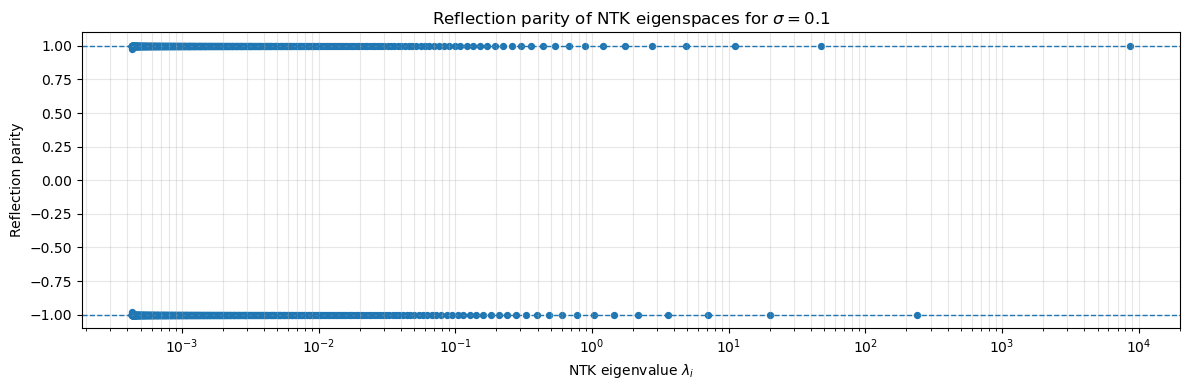

In [23]:
# =========================================================
# Reflection parity check for sigma = 0.1 only
# =========================================================

import numpy as np
import matplotlib.pyplot as plt


sigma = 0.1

# Same key as sigma = 0.1 in your spectral plots
key_B = random.fold_in(
    master_key,
    0 + 100,
)

B, a = make_fourier_params(
    num_basis=num_basis,
    sigma=sigma,
    key=key_B,
)

X_all_ff = fourier_features(
    X_all,
    B,
    a,
)

# Analytic NTK on the full grid
K_init_ff, _ = analytic_ntk_matrix_2(
    X_all_ff
)

K_init_ff = np.asarray(
    K_init_ff,
    dtype=float,
)

# Same eigenspace grouping as before
spec_list = spectral_projectors(
    K_init_ff
)


# =========================================================
# Reflection operator
# =========================================================

N = K_init_ff.shape[0]

J = np.eye(N)[::-1]


# Check whether K approximately commutes with reflection
commutator_norm = np.linalg.norm(
    K_init_ff @ J
    - J @ K_init_ff,
    ord="fro",
)

relative_commutator = (
    commutator_norm
    / np.linalg.norm(
        K_init_ff,
        ord="fro",
    )
)

print("start")
print()
print(f"sigma = {sigma}")

print(
    "||KJ - JK||_F = "
    f"{commutator_norm:.12e}"
)

print(
    "relative ||KJ - JK||_F / ||K||_F = "
    f"{relative_commutator:.12e}"
)


# =========================================================
# Reflection parity of each NTK eigenspace
# =========================================================

lambda_values = []
parity_values = []
eigenspace_dims = []

for eigenvalue, P_lambda in spec_list:

    # Dimension of the eigenspace
    eigenspace_dim = int(
        np.rint(
            np.trace(P_lambda)
        )
    )

    # trace(P_lambda @ J), calculated without performing
    # the full matrix multiplication P_lambda @ J.
    #
    # Since J reverses the columns, this is the sum of
    # the anti-diagonal of P_lambda.
    parity = (
        np.sum(
            np.diag(
                np.fliplr(P_lambda)
            )
        )
        / eigenspace_dim
    )

    lambda_values.append(
        float(eigenvalue)
    )

    parity_values.append(
        float(parity)
    )

    eigenspace_dims.append(
        eigenspace_dim
    )


lambda_values = np.asarray(
    lambda_values
)

parity_values = np.asarray(
    parity_values
)

eigenspace_dims = np.asarray(
    eigenspace_dims
)


# =========================================================
# Print parity in eigenvalue order
# =========================================================

print()
print(
    "index | eigenvalue | parity | dimension"
)

print(
    "------------------------------------------------"
)

for eig_idx in range(
    len(lambda_values)
):

    print(
        f"{eig_idx:3d} | "
        f"{lambda_values[eig_idx]: .8e} | "
        f"{parity_values[eig_idx]: .8f} | "
        f"{eigenspace_dims[eig_idx]}"
    )


# =========================================================
# Plot parity against NTK eigenvalue
# =========================================================

valid = (
    np.isfinite(lambda_values)
    & np.isfinite(parity_values)
    & (lambda_values > 0.0)
)

plt.figure(
    figsize=(12, 4)
)

plt.scatter(
    lambda_values[valid],
    parity_values[valid],
    s=18,
)

plt.axhline(
    1.0,
    linestyle="--",
    linewidth=1,
)

plt.axhline(
    -1.0,
    linestyle="--",
    linewidth=1,
)

plt.xscale(
    "log"
)

plt.xlabel(
    r"NTK eigenvalue $\lambda_i$"
)

plt.ylabel(
    "Reflection parity"
)

plt.title(
    r"Reflection parity of NTK eigenspaces for $\sigma=0.1$"
)

plt.ylim(
    -1.1,
    1.1,
)

plt.grid(
    alpha=0.3,
    which="both",
)

plt.tight_layout()
plt.show()

## Another Experiemnt to increase training steps from 200 to 1000 to capture more frequencies and see how the others behave.

0

sigma = 0.1
smallest eigenvalue = 4.306683595138e-04
largest eigenvalue  = 8.643475026929e+03
within tol

sigma = 0.1
smallest eigenvalue = 4.306683595138e-04
largest eigenvalue  = 8.643475026929e+03
within tol

sigma = 0.1
smallest eigenvalue = 4.306683595138e-04
largest eigenvalue  = 8.643475026929e+03
within tol

sigma = 0.1
smallest eigenvalue = 4.306683595138e-04
largest eigenvalue  = 8.643475026929e+03
within tol

sigma = 0.1
smallest eigenvalue = 4.306683595138e-04
largest eigenvalue  = 8.643475026929e+03
within tol

sigma = 0.1
smallest eigenvalue = 4.306683595138e-04
largest eigenvalue  = 8.643475026929e+03
within tol

sigma = 0.1
smallest eigenvalue = 4.306683595138e-04
largest eigenvalue  = 8.643475026929e+03
within tol


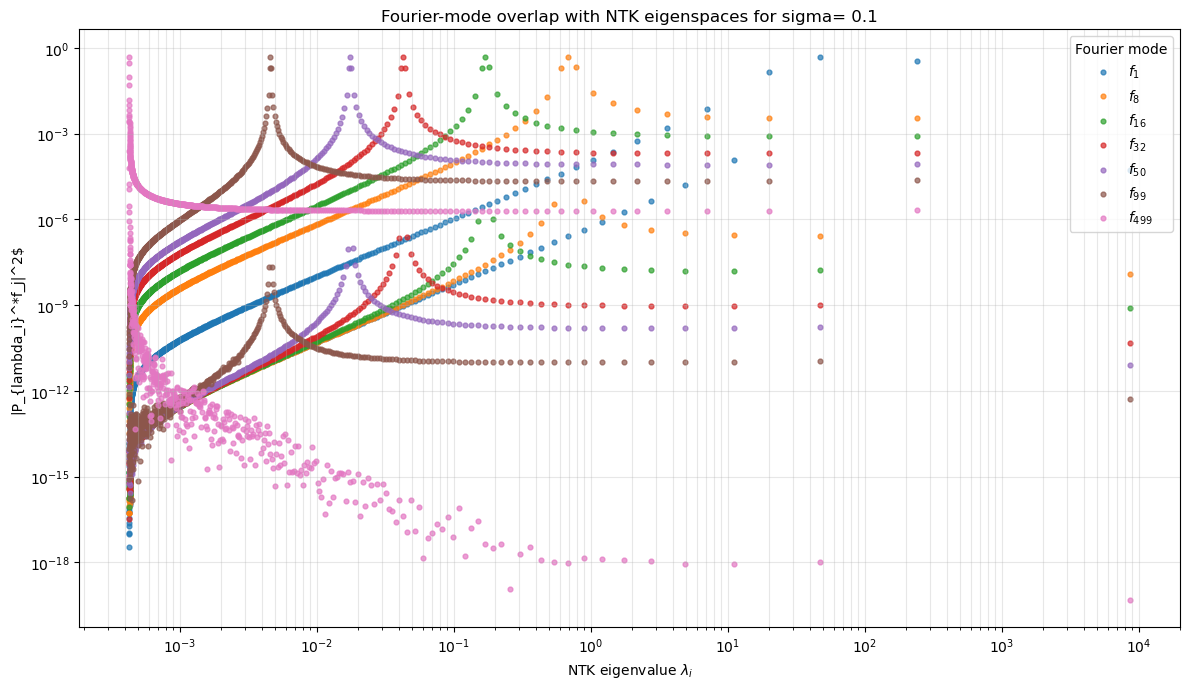

1

sigma = 1
smallest eigenvalue = 4.703184735972e-03
largest eigenvalue  = 6.477173330508e+03
within tol

sigma = 1
smallest eigenvalue = 4.703184735972e-03
largest eigenvalue  = 6.477173330508e+03
within tol

sigma = 1
smallest eigenvalue = 4.703184735972e-03
largest eigenvalue  = 6.477173330508e+03
within tol

sigma = 1
smallest eigenvalue = 4.703184735972e-03
largest eigenvalue  = 6.477173330508e+03
within tol

sigma = 1
smallest eigenvalue = 4.703184735972e-03
largest eigenvalue  = 6.477173330508e+03
within tol

sigma = 1
smallest eigenvalue = 4.703184735972e-03
largest eigenvalue  = 6.477173330508e+03
within tol

sigma = 1
smallest eigenvalue = 4.703184735972e-03
largest eigenvalue  = 6.477173330508e+03
within tol


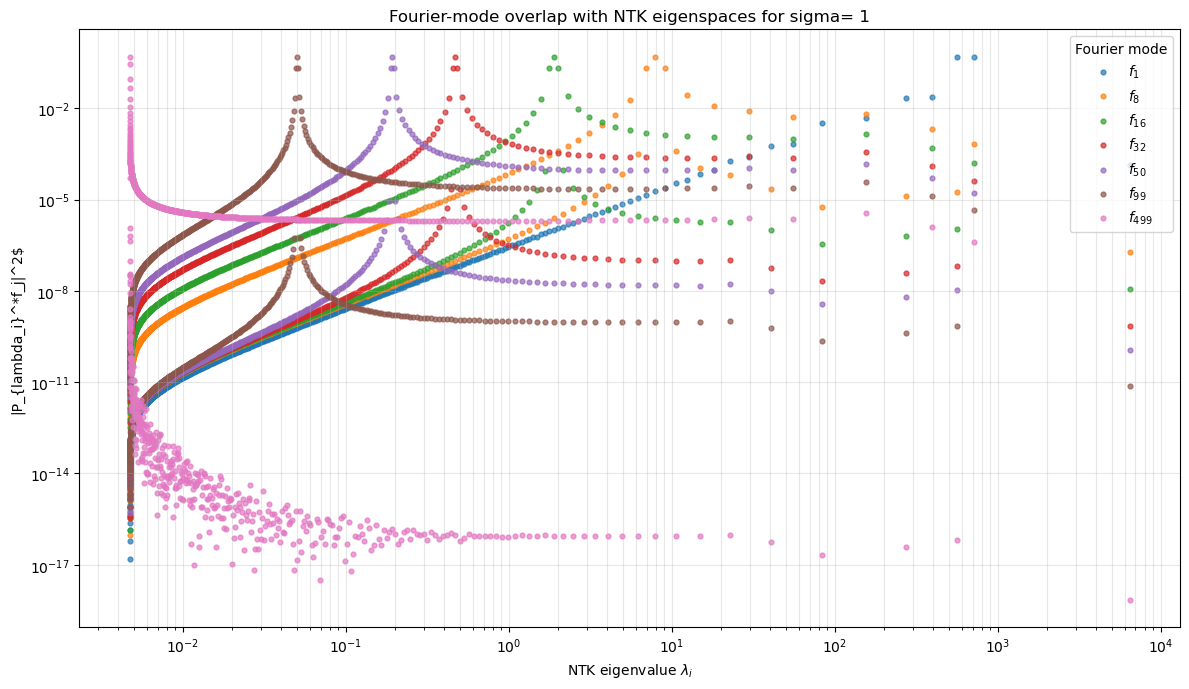

2

sigma = 5
smallest eigenvalue = 1.970972910311e-02
largest eigenvalue  = 5.698743340120e+03
within tol

sigma = 5
smallest eigenvalue = 1.970972910311e-02
largest eigenvalue  = 5.698743340120e+03
within tol

sigma = 5
smallest eigenvalue = 1.970972910311e-02
largest eigenvalue  = 5.698743340120e+03
within tol

sigma = 5
smallest eigenvalue = 1.970972910311e-02
largest eigenvalue  = 5.698743340120e+03
within tol

sigma = 5
smallest eigenvalue = 1.970972910311e-02
largest eigenvalue  = 5.698743340120e+03
within tol

sigma = 5
smallest eigenvalue = 1.970972910311e-02
largest eigenvalue  = 5.698743340120e+03
within tol

sigma = 5
smallest eigenvalue = 1.970972910311e-02
largest eigenvalue  = 5.698743340120e+03
within tol


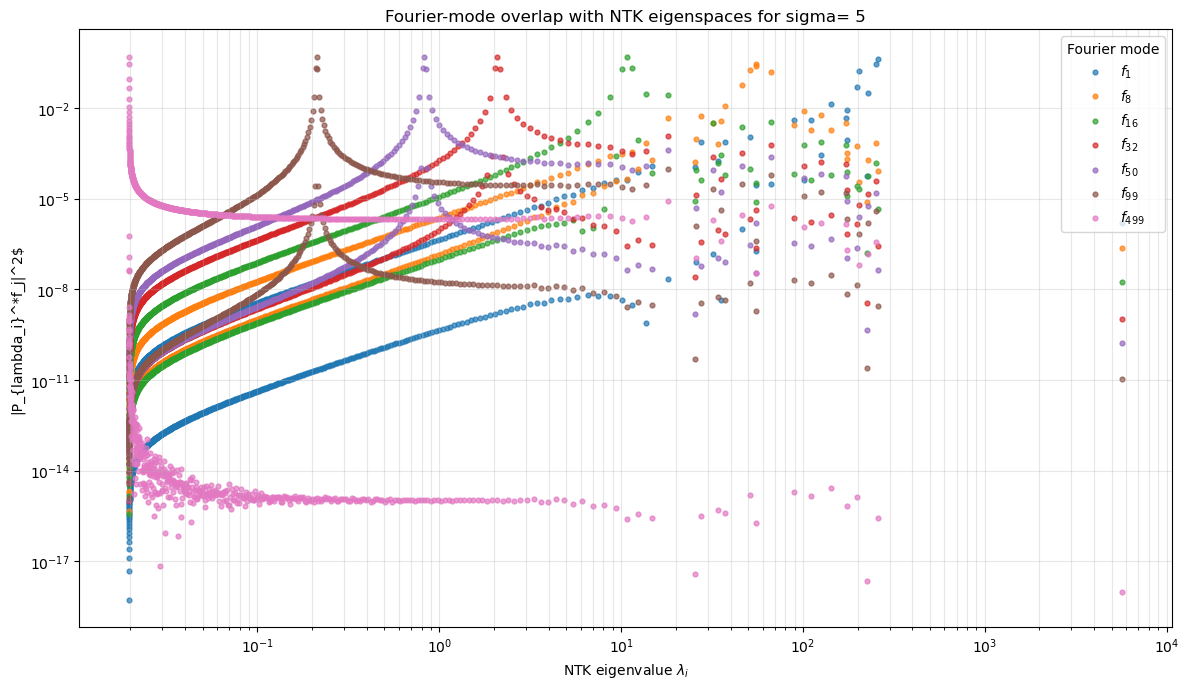

3

sigma = 10
smallest eigenvalue = 4.280003357566e-02
largest eigenvalue  = 5.657196194558e+03
within tol

sigma = 10
smallest eigenvalue = 4.280003357566e-02
largest eigenvalue  = 5.657196194558e+03
within tol

sigma = 10
smallest eigenvalue = 4.280003357566e-02
largest eigenvalue  = 5.657196194558e+03
within tol

sigma = 10
smallest eigenvalue = 4.280003357566e-02
largest eigenvalue  = 5.657196194558e+03
within tol

sigma = 10
smallest eigenvalue = 4.280003357566e-02
largest eigenvalue  = 5.657196194558e+03
within tol

sigma = 10
smallest eigenvalue = 4.280003357566e-02
largest eigenvalue  = 5.657196194558e+03
within tol

sigma = 10
smallest eigenvalue = 4.280003357566e-02
largest eigenvalue  = 5.657196194558e+03
within tol


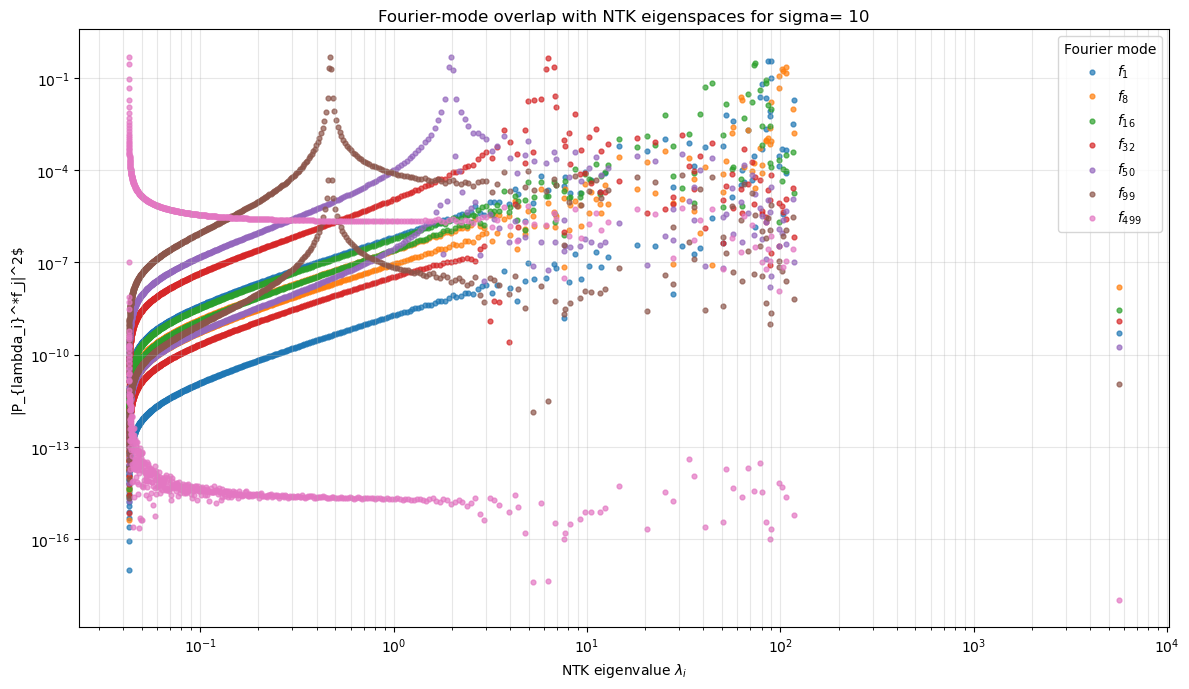

4

sigma = 15
smallest eigenvalue = 6.263422424136e-02
largest eigenvalue  = 5.652780636737e+03
within tol

sigma = 15
smallest eigenvalue = 6.263422424136e-02
largest eigenvalue  = 5.652780636737e+03
within tol

sigma = 15
smallest eigenvalue = 6.263422424136e-02
largest eigenvalue  = 5.652780636737e+03
within tol

sigma = 15
smallest eigenvalue = 6.263422424136e-02
largest eigenvalue  = 5.652780636737e+03
within tol

sigma = 15
smallest eigenvalue = 6.263422424136e-02
largest eigenvalue  = 5.652780636737e+03
within tol

sigma = 15
smallest eigenvalue = 6.263422424136e-02
largest eigenvalue  = 5.652780636737e+03
within tol

sigma = 15
smallest eigenvalue = 6.263422424136e-02
largest eigenvalue  = 5.652780636737e+03
within tol


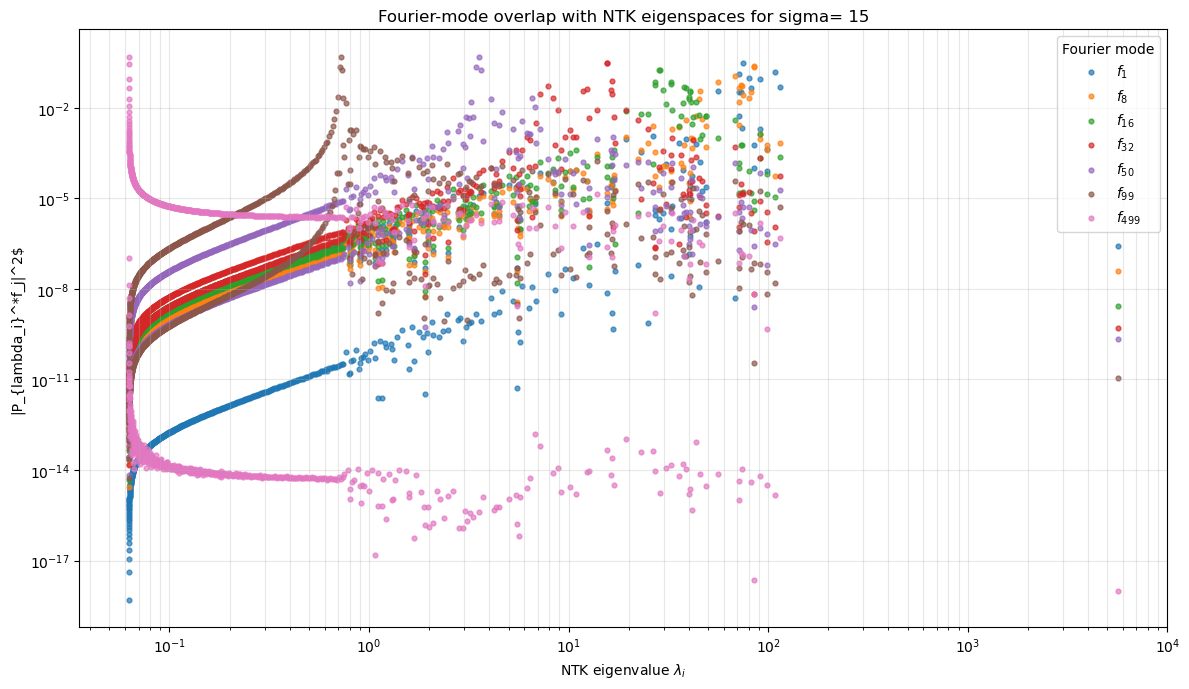

5

sigma = 20
smallest eigenvalue = 8.097160675794e-02
largest eigenvalue  = 5.610212182665e+03
within tol

sigma = 20
smallest eigenvalue = 8.097160675794e-02
largest eigenvalue  = 5.610212182665e+03
within tol

sigma = 20
smallest eigenvalue = 8.097160675794e-02
largest eigenvalue  = 5.610212182665e+03
within tol

sigma = 20
smallest eigenvalue = 8.097160675794e-02
largest eigenvalue  = 5.610212182665e+03
within tol

sigma = 20
smallest eigenvalue = 8.097160675794e-02
largest eigenvalue  = 5.610212182665e+03
within tol

sigma = 20
smallest eigenvalue = 8.097160675794e-02
largest eigenvalue  = 5.610212182665e+03
within tol

sigma = 20
smallest eigenvalue = 8.097160675794e-02
largest eigenvalue  = 5.610212182665e+03
within tol


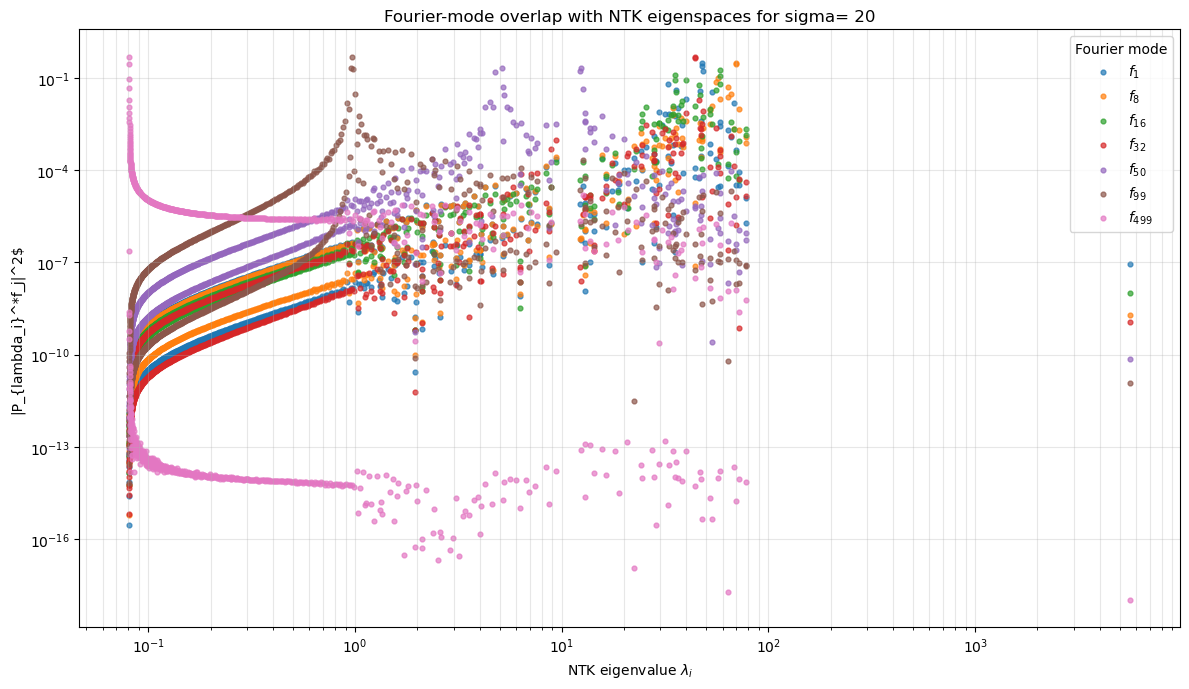

6

sigma = 25
smallest eigenvalue = 1.056940784539e-01
largest eigenvalue  = 5.590573429726e+03
within tol

sigma = 25
smallest eigenvalue = 1.056940784539e-01
largest eigenvalue  = 5.590573429726e+03
within tol

sigma = 25
smallest eigenvalue = 1.056940784539e-01
largest eigenvalue  = 5.590573429726e+03
within tol

sigma = 25
smallest eigenvalue = 1.056940784539e-01
largest eigenvalue  = 5.590573429726e+03
within tol

sigma = 25
smallest eigenvalue = 1.056940784539e-01
largest eigenvalue  = 5.590573429726e+03
within tol

sigma = 25
smallest eigenvalue = 1.056940784539e-01
largest eigenvalue  = 5.590573429726e+03
within tol

sigma = 25
smallest eigenvalue = 1.056940784539e-01
largest eigenvalue  = 5.590573429726e+03
within tol


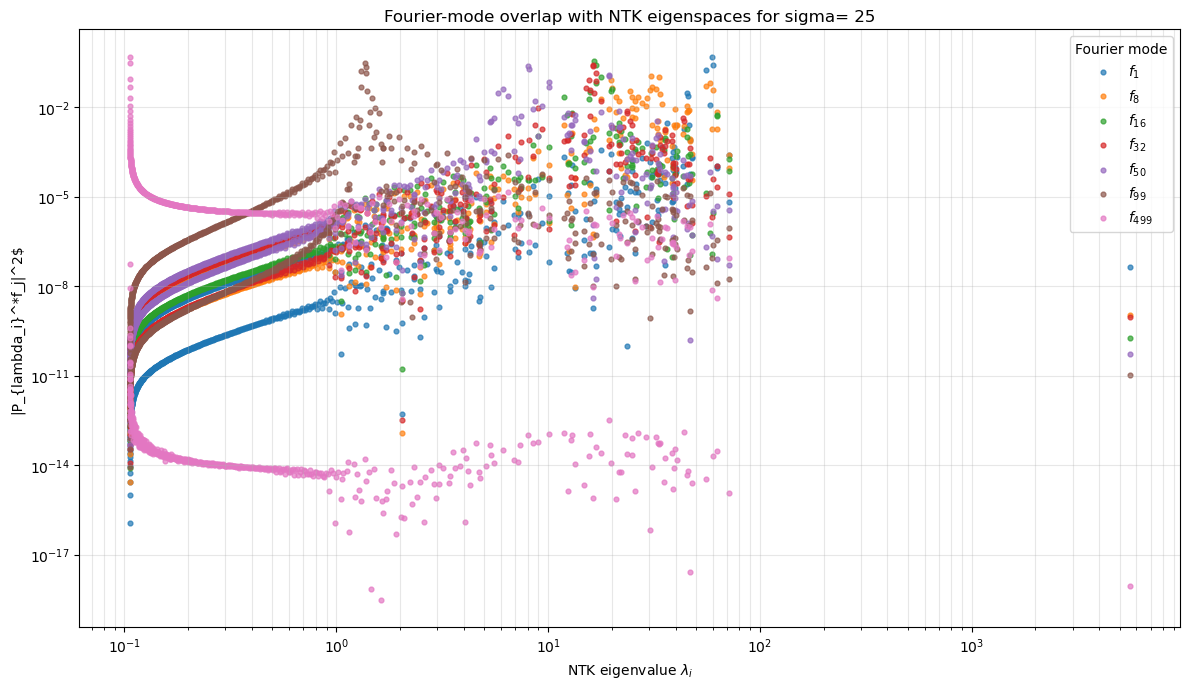

7

sigma = 30
smallest eigenvalue = 1.151034648992e-01
largest eigenvalue  = 5.587263649196e+03
within tol

sigma = 30
smallest eigenvalue = 1.151034648992e-01
largest eigenvalue  = 5.587263649196e+03
within tol

sigma = 30
smallest eigenvalue = 1.151034648992e-01
largest eigenvalue  = 5.587263649196e+03
within tol

sigma = 30
smallest eigenvalue = 1.151034648992e-01
largest eigenvalue  = 5.587263649196e+03
within tol

sigma = 30
smallest eigenvalue = 1.151034648992e-01
largest eigenvalue  = 5.587263649196e+03
within tol

sigma = 30
smallest eigenvalue = 1.151034648992e-01
largest eigenvalue  = 5.587263649196e+03
within tol

sigma = 30
smallest eigenvalue = 1.151034648992e-01
largest eigenvalue  = 5.587263649196e+03
within tol


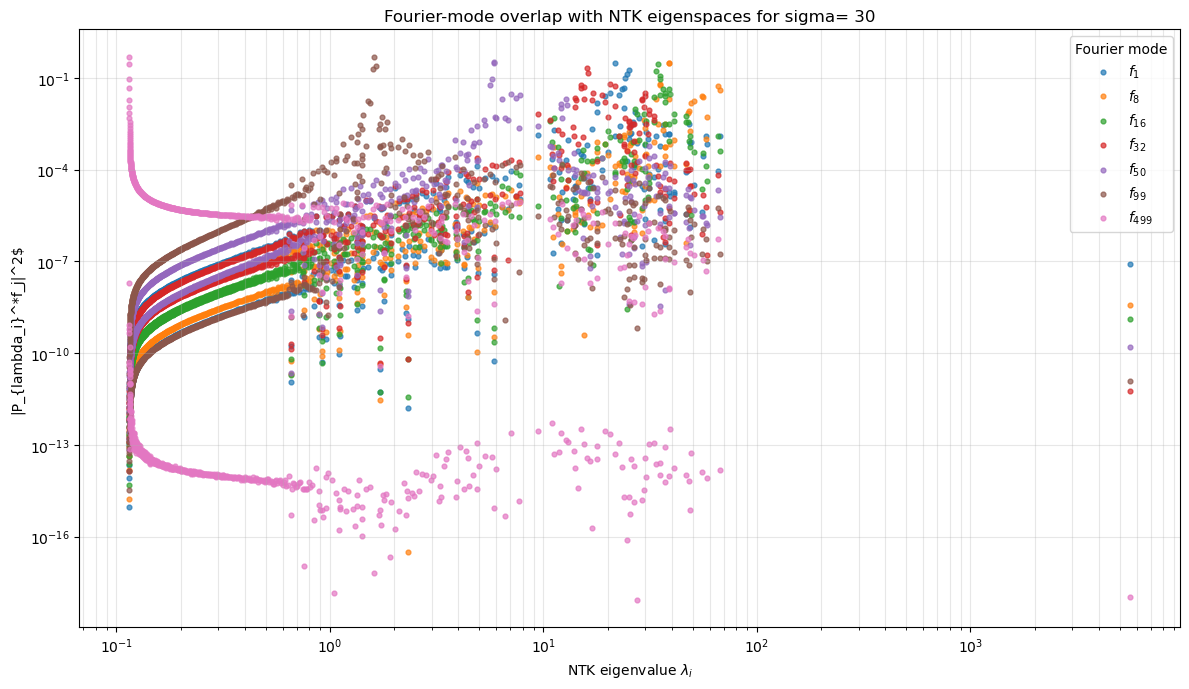

8

sigma = 100
smallest eigenvalue = 4.315093476215e-01
largest eigenvalue  = 5.567945628884e+03
within tol

sigma = 100
smallest eigenvalue = 4.315093476215e-01
largest eigenvalue  = 5.567945628884e+03
within tol

sigma = 100
smallest eigenvalue = 4.315093476215e-01
largest eigenvalue  = 5.567945628884e+03
within tol

sigma = 100
smallest eigenvalue = 4.315093476215e-01
largest eigenvalue  = 5.567945628884e+03
within tol

sigma = 100
smallest eigenvalue = 4.315093476215e-01
largest eigenvalue  = 5.567945628884e+03
within tol

sigma = 100
smallest eigenvalue = 4.315093476215e-01
largest eigenvalue  = 5.567945628884e+03
within tol

sigma = 100
smallest eigenvalue = 4.315093476215e-01
largest eigenvalue  = 5.567945628884e+03
within tol


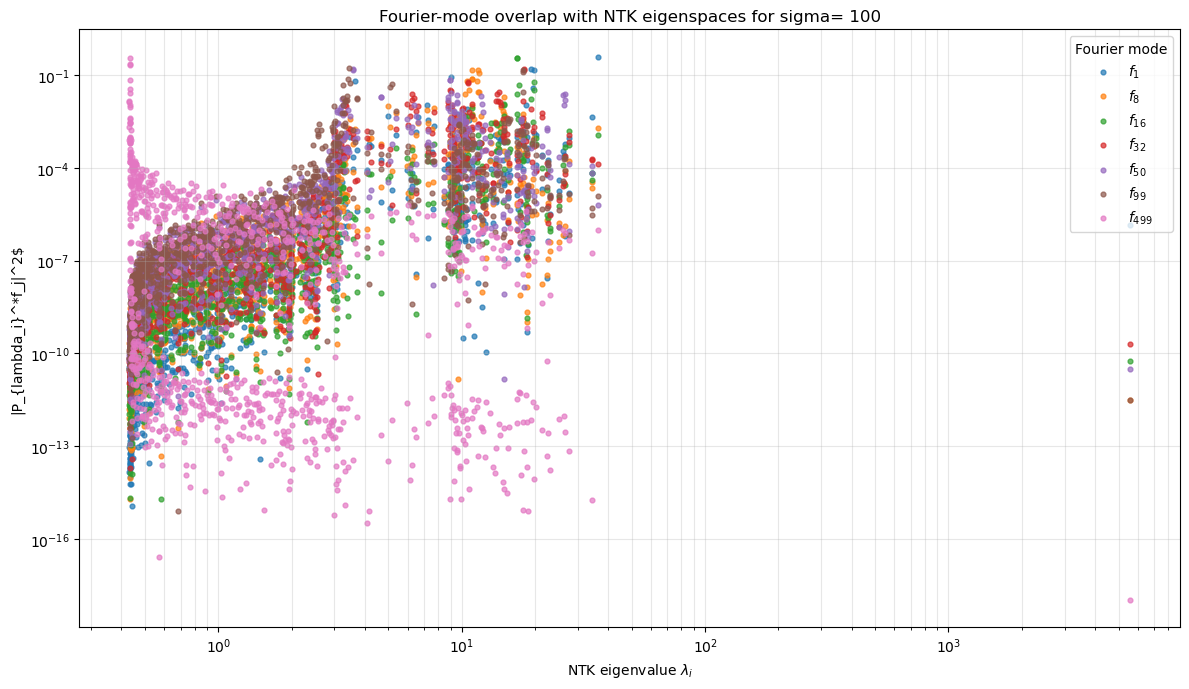

9

sigma = 200
smallest eigenvalue = 9.764234057563e-01
largest eigenvalue  = 5.573640777838e+03
within tol

sigma = 200
smallest eigenvalue = 9.764234057563e-01
largest eigenvalue  = 5.573640777838e+03
within tol

sigma = 200
smallest eigenvalue = 9.764234057563e-01
largest eigenvalue  = 5.573640777838e+03
within tol

sigma = 200
smallest eigenvalue = 9.764234057563e-01
largest eigenvalue  = 5.573640777838e+03
within tol

sigma = 200
smallest eigenvalue = 9.764234057563e-01
largest eigenvalue  = 5.573640777838e+03
within tol

sigma = 200
smallest eigenvalue = 9.764234057563e-01
largest eigenvalue  = 5.573640777838e+03
within tol

sigma = 200
smallest eigenvalue = 9.764234057563e-01
largest eigenvalue  = 5.573640777838e+03
within tol


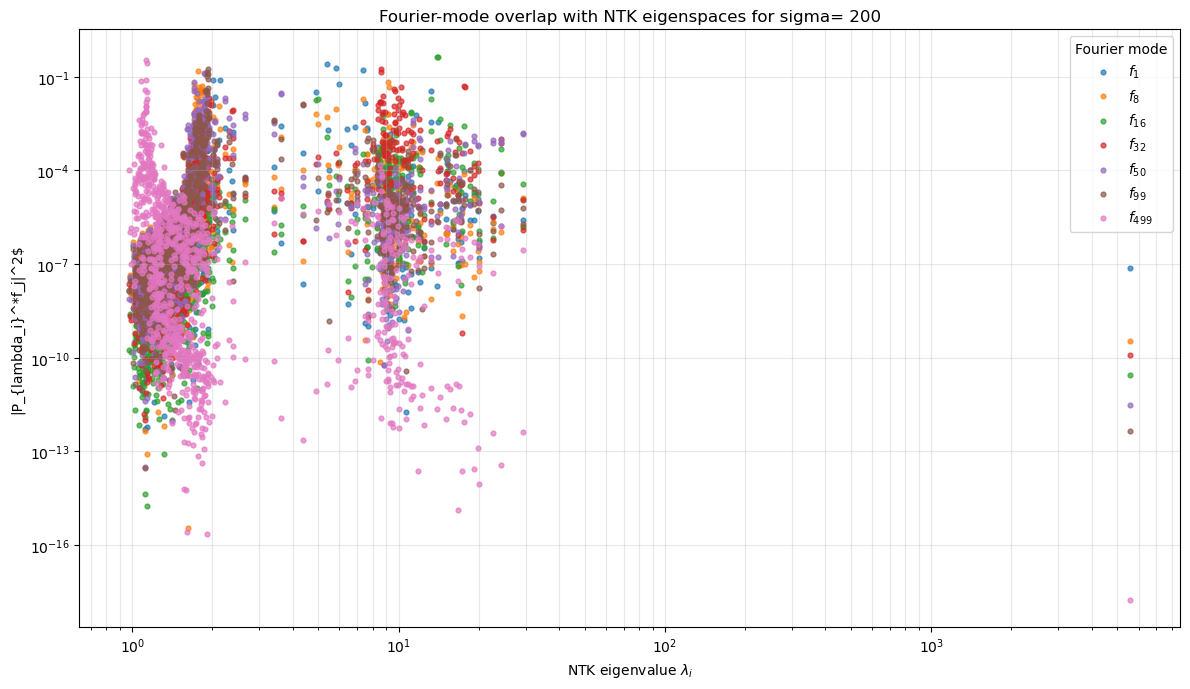

In [29]:
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# Plot w_ij = |q_i^* f_j|^2 against NTK eigenvalue lambda_i
#
# The function normalizes f_j internally, so w_ij is
# independent of epsilon0, eta, and training step.
# =========================================================
#change this guy!
#the largest my laptop allows is 1000, so i cannot cover sigma at 500 or else I'll get overlap / nt needs to be a bit over two thousand min
nt=1000
#change this guy!

master_key = random.PRNGKey(0)
X_train, y_train, X_test, y_test, X_all, y_all = make_data(
    n_total=nt,
    train_every=2,
)

f_max=nt//2 -1
j_values = [1, 8, 16 ,32 ,50,99,f_max]

# Full-grid coordinates and target values
x_full = X_all.reshape(-1)
y_true_plot = y_all.reshape(-1)
#used in the next cell
sigma_vals=[0.1,1,5,10,15,20,25,30,100,200]

N = x_full.shape[0]

vals_r = jnp.arange(N)
    
F = jnp.exp(
        2j
        * jnp.pi
        * x_full[:, None]
        * vals_r[None, :]
    ) / jnp.sqrt(N)

for i, sigma in enumerate(sigma_vals): 
    print(i)
    key_B = random.fold_in(
        master_key,
        i + 100,
    )
    #same key throughout for sigma =5, it was third so index 2 in the list
    B, a = make_fourier_params(
        num_basis=num_basis,
        sigma=sigma,
        key=key_B,
    )
       
    X_train_ff = fourier_features(X_train, B, a)
    X_test_ff = fourier_features(X_test, B, a)
    X_all_ff = fourier_features(X_all, B, a)
    
    #INIT CONDITION NUMBER--> actually this must be X_all to match up later
    #these are different each time now

    #i dont think this is needed?
    params_init_ff = init_mlp_params(
                    key_B,
                    input_dim=X_all_ff.shape[-1],
                    width=1024,
                    depth=2,
                )
    
    K_init_ff, _ = analytic_ntk_matrix_2(X_all_ff)
    #swap to spectral
    
    
    
    fig, ax = plt.subplots(
        figsize=(12, 7)
    )
    
    spec_list = spectral_projectors(K_init_ff)

    k=0
    for k in j_values:
    
        coeff_values = np.asarray(
            spectral_error_bins(
                F=F,
                spec_list=spec_list,
                j=k,
            ),
            dtype=float,
        )
    
        lambda_values = np.asarray(
            [
                eigenvalue
                for eigenvalue, P_lambda in spec_list
            ],
            dtype=float,
        )

        smallest_eigenvalue = np.min(lambda_values)
        largest_eigenvalue = np.max(lambda_values)
        
        print(f"\nsigma = {sigma}")
        print(f"smallest eigenvalue = {smallest_eigenvalue:.12e}")
        print(f"largest eigenvalue  = {largest_eigenvalue:.12e}")
        
        if smallest_eigenvalue > 1e-9*largest_eigenvalue:
            print("within tol")
        else:
            print("not within tol")
    
        # Keep finite, positive eigenvalues and projections whose
        # squared norm is larger than the chosen numerical tolerance.
        valid = (
            np.isfinite(lambda_values)
            & np.isfinite(coeff_values)
            & (lambda_values > 0.0)
        )
    
        lambda_values_valid = lambda_values[valid]
        coeff_values_valid = coeff_values[valid]
    
        ax.scatter(
            lambda_values[valid],
            coeff_values[valid],
            s=12,
            alpha=0.7,
            label=rf"$f_{{{k}}}$",
        )
    
    
    
    ax.set_xscale("log")
    ax.set_yscale("log")
    
    ax.set_xlabel(
        r"NTK eigenvalue $\lambda_i$"
    )
    
    ax.set_ylabel(
        r"|P_{lambda_i}^*f_j|^2$"
    )
    
    ax.set_title(
        "Fourier-mode overlap with NTK eigenspaces for sigma= "+str(sigma)
    )
    
    ax.grid(
        alpha=0.3,
        which="both",
    )
    
    ax.legend(
        title="Fourier mode"
    )
    
    plt.tight_layout()
    plt.show()


sigma =500 will also have say bj= (over 500 maybe typically 1200), this is not displayed in these plots but is probably where the overfit comes from. I.e, these freqs are now associated with eigenvals above one so should be learnt quickly, yet overfitting occurs. Therefore, these not displayed frequencies are probably still quite high in error and overfitting might be interpretted as 'more and more frequencies that are trained quickly, but are still present?'

## NTK Infinite Width vs Sampled Empirical NTK as Width Increases

In [13]:
## helper fucntions

## helper functions for analytic-NTK parameterization

#THESE HAVE NOW BEEN MERGED AND SHOULD BE REMOVED

def init_mlp_params2(
    key,
    input_dim,
    width=4,
    depth=2,
    use_bias=True,
):
    layer_sizes = [input_dim] + [width] * depth + [1]
    keys = random.split(key, len(layer_sizes) - 1)

    params = []

    for key_layer, din, dout in zip(
        keys,
        layer_sizes[:-1],
        layer_sizes[1:],
    ):
        key_W, key_b = random.split(key_layer)

        W = random.normal(
            key_W,
            shape=(din, dout),
            dtype=jnp.float64,
        )

        if use_bias:
            b = random.normal(
                key_b,
                shape=(dout,),
                dtype=jnp.float64,
            )
        else:
            b = jnp.zeros(
                (dout,),
                dtype=jnp.float64,
            )

        params.append((W, b))

    return params


def mlp_apply2(
    params,
    X,
    sigma_w_sq=2.0,
    sigma_b_sq=1,
    use_bias=True,
):
    h = X

    for W, b in params[:-1]:
        fan_in = W.shape[0]

        z = (
            jnp.sqrt(sigma_w_sq / fan_in)
            * (h @ W)
        )

        if use_bias:
            z = z + jnp.sqrt(sigma_b_sq) * b

        h = jax.nn.relu(z)

    W, b = params[-1]
    fan_in = W.shape[0]

    output = (
        jnp.sqrt(sigma_w_sq / fan_in)
        * (h @ W)
    )

    if use_bias:
        output = output + jnp.sqrt(sigma_b_sq) * b

    return output


def scalar_output2(
    params,
    x,
    use_bias=True,
    sigma_w_sq=2.0,
    sigma_b_sq=1,
):
    return mlp_apply2(
        params,
        x[None, :],
        sigma_w_sq=sigma_w_sq,
        sigma_b_sq=sigma_b_sq,
        use_bias=use_bias,
    )[0, 0]


def empirical_ntk_matrix2(
    params,
    X,
    use_bias=True,
    sigma_w_sq=2.0,
    sigma_b_sq=1,
):
    X = X.astype(jnp.float64)
    #argnums just refers to what the differentation is respect to
    def grad_flat2(x):
        grads = jacrev(
            scalar_output2,
            argnums=0,
        )(
            params,
            x,
            use_bias=use_bias,
            sigma_w_sq=sigma_w_sq,
            sigma_b_sq=sigma_b_sq,
        )

        flat_grads, _ = ravel_pytree(grads)

        return flat_grads.astype(jnp.float64)

    J = jax.vmap(grad_flat2)(X)
    K = J @ J.T
    #reduce mem needed
    J = None
    return K, J


## These functions needed to be redefined to work directly with analytic NTK, so the older plot showing empirical NTK, not exactly in direct comparison with expected NTK but showing higher cond num + effective rank is slightly misleading

Basically, the paper's expected NTK scales W values slightly differently. Original code scales them, but when taking derivatives one of the 1/sqrt(m) factors gets absorbed and doesn't 'pass through' layers as it does for analytic NTK.

use_bias is also needed, as the paper for analytic NTK as an exmaple chooses (I think? regardless a choice of this is ok) to have sigma_b=0, so I need a toggle when using the empirical ntks to make 'b=0' so that subsequent derivative terms don't include any b terms.

If I standardise with either set of functions, it messes the other sections' code up. I need to dig deeper into why this is, but at the moment I've just split them into two.


width = 100
relative kernel error = 7.213910e-02
K_hat_w Frobenius norm = 6.387811e+01
K_inf Frobenius norm   = 6.029990e+01

width = 500
relative kernel error = 1.741860e-02
K_hat_w Frobenius norm = 6.070346e+01
K_inf Frobenius norm   = 6.029990e+01

width = 1000
relative kernel error = 8.234863e-03
K_hat_w Frobenius norm = 6.017300e+01
K_inf Frobenius norm   = 6.029990e+01

width = 2000
relative kernel error = 1.136054e-02
K_hat_w Frobenius norm = 6.066923e+01
K_inf Frobenius norm   = 6.029990e+01

width = 4000
relative kernel error = 7.690068e-03
K_hat_w Frobenius norm = 6.054080e+01
K_inf Frobenius norm   = 6.029990e+01

width = 8000
relative kernel error = 2.912884e-03
K_hat_w Frobenius norm = 6.033500e+01
K_inf Frobenius norm   = 6.029990e+01


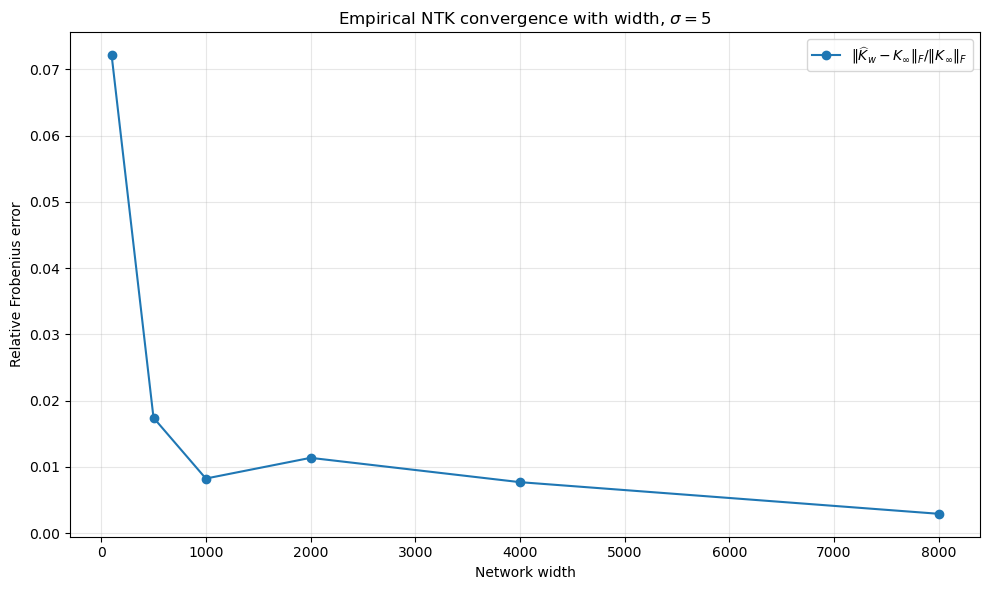

In [16]:
import numpy as np
import matplotlib.pyplot as plt

num_basis = 128
make_data_vals = [100, 500, 1000, 2000, 4000,8000]
sigma = 5

master_key = random.PRNGKey(0)

relative_kernel_errors = []

sample_num = 10


# =========================================================
# Fixed dataset
# =========================================================

X_train_s, y_train_s, X_test_s, y_test_s, X_all_s, y_all_s = make_data(
    n_total=10,
    train_every=2,
)


# =========================================================
# Fixed Fourier feature map
# =========================================================

key_B = random.fold_in(
    master_key,
    100,
)

B_s, a_s = make_fourier_params(
    num_basis=num_basis,
    sigma=sigma,
    key=key_B,
)

X_all_ff_s = fourier_features(
    X_all_s,
    B_s,
    a_s,
)

input_dim = X_all_ff_s.shape[-1]


# =========================================================
# Analytic infinite-width NTK: K_infinity
# =========================================================

K_inf, _ = analytic_ntk_matrix_2(
    X_all_ff_s,
    depth=2,
    sigma_w_sq=2.0,
    sigma_b_sq=1,
)

K_inf = np.asarray(K_inf)

K_inf_norm = np.linalg.norm(
    K_inf,
    ord="fro",
)


# =========================================================
# Relative error for each network width
# =========================================================

for ind, width in enumerate(make_data_vals):
    empirical_ntks = []

    for seed_idx in range(sample_num):
        key_C = random.fold_in(
            master_key,
            1000 + ind * sample_num + seed_idx,
        )

        params_init = init_mlp_params(
            key_C,
            input_dim= input_dim,
            width=width,
            depth=2,
            use_bias=True,
        )

        K_empirical, _ = empirical_ntk_matrix(
            params_init,
            X_all_ff_s,
            use_bias=True,
            sigma_w_sq=2.0,
            sigma_b_sq=1,
        )

        empirical_ntks.append(
            np.asarray(K_empirical)
        )

    empirical_ntks = np.stack(
        empirical_ntks,
        axis=0,
    )

    # Monte Carlo estimate of the expected width-w kernel:
    #
    # K_hat_w = (1 / sample_num) sum_s K_w^(s)
    K_hat_w = np.mean(
        empirical_ntks,
        axis=0,
    )

    # ||K_hat_w - K_inf||_F / ||K_inf||_F
    relative_error = (
        np.linalg.norm(
            K_hat_w - K_inf,
            ord="fro",
        )
        / K_inf_norm
    )

    relative_kernel_errors.append(
        float(relative_error)
    )

    print(f"\nwidth = {width}")
    print(
        "relative kernel error = "
        f"{relative_error:.6e}"
    )
    print(
        "K_hat_w Frobenius norm = "
        f"{np.linalg.norm(K_hat_w, ord='fro'):.6e}"
    )
    print(
        "K_inf Frobenius norm   = "
        f"{K_inf_norm:.6e}"
    )


# =========================================================
# Plot only the requested relative error
# =========================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    make_data_vals,
    relative_kernel_errors,
    marker="o",
    label=(
        r"$\|\widehat{K}_w-K_\infty\|_F"
        r"/\|K_\infty\|_F$"
    ),
)

#plt.xscale("log")
#plt.yscale("log")

plt.xlabel("Network width")
plt.ylabel("Relative Frobenius error")

plt.title(
    rf"Empirical NTK convergence with width, $\sigma={sigma}$"
)

plt.grid(
    alpha=0.3,
    which="both",
)

plt.legend()
plt.tight_layout()
plt.show()

All analysis done on sigma=15
100


KeyboardInterrupt: 

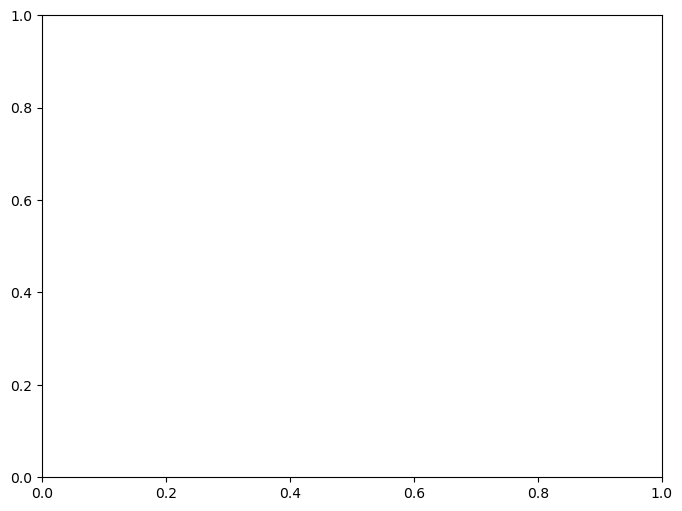

In [15]:
#sigma =15
#widths again 
#F new 
print("All analysis done on sigma=15")

import numpy as np
import matplotlib.pyplot as plt
num_basis=128

# =========================================================
# Plot w_ij = |q_i^* f_j|^2 against NTK eigenvalue lambda_i
#
# The function normalizes f_j internally, so w_ij is
# independent of epsilon0, eta, and training step.
# =========================================================
#change this guy!
#the largest my laptop allows is 1000, so i cannot cover sigma at 500 or else I'll get overlap / nt needs to be a bit over two thousand min
nt=1000
make_data_vals = [100, 500,1000]
sigma=5
sample_num=10
#change this guy!

master_key = random.PRNGKey(0)
X_train_s, y_train_s, X_test_s, y_test_s, X_all_s, y_all_s = make_data(
    n_total=nt,
    train_every=2,
)


key_B = random.fold_in(
    master_key,
    100,
)

B_s, a_s = make_fourier_params(
    num_basis=num_basis,
    sigma=sigma,
    key=key_B,
)

X_all_ff_s = fourier_features(
    X_all_s,
    B_s,
    a_s,
)

input_dim = X_all_ff_s.shape[-1]

f_max=nt//2 -1
j_values = [1, 8, 16 ,32 ,50,99,f_max]

# Full-grid coordinates and target values
x_full = X_all_s.reshape(-1)
y_true_plot = y_all_s.reshape(-1)

N = x_full.shape[0]

vals_r = jnp.arange(N)
    
F = jnp.exp(
        2j
        * jnp.pi
        * x_full[:, None]
        * vals_r[None, :]
    ) / jnp.sqrt(N)

ind=0
for ind, width in enumerate(make_data_vals):
    print(width)
    fig, ax = plt.subplots(figsize=(8, 6))

    empirical_ntks = []

    for seed_idx in range(sample_num):
        key_C = random.fold_in(
            master_key,
            1000 + ind * sample_num + seed_idx,
        )

        params_init = init_mlp_params2(
            key_C,
            input_dim=input_dim,
            width=width,
            depth=2,
            use_bias=False,
        )

        K_empirical, _ = empirical_ntk_matrix2(
            params_init,
            X_all_ff_s,
            use_bias=False,
            sigma_w_sq=2.0,
            sigma_b_sq=1,
        )

        empirical_ntks.append(np.asarray(K_empirical))

    empirical_ntks = np.stack(empirical_ntks, axis=0)
    K_hat_w = np.mean(empirical_ntks, axis=0)

    spec_list = spectral_projectors(K_hat_w)

    for k in j_values:
        coeff_values = np.asarray(
            spectral_error_bins(
                F=F,
                spec_list=spec_list,
                j=k,
            ),
            dtype=float,
        )

        lambda_values = np.asarray(
            [eigenvalue for eigenvalue, _ in spec_list],
            dtype=float,
        )

        valid = (
            np.isfinite(lambda_values)
            & np.isfinite(coeff_values)
            & (lambda_values > 0.0)
            & (coeff_values > 0.0)
        )

        ax.scatter(
            lambda_values[valid],
            coeff_values[valid],
            s=12,
            alpha=0.7,
            label=rf"$f_{{{k}}}$",
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"NTK eigenvalue $\lambda_i$")
    ax.set_ylabel(r"$|P_{\lambda_i}^* f_j|^2$")
    ax.set_title(
        f"Fourier-mode overlap with NTK eigenspaces for width = {width}"
    )
    ax.grid(alpha=0.3, which="both")
    ax.legend(title="Fourier mode")

    fig.tight_layout()
    plt.show()
    plt.close(fig)

In [24]:
import numpy as np
import jax.numpy as jnp

from scipy.optimize import brentq


def expected_ntk_and_sigma_derivative(
    sigma,
    X1,
    X2=None,
    *,
    depth=2,
    sigma_w_sq=2.0,
    sigma_b_sq=1,
    eps=1e-12,
):
    r"""
    Compute the infinite-width, infinite-Fourier-feature NTK

        k_NTK,∞(X1, X2)

    and its derivative with respect to the Fourier scale sigma:

        ∂k_NTK,∞(X1, X2) / ∂sigma.

    Notation
    --------
    Sigma12
        Gaussian-process/NNGP covariance:

            Sigma12[i,j]
                = Sigma^(L)(X1[i], X2[j]).

    k_NTK12
        Infinite-width NTK:

            k_NTK12[i,j]
                = k_NTK,∞^(L)(X1[i], X2[j]).

    dot_Sigma12
        Activation-derivative covariance:

            dot_Sigma^(L+1)(x,x')
                = sigma_w_sq
                  E[ReLU'(U) ReLU'(V)].

        The dot does NOT mean differentiation with respect to the
        Fourier scale.

    *_prime
        Differentiation with respect to the Fourier scale sigma.

    q1, q2
        Diagonal entries of Sigma^(L):

            q1[i] = Sigma^(L)(X1[i], X1[i]),
            q2[j] = Sigma^(L)(X2[j], X2[j]).

    Notes
    -----
    This assumes Fourier amplitudes a_r = 1.

    Pass the original input points X1 and X2. Do not apply the
    finite Fourier-feature map before calling this function.
    """
    X1 = jnp.asarray(
        X1,
        dtype=jnp.float64,
    )

    sigma = jnp.asarray(
        sigma,
        dtype=jnp.float64,
    )

    if X2 is None:
        X2 = X1
    else:
        X2 = jnp.asarray(
            X2,
            dtype=jnp.float64,
        )

    # --------------------------------------------------------
    # Pairwise squared distances:
    #
    # D2[i,j] = ||X1[i] - X2[j]||^2.
    # --------------------------------------------------------

    X1_sq = jnp.sum(
        X1**2,
        axis=1,
        keepdims=True,
    )

    X2_sq = jnp.sum(
        X2**2,
        axis=1,
        keepdims=True,
    ).T

    D2 = (
        X1_sq
        + X2_sq
        - 2.0 * (X1 @ X2.T)
    )

    # --------------------------------------------------------
    # Infinite-Fourier-feature kernel:
    #
    # Q_sigma(x,x')
    #     = exp(
    #         -2 pi^2 sigma^2 ||x-x'||^2
    #       ).
    #
    # Its Fourier-sigma derivative is:
    #
    # Q_sigma'(x,x')
    #     = -4 pi^2 sigma ||x-x'||^2 Q_sigma(x,x').
    # --------------------------------------------------------

    Q_sigma12 = jnp.exp(
        -2.0
        * jnp.pi**2
        * sigma**2
        * D2
    )

    Q_sigma12_prime = (
        -4.0
        * jnp.pi**2
        * sigma
        * D2
        * Q_sigma12
    )

    # --------------------------------------------------------
    # same notation as paper, this term's derivative is calc'd
    #and also passed through 
    #
    # Sigma^(1)_sigma
    #     = (sigma_w_sq / 2) Q_sigma + sigma_b_sq.
    # --------------------------------------------------------

    input_scale = 0.5 * sigma_w_sq

    Sigma12 = (
        input_scale * Q_sigma12
        + sigma_b_sq
    )

    Sigma12_prime = (
        input_scale * Q_sigma12_prime
    )

    # --------------------------------------------------------
    # Initial diagonal GP covariances:
    #
    # q1[i] = Sigma^(1)(X1[i], X1[i]),
    # q2[j] = Sigma^(1)(X2[j], X2[j]).
    #
    # Since Q_sigma(x,x) = 1:
    #
    # q1[i] = q2[j]
    #       = sigma_w_sq / 2 + sigma_b_sq.
    #
    # These are just parts of sigma matrix, but swapping x,x'
    # --------------------------------------------------------

    q1 = jnp.full(
        (X1.shape[0],),
        input_scale + sigma_b_sq,
        dtype=X1.dtype,
    )

    q2 = jnp.full(
        (X2.shape[0],),
        input_scale + sigma_b_sq,
        dtype=X2.dtype,
    )

    # --------------------------------------------------------
    # NTK base case:
    #
    # k_NTK,∞^(1) = Sigma^(1).
    # --------------------------------------------------------

    k_NTK12 = Sigma12
    k_NTK12_prime = Sigma12_prime
    #go through iterations as per paper to get final output which
    #is just derivative of expected ntk
    for _ in range(depth):

        # ----------------------------------------------------
        # Joint-Gaussian covariance parameters:
        #
        # (U,V) ~ N(
        #     0,
        #     [[q1, Sigma12],
        #      [Sigma12, q2]]
        # )
        #
        # rho = Sigma12 / sqrt(q1 q2).
        # ----------------------------------------------------

        sqrt_q1q2 = jnp.sqrt(
            q1[:, None]
            * q2[None, :]
        )

        rho = jnp.clip(
            Sigma12 / sqrt_q1q2,
            -1.0,
            1.0,
        )

        # q1 and q2 do not depend on Fourier sigma, so just const 
        rho_prime = (
            Sigma12_prime
            / sqrt_q1q2
        )

        theta = jnp.arccos(rho)

        one_minus_rho_sq = jnp.maximum(
            1.0 - rho**2,
            0.0,
        )

        sqrt_one_minus_rho_sq = jnp.sqrt(
            one_minus_rho_sq
        )

        # ----------------------------------------------------
        # ReLU arc-cosine functions. These are defined in a paper, but not in my diss so far
        #
        # kappa_1(rho)
        #   = [
        #       sqrt(1-rho^2)
        #       + rho(pi-arccos(rho))
        #     ] / (2pi)
        #
        # kappa_0(rho)
        #   = [
        #       pi-arccos(rho)
        #     ] / (2pi)
        #
        # d kappa_1 / d rho = kappa_0.
        #
        # d kappa_0 / d rho
        #   = 1 / [
        #       2pi sqrt(1-rho^2)
        #     ].
        # ----------------------------------------------------

        kappa_1 = (
            sqrt_one_minus_rho_sq
            + rho * (jnp.pi - theta)
        ) / (2.0 * jnp.pi)

        kappa_0 = (
            jnp.pi - theta
        ) / (2.0 * jnp.pi)

        # ----------------------------------------------------
        # ReLU covariance expectation, rewritten in terms of new variables
        #
        # E[ReLU(U) ReLU(V)]
        #     = sqrt(q1 q2) kappa_1(rho).
        # ----------------------------------------------------

        relu_covariance = (
            sqrt_q1q2
            * kappa_1
        )

        # Since sqrt(q1 q2) does not depend on Fourier sigma:
        #
        # d/dsigma E[ReLU(U)ReLU(V)]
        #     = sqrt(q1 q2)
        #       kappa_0(rho)
        #       rho_prime.
        relu_covariance_prime = (
            sqrt_q1q2
            * kappa_0
            * rho_prime
        )

        # ----------------------------------------------------
        # ReLU derivative expectation:
        #
        # E[ReLU'(U) ReLU'(V)]
        #     = kappa_0(rho).
        # ----------------------------------------------------

        relu_derivative_covariance = kappa_0

        denominator = jnp.sqrt(
            jnp.maximum(
                one_minus_rho_sq,
                eps,
            )
        )

        relu_derivative_covariance_prime_raw = (
            rho_prime
            / (
                2.0
                * jnp.pi
                * denominator
            )
        )

        # At rho = ±1, the analytic expression contains a
        # square-root singularity. For identical inputs,
        # rho = 1 and rho_prime = 0, so the required derivative
        # is assigned zero.
        relu_derivative_covariance_prime = jnp.where(
            one_minus_rho_sq > eps,
            relu_derivative_covariance_prime_raw,
            0.0,
        )

        # ----------------------------------------------------
        # GP/NNGP covariance recursion:
        #
        # Sigma^(L+1)
        #   = sigma_w_sq E[ReLU(U)ReLU(V)]
        #     + sigma_b_sq.
        # ----------------------------------------------------

        Sigma12_next = (
            sigma_w_sq
            * relu_covariance
            + sigma_b_sq
        )

        Sigma12_next_prime = (
            sigma_w_sq
            * relu_covariance_prime
        )

        # ----------------------------------------------------
        # also need to compute sigma dot
        #
        # dot_Sigma^(L+1)
        #   = sigma_w_sq
        #     E[ReLU'(U)ReLU'(V)].
        # ----------------------------------------------------

        dot_Sigma12_next = (
            sigma_w_sq
            * relu_derivative_covariance
        )

        dot_Sigma12_next_prime = (
            sigma_w_sq
            * relu_derivative_covariance_prime
        )

        # ----------------------------------------------------
        # NTK recursion:
        #
        # k_NTK,∞^(L+1)
        #   = k_NTK,∞^(L) dot_Sigma^(L+1)
        #     + Sigma^(L+1).
       # as per paper
        # ----------------------------------------------------

        k_NTK12_next = (
            k_NTK12
            * dot_Sigma12_next
            + Sigma12_next
        )

        # ----------------------------------------------------
        # Fourier-sigma derivative of the NTK recursion:
        #
        # (k_NTK,∞^(L+1))'
        #   = (k_NTK,∞^(L))' dot_Sigma^(L+1)
        #     + k_NTK,∞^(L) (dot_Sigma^(L+1))'
        #     + (Sigma^(L+1))'.
        #using chain rule
        # ----------------------------------------------------

        k_NTK12_next_prime = (
            k_NTK12_prime
            * dot_Sigma12_next
            + k_NTK12
            * dot_Sigma12_next_prime
            + Sigma12_next_prime
        )

        # ----------------------------------------------------
        # sub next qi values
        # ----------------------------------------------------

        q1_next = (
            0.5
            * sigma_w_sq
            * q1
            + sigma_b_sq
        )

        q2_next = (
            0.5
            * sigma_w_sq
            * q2
            + sigma_b_sq
        )

        # Advance from layer L to layer L+1.
        Sigma12 = Sigma12_next
        Sigma12_prime = Sigma12_next_prime

        k_NTK12 = k_NTK12_next
        k_NTK12_prime = k_NTK12_next_prime

        q1 = q1_next
        q2 = q2_next

    return k_NTK12, k_NTK12_prime


def kernel_loss_and_sigma_derivative(
    sigma,
    X_train,
    y_train,
    X_eval,
    y_eval,
    *,
    ridge=1e-6,
    depth=2,
    sigma_w_sq=2.0,
    sigma_b_sq=1,
):
    r"""
    Compute the kernel-regression evaluation loss L(sigma)
    and its derivative dL/dsigma.

    Parameters
    ----------
    sigma : scalar
        Fourier-feature distribution scale.

    X_train :
        Training inputs before Fourier encoding. (dont need this in limit, CLT takes care of it)

    y_train :
        Training targets.

    X_eval :
        Validation or test inputs before Fourier encoding. (use for opt alg, test data now verifies)

    y_eval :  (use for opt alg, test data now verifies)
        Validation or test targets.

    ridge : float
        Kernel-ridge regularization parameter lambda. (raise eigenvals up by this amount)

    Returns
    -------
    loss : scalar
        Mean squared evaluation error L(sigma).

    loss_prime : scalar
        Fourier-scale derivative dL/dsigma.
    """

    #converts everything to jnp array just in case
    X_train = jnp.asarray(
        X_train,
        dtype=jnp.float64,
    )

    X_eval = jnp.asarray(
        X_eval,
        dtype=jnp.float64,
    )

    y_train = jnp.asarray(
        y_train,
        dtype=jnp.float64,
    ).reshape(-1)

    y_eval = jnp.asarray(
        y_eval,
        dtype=jnp.float64,
    ).reshape(-1)

    sigma = jnp.asarray(
        sigma,
        dtype=jnp.float64,
    )
    #define C and K, both varients of expected NTK matrix depending on data
    # --------------------------------------------------------
    # Training-training NTK matrix:
    #
    # K_NTK_train_sigma[i,j]
    #   = k_NTK,∞,sigma(
    #       X_train[i],
    #       X_train[j]
    #     ).
    # --------------------------------------------------------

    (
        K_NTK_train_sigma,
        K_NTK_train_sigma_prime,
    ) = expected_ntk_and_sigma_derivative(
        sigma,
        X_train,
        depth=depth,
        sigma_w_sq=sigma_w_sq,
        sigma_b_sq=sigma_b_sq,
    )

    # --------------------------------------------------------
    # Evaluation-training NTK matrix:
    #
    # K_NTK_eval_train_sigma[i,j]
    #   = k_NTK,∞,sigma(
    #       X_eval[i],
    #       X_train[j]
    #     ).
    # --------------------------------------------------------

    (
        K_NTK_eval_train_sigma,
        K_NTK_eval_train_sigma_prime,
    ) = expected_ntk_and_sigma_derivative(
        sigma,
        X_eval,
        X_train,
        depth=depth,
        sigma_w_sq=sigma_w_sq,
        sigma_b_sq=sigma_b_sq,
    )

    n_train = X_train.shape[0]

    # --------------------------------------------------------
    # term defined in latex
    #
    # S_sigma
    #   = K_NTK_train_sigma + lambda I.
    # --------------------------------------------------------

    S_sigma = (
        K_NTK_train_sigma
        + ridge
        * jnp.eye(
            n_train,
            dtype=K_NTK_train_sigma.dtype,
        )
    )

    # --------------------------------------------------------
    # Kernel-regression coefficients vector:
    #
    # alpha_sigma
    #   = S_sigma^{-1} y_train.
    #
    # Use lin solve, just kernel regression
    # --------------------------------------------------------

    alpha_sigma = jnp.linalg.solve(
        S_sigma,
        y_train,
    )

    # --------------------------------------------------------
    # Derivative of the coefficients:
    #
    # alpha_sigma'
    #   = -S_sigma^{-1}
    #       K_NTK_train_sigma'
    #       alpha_sigma.
    # --------------------------------------------------------

    alpha_sigma_prime = -jnp.linalg.solve(
        S_sigma,
        K_NTK_train_sigma_prime
        @ alpha_sigma,
    )

    # --------------------------------------------------------
    # Evaluation predictions:
    #
    # y_hat_sigma
    #   = K_NTK_eval_train_sigma alpha_sigma.
    # --------------------------------------------------------

    y_hat_sigma = (
        K_NTK_eval_train_sigma
        @ alpha_sigma
    )

    # --------------------------------------------------------
    # Prediction derivative using chain rule
    #
    # y_hat_sigma'
    #   = K_NTK_eval_train_sigma' alpha_sigma
    #     + K_NTK_eval_train_sigma alpha_sigma'.
    # --------------------------------------------------------

    y_hat_sigma_prime = (
        K_NTK_eval_train_sigma_prime
        @ alpha_sigma
        + K_NTK_eval_train_sigma
        @ alpha_sigma_prime
    )

    residual_sigma = (
        y_hat_sigma
        - y_eval
    )
    # L(sigma)
    #   = (1/n_eval)
    #     ||y_hat_sigma-y_eval||^2.
    loss = jnp.mean(
        residual_sigma**2
    )

    # L'(sigma)
    #   = (2/n_eval)
    #     residual_sigma^T
    #     y_hat_sigma'.
    loss_prime = (
        2.0
        / y_eval.shape[0]
        * jnp.dot(
            residual_sigma,
            y_hat_sigma_prime,
        )
    )

    return loss, loss_prime


def find_sigma_minima_brent(
    sigma_min,
    sigma_max,
    X_train,
    y_train,
    X_val,
    y_val,
    *,
    ridge=1e-6,
    depth=2,
    sigma_w_sq=2.0,
    sigma_b_sq=1.0,
    num_grid=300,
    log_grid=True,
    derivative_tol=1e-8,
    root_tol=1e-7,
    xtol=1e-10,
    rtol=1e-10,
    maxiter=100,
):
    r"""
    Find constrained minima of the validation loss L(sigma).

    The inputs:
    * sigma min and max are the region to sweep over, might adapt this to be 'if sign change/ strict inc dec after x doubles, define max'
    * Test, train and eval data. Make data has an extra function / a new one since we have another alg to find sigma, want two test datasets now basically
    * ridge shifts the eigenvalues up in expected NTK to ensure it is PD so that kernel regression can have alpha values writtin in terms of inverse
    * depth and other sigmas relate to initial vals of Expected NTK matrix and by default match paper
    * num grid is the number of sigma points to sample for L
    * derivative tol asks if x< something very small so that if any floating point errors, but genuine minimum, will still detect (used for points tested
    outside of brentq
    * same for root_tol is to check if two sigmas are duplicates/ too close to eachother to not be viewed as identical. Not used in brentq, but at the end
    to determine what unqiue sigma vals I have 
    * x tol and r tol are passed to brentq for absolute and relative errors. Used in the bound of the error to deduce if brentq has gotten close enough

    The procedure:

      1. Evaluates L'(sigma) over a grid.
      2. Locates intervals where L'(sigma) changes sign.
      3. Uses Brent's method to solve L'(sigma) = 0.
      4. Classifies each stationary point.
      5. Compares local minima with the boundaries.

      Returns the optimum sigma and also data regarding which intervals where sampled and brentq was applied to.
    """

    def evaluate(sigma):
        """
        Evaluate L(sigma) and L'(sigma), returning Python floats
        for SciPy.
        """
        loss, loss_prime = (
            kernel_loss_and_sigma_derivative(
                sigma,
                X_train,
                y_train,
                X_val,
                y_val,
                ridge=ridge,
                depth=depth,
                sigma_w_sq=sigma_w_sq,
                sigma_b_sq=sigma_b_sq,
            )
        )

        return (
            float(loss),
            float(loss_prime),
        )

    def validation_loss_derivative(sigma):
        """
        This basically just returns the derivative of L, but is needed as a standalone function to work with scipy's Brent method
        """
        _, loss_prime = evaluate(sigma)
        return loss_prime

    # Preliminary grid used only to discover root brackets.
    if log_grid:
        sigma_grid = np.geomspace(
            sigma_min,
            sigma_max,
            num_grid,
        )
    else:
        sigma_grid = np.linspace(
            sigma_min,
            sigma_max,
            num_grid,
        )
    #gives L' at each point on the grid
    loss_prime_grid = np.asarray(
        [
            validation_loss_derivative(sigma)
            for sigma in sigma_grid
        ],
        dtype=float,
    )

    brackets = []
    roots = []

    # Search adjacent grid points for derivative sign changes.
    for i in range(num_grid - 1):
        left = float(
            sigma_grid[i]
        )

        right = float(
            sigma_grid[i + 1]
        )

        derivative_left = float(
            loss_prime_grid[i]
        )

        derivative_right = float(
            loss_prime_grid[i + 1]
        )
        #to check for any invalid derivatives
        if (
            not np.isfinite(derivative_left)
            or not np.isfinite(derivative_right)
        ):
            continue

        # A grid point may itself already approximate a root
        if abs(derivative_left) <= derivative_tol:
            roots.append(left)

        # Brent's method requires a sign-changing bracket.
        if derivative_left * derivative_right < 0.0:
            brackets.append(
                (left, right)
            )
            #Brentq method for each interval which contains a turning point, see latex
            root = brentq(
                validation_loss_derivative,
                left,
                right,
                xtol=xtol,
                rtol=rtol,
                maxiter=maxiter,
            )

            roots.append(
                float(root)
            )

    # Check the final grid point separately, as this could also be a min just on boundary
    if (
        np.isfinite(loss_prime_grid[-1])
        and abs(loss_prime_grid[-1])
        <= derivative_tol
    ):
        roots.append(
            float(sigma_grid[-1])
        )

    # Sort and remove duplicate roots.
    roots = sorted(roots)

    unique_roots = []

    for root in roots:
        if (
            len(unique_roots) == 0
            or abs(root - unique_roots[-1])
            > root_tol
        ):
            unique_roots.append(root)

    stationary_points = []

    for root in unique_roots:
        # Probe immediately to the left and right to classify
        # the stationary point.
        delta = max(
            1e-8,
            1e-5 * max(
                1.0,
                abs(root),
            ),
        )

        left_probe = max(
            sigma_min,
            root - delta,
        )

        right_probe = min(
            sigma_max,
            root + delta,
        )

        derivative_left = (
            validation_loss_derivative(
                left_probe
            )
        )

        derivative_right = (
            validation_loss_derivative(
                right_probe
            )
        )

        if (
            derivative_left < 0.0
            and derivative_right > 0.0
        ):
            point_type = "local_minimum"

        elif (
            derivative_left > 0.0
            and derivative_right < 0.0
        ):
            point_type = "local_maximum"

        else:
            point_type = "unclassified"

        loss, loss_prime = evaluate(root)

        stationary_points.append(
            {
                "sigma": root,
                "loss": loss,
                "loss_prime": loss_prime,
                "type": point_type,
            }
        )

    # The constrained minimum can occur at either boundary.
    boundary_points = []

    for sigma_boundary in (
        sigma_min,
        sigma_max,
    ):
        loss, loss_prime = evaluate(
            sigma_boundary
        )

        boundary_points.append(
            {
                "sigma": float(
                    sigma_boundary
                ),
                "loss": loss,
                "loss_prime": loss_prime,
                "type": "boundary",
            }
        )

    candidates = [
        point
        for point in stationary_points
        if point["type"] == "local_minimum"
    ]

    candidates.extend(
        boundary_points
    )

    best = min(
        candidates,
        key=lambda point: point["loss"],
    )

    return {
        "best": best,
        "brackets": brackets,
        "stationary_points": stationary_points,
        "boundary_points": boundary_points,
        "sigma_grid": sigma_grid,
        "loss_prime_grid": loss_prime_grid,
    }
    
def make_data_val(n_total=100):
    """
    Generate an evenly spaced dataset and split it into:

        50% training
        25% validation
        25% test

    The three subsets remain interleaved across [0, 1).
    """
    X_all = jnp.linspace(
        0.0,
        1.0,
        n_total,
        endpoint=False,
    )[:, None]

    y_all = target_function(X_all)

    idx = jnp.arange(n_total)

    # Indices:
    # train: 0, 2, 4, 6, ...
    # val:   1, 5, 9, 13, ...
    # test:  3, 7, 11, 15, ...
    train_mask = (idx % 2) == 0
    val_mask = (idx % 4) == 1
    test_mask = (idx % 4) == 3

    X_train = X_all[train_mask]
    y_train = y_all[train_mask]

    X_val = X_all[val_mask]
    y_val = y_all[val_mask]

    X_test = X_all[test_mask]
    y_test = y_all[test_mask]

    return (
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test,
        X_all,
        y_all,
    )




In [32]:
#MUST BE SET TO THE SAME AS SECTION 1 IF WANT TO COMPARE WITH SECTION 1
X_train,y_train,X_val,y_val,X_test,y_test,X_all,y_all=make_data_val(100)

results = find_sigma_minima_brent(
    sigma_min=1e-3,
    sigma_max=500.0,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    ridge=1e-6,
    depth=2,
    num_grid=300,
    log_grid=True,
)

print("Best sigma:", results["best"]["sigma"])
print("Validation loss:", results["best"]["loss"])
print("Detected brackets:", results["brackets"])

for point in results["stationary_points"]:
    print(point)

Best sigma: 4.516044791150008
Validation loss: 0.001775254126886388
Detected brackets: [(4.369977155415935, 4.566035324206117)]
{'sigma': 4.516044791150008, 'loss': 0.001775254126886388, 'loss_prime': 2.0632340909029763e-17, 'type': 'local_minimum'}
{'sigma': 94.33789709582787, 'loss': 0.5312926405935438, 'loss_prime': 9.428213641625597e-09, 'type': 'unclassified'}
{'sigma': 98.57034836372569, 'loss': 0.5312926608570225, 'loss_prime': 1.9658753216349147e-09, 'type': 'unclassified'}
{'sigma': 102.99268772841788, 'loss': 0.5312926650393007, 'loss_prime': 3.535647007834745e-10, 'type': 'unclassified'}
{'sigma': 107.61343448215938, 'loss': 0.5312926657815022, 'loss_prime': 5.410994430221122e-11, 'type': 'unclassified'}
{'sigma': 112.44149013358218, 'loss': 0.5312926658932271, 'loss_prime': 6.9430285738913035e-12, 'type': 'unclassified'}
{'sigma': 117.48615555575903, 'loss': 0.5312926659072833, 'loss_prime': 7.349585832966237e-13, 'type': 'unclassified'}
{'sigma': 122.75714890361031, 'loss'

## SECTION FOR STABILITY + OBJECTIVE FUNCTION CONVERGENCE

In [25]:
compiled_train_step = jax.jit(
    train_step,
    static_argnames=("use_bias",),
)


from functools import partial


@partial(
    jax.jit,
    static_argnames=("steps", "use_bias"),
)
def compiled_training_loop(
    params,
    X,
    y,
    lr,
    *,
    steps,
    sigma_w_sq,
    sigma_b_sq,
    use_bias,
):
    def body(_, state):
        current_params, _ = state

        return train_step(
            current_params,
            X,
            y,
            lr,
            sigma_w_sq=sigma_w_sq,
            sigma_b_sq=sigma_b_sq,
            use_bias=use_bias,
        )

    initial_loss = mse_loss(
        params,
        X,
        y,
        sigma_w_sq=sigma_w_sq,
        sigma_b_sq=sigma_b_sq,
        use_bias=use_bias,
    )

    return jax.lax.fori_loop(
        0,
        steps,
        body,
        (params, initial_loss),
    )


def train_one_model_hybrid(
    key,
    X_train_ff,
    y_train,
    X_test_ff,
    y_test,
    width=4,
    depth=2,
    steps=20000,
    lr=1e-3,
    verbose=False,
    sigma_w_sq=2.0,
    sigma_b_sq=1,
    use_bias=True,
    perturb=1e-3,
):
    """
    Train one NTK-parameterized model and calculate its sensitivity
    to a small parameter perturbation.
    """

    params = init_mlp_params(
        key,
        input_dim=X_train_ff.shape[-1],
        width=width,
        depth=depth,
        use_bias=use_bias,
    )

    if verbose:
        for step in range(steps):
            params, train_loss = compiled_train_step(
                params,
                X_train_ff,
                y_train,
                lr,
                sigma_w_sq=sigma_w_sq,
                sigma_b_sq=sigma_b_sq,
                use_bias=use_bias,
            )

            if (
                step % 500 == 0
                or step == steps - 1
            ):
                test_loss = mse_loss(
                    params,
                    X_test_ff,
                    y_test,
                    sigma_w_sq=sigma_w_sq,
                    sigma_b_sq=sigma_b_sq,
                    use_bias=use_bias,
                )

                print(
                    f"step {step:5d} | "
                    f"train MSE {float(train_loss):.6e} | "
                    f"test MSE {float(test_loss):.6e}"
                )
    else:
        params, train_loss = compiled_training_loop(
            params,
            X_train_ff,
            y_train,
            lr,
            steps=steps,
            sigma_w_sq=sigma_w_sq,
            sigma_b_sq=sigma_b_sq,
            use_bias=use_bias,
        )

    final_train_mse = float(
        mse_loss(
            params,
            X_train_ff,
            y_train,
            sigma_w_sq=sigma_w_sq,
            sigma_b_sq=sigma_b_sq,
            use_bias=use_bias,
        )
    )

    final_test_mse = float(
        mse_loss(
            params,
            X_test_ff,
            y_test,
            sigma_w_sq=sigma_w_sq,
            sigma_b_sq=sigma_b_sq,
            use_bias=use_bias,
        )
    )

    y_pred_test = mlp_apply(
        params,
        X_test_ff,
        sigma_w_sq=sigma_w_sq,
        sigma_b_sq=sigma_b_sq,
        use_bias=use_bias,
    )

    flat_params, unravel_params = ravel_pytree(params)

    key_perturb = random.fold_in(
        key,
        1_000_000,
    )

    perturb_direction = random.normal(
        key_perturb,
        flat_params.shape,
        dtype=flat_params.dtype,
    )

    perturb_direction = (
        perturb_direction
        / jnp.maximum(
            jnp.linalg.norm(perturb_direction),
            1e-12,
        )
    )

    params_perturbed = unravel_params(
        flat_params
        + perturb * perturb_direction
    )

    y_pred_test_p = mlp_apply(
        params_perturbed,
        X_test_ff,
        sigma_w_sq=sigma_w_sq,
        sigma_b_sq=sigma_b_sq,
        use_bias=use_bias,
    )

    output_change = (
        y_pred_test_p - y_pred_test
    ) / perturb

    stability = float(
        jnp.sqrt(
            jnp.mean(output_change**2)
        )
    )

    return (
        params,
        y_pred_test,
        final_train_mse,
        final_test_mse,
        stability,
    )

width 10
  sample 0: Fourier model starting
  sample 0: Fourier model finished
  sample 0: vanilla model starting
  sample 0: vanilla model finished
  sample 1: Fourier model starting
  sample 1: Fourier model finished
  sample 1: vanilla model starting
  sample 1: vanilla model finished
  sample 2: Fourier model starting
  sample 2: Fourier model finished
  sample 2: vanilla model starting
  sample 2: vanilla model finished
  sample 3: Fourier model starting
  sample 3: Fourier model finished
  sample 3: vanilla model starting
  sample 3: vanilla model finished
  sample 4: Fourier model starting
  sample 4: Fourier model finished
  sample 4: vanilla model starting
  sample 4: vanilla model finished
  sample 5: Fourier model starting
  sample 5: Fourier model finished
  sample 5: vanilla model starting
  sample 5: vanilla model finished
  sample 6: Fourier model starting
  sample 6: Fourier model finished
  sample 6: vanilla model starting
  sample 6: vanilla model finished
  sample 7:

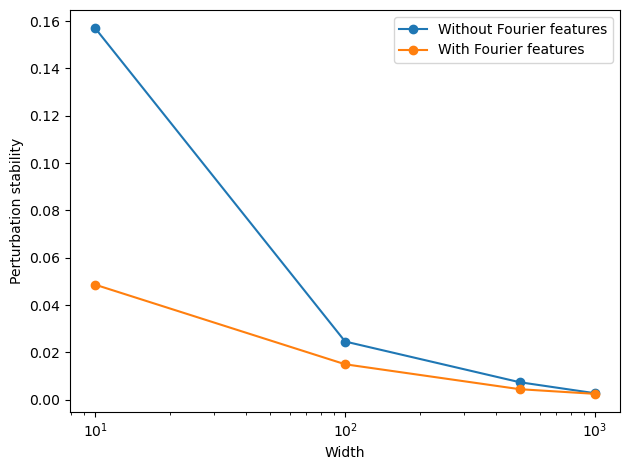

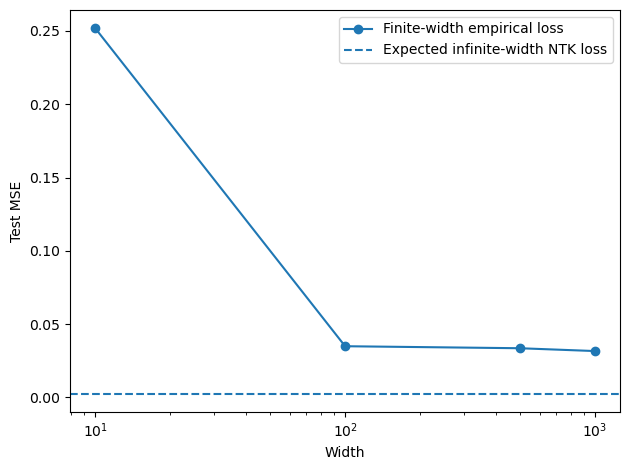

In [26]:

widths = [
    10,
    100,
    500,
    1000
]

input_dim = 128
sample_num = 10
master_key = random.PRNGKey(0)

width_stabs_ff = []
width_stabs_n = []

sigma = 4.5

error_expected = []
error_empirical = []

X_train, y_train, X_test, y_test, X_all, y_all = make_data(
    n_total=100,
    train_every=2,
)


# ============================================================
# EXPECTED INFINITE-WIDTH, INFINITE-FOURIER NTK
# ============================================================

expected_ntk_test = expected_ntk_and_sigma_derivative(
    sigma,
    X_test,
    X_train,
    depth=2,
    sigma_w_sq=2.0,
    sigma_b_sq=1,
)[0]

expected_ntk_train = expected_ntk_and_sigma_derivative(
    sigma,
    X_train,
    depth=2,
    sigma_w_sq=2.0,
    sigma_b_sq=1,
)[0]

ridge = 1e-6

expected_y = (
    expected_ntk_test
    @ jnp.linalg.solve(
        expected_ntk_train
        + ridge
        * jnp.eye(
            expected_ntk_train.shape[0]
        ),
        y_train,
    )
)

error_expected = expected_y - y_test

L_expected = float(
    jnp.mean(
        error_expected**2
    )
)


# ============================================================
# FIXED FOURIER-FEATURE SAMPLE
# ============================================================

key_B = random.fold_in(
    master_key,
    100,
)

B, a = make_fourier_params(
    input_dim,
    sigma,
    key_B,
)

X_train_n = X_train
X_test_n = X_test
X_all_n = X_all

X_train_ff = fourier_features(
    X_train,
    B,
    a,
)

X_test_ff = fourier_features(
    X_test,
    B,
    a,
)

X_all_ff = fourier_features(
    X_all,
    B,
    a,
)


# ============================================================
# WIDTH LOOP
# ============================================================

for width in widths:
    print(
        f"width {width}",
        flush=True,
    )

    sample_v_n = []
    sample_v_ff = []
    error_emp_temp = []

    for sample in range(sample_num):
        key_model = random.fold_in(
            master_key,
            200 + sample,
        )

        print(
            f"  sample {sample}: Fourier model starting",
            flush=True,
        )

        (
            params_ff,
            y_pred_test_ff,
            train_mse_ff,
            test_mse_ff,
            stab_ff,
        ) = train_one_model_hybrid(
            key_model,
            X_train_ff,
            y_train,
            X_test_ff,
            y_test,
            width=width,
            depth=2,
            steps=20000,
            lr=1e-3,
            verbose=False,
            sigma_w_sq=2.0,
            sigma_b_sq=1,
            use_bias=True,
            perturb=1e-3,
        )

        print(
            f"  sample {sample}: Fourier model finished",
            flush=True,
        )

        print(
            f"  sample {sample}: vanilla model starting",
            flush=True,
        )

        (
            params_n,
            y_pred_test_n,
            train_mse_n,
            test_mse_n,
            stab_n,
        ) = train_one_model_hybrid(
            key_model,
            X_train_n,
            y_train,
            X_test_n,
            y_test,
            width=width,
            depth=2,
            steps=20000,
            lr=1e-3,
            verbose=False,
            sigma_w_sq=2.0,
            sigma_b_sq=1,
            use_bias=True,
            perturb=1e-3,
        )

        print(
            f"  sample {sample}: vanilla model finished",
            flush=True,
        )

        error_emp_temp.append(
            float(
                jnp.mean(
                    (
                        y_pred_test_ff
                        - y_test
                    )**2
                )
            )
        )

        sample_v_n.append(stab_n)
        sample_v_ff.append(stab_ff)

    error_empirical.append(
        np.mean(error_emp_temp)
    )

    width_stabs_n.append(
        np.mean(sample_v_n)
    )

    width_stabs_ff.append(
        np.mean(sample_v_ff)
    )


# ============================================================
# PLOT 1: STABILITY
# ============================================================

plt.figure()

plt.plot(
    widths,
    width_stabs_n,
    marker="o",
    label="Without Fourier features",
)

plt.plot(
    widths,
    width_stabs_ff,
    marker="o",
    label="With Fourier features",
)

plt.xscale("log")
plt.xlabel("Width")
plt.ylabel("Perturbation stability")
plt.legend()
plt.tight_layout()


# ============================================================
# PLOT 2: EXPECTED NTK LOSS VS FINITE-NETWORK LOSS
# ============================================================

plt.figure()

plt.plot(
    widths,
    error_empirical,
    marker="o",
    label="Finite-width empirical loss",
)

plt.axhline(
    L_expected,
    linestyle="--",
    label="Expected infinite-width NTK loss",
)

plt.xscale("log")
plt.xlabel("Width")
plt.ylabel("Test MSE")
plt.legend()
plt.tight_layout()

plt.show()


## NEW 2D IMAGE SECTION

In [28]:
from PIL import Image

In [6]:
#some initial functions 
from PIL import Image
import jax.numpy as jnp

def get_X_all(path):

    image = Image.open(path).convert("RGB")

    image_array = jnp.array(
        image,
        dtype=jnp.float64,
    ) / 255.0

    height, width, _ = image_array.shape
    
    x_coordinates = jnp.linspace(0.0, 1.0, width)
    y_coordinates = jnp.linspace(0.0, 1.0, height)

    xx, yy = jnp.meshgrid(
    x_coordinates,
    y_coordinates,
    indexing="xy",
)

    X_all = jnp.stack(
    [
        xx.reshape(-1),
        yy.reshape(-1),
    ],
    axis=1,
)
    return X_all,height,width

def make_target_image(path):
    """
    Load an RGB image and return a target function f(X).

    Input
    -----
    X:
        One coordinate with shape (2,), or
        multiple coordinates with shape (N, 2).

        Coordinates are normalized to [0, 1]:
            X[..., 0] = horizontal x-coordinate
            X[..., 1] = vertical y-coordinate

    Output
    ------
    For X.shape == (2,):
        RGB value with shape (3,).

    For X.shape == (N, 2):
        RGB values with shape (N, 3).
    """

    image = Image.open(path).convert("RGB")

    image_array = jnp.array(
        image,
        dtype=jnp.float64,
    ) / 255.0

    height, width, _ = image_array.shape

    def target_image(X):
        single_point = X.ndim == 1

        if single_point:
            X = X[None, :]

        # Convert normalized coordinates to pixel indices.
        pixel_x = jnp.rint(
            X[:, 0] * (width - 1)
        ).astype(jnp.int32)

        pixel_y = jnp.rint(
            X[:, 1] * (height - 1)
        ).astype(jnp.int32)

        pixel_x = jnp.clip(
            pixel_x,
            0,
            width - 1,
        )

        pixel_y = jnp.clip(
            pixel_y,
            0,
            height - 1,
        )

        rgb = image_array[
            pixel_y,
            pixel_x,
            :,
        ]

        if single_point:
            return rgb[0]

        return rgb

    return target_image


import numpy as np
import matplotlib.pyplot as plt


def recreate_image_from_rgb(
    X,
    rgb_values,
    height,
    width,
    *,
    missing_value=0.0,
    show=True,
    title=None,
):
    """
    Recreate an RGB image from selected pixel coordinates and RGB values.

    X:
        Shape (N, 2), with normalized coordinates in [0, 1]^2.
        X[:, 0] contains horizontal coordinates.
        X[:, 1] contains vertical coordinates.

    rgb_values:
        Shape (N, 3), with RGB values already in [0, 1].

    Returns:
        image_array with shape (height, width, 3)
        selected_mask with shape (height, width)
    """
    X = np.asarray(X)
    rgb_values = np.asarray(rgb_values)

    pixel_x = np.rint(
        X[:, 0] * (width - 1)
    ).astype(int)

    pixel_y = np.rint(
        X[:, 1] * (height - 1)
    ).astype(int)

    pixel_x = np.clip(
        pixel_x,
        0,
        width - 1,
    )

    pixel_y = np.clip(
        pixel_y,
        0,
        height - 1,
    )

    image_array = np.full(
        (height, width, 3),
        missing_value,
        dtype=np.float64,
    )

    selected_mask = np.zeros(
        (height, width),
        dtype=bool,
    )

    image_array[
        pixel_y,
        pixel_x,
        :,
    ] = rgb_values

    selected_mask[
        pixel_y,
        pixel_x,
    ] = True

    if show:
        plt.figure()
        plt.imshow(image_array)
        plt.axis("off")

        if title is not None:
            plt.title(title)

        plt.tight_layout()
        plt.show()

    return image_array, selected_mask

def make_data_image(
    X_all,
    y_all,
    height,
    width,
    train_x_gap=2,
    train_y_gap=2,
):
    # Convert normalized coordinates back to integer pixel positions.
    x_indices = jnp.rint(
        X_all[:, 0] * (width - 1)
    ).astype(jnp.int32)

    y_indices = jnp.rint(
        X_all[:, 1] * (height - 1)
    ).astype(jnp.int32)

    train_mask = (
        (x_indices % train_x_gap == 0)
        & (y_indices % train_y_gap == 0)
    )

    test_mask = ~train_mask

    X_train = X_all[train_mask]
    y_train = y_all[train_mask]

    X_test = X_all[test_mask]
    y_test = y_all[test_mask]


    return (
        X_train,
        y_train,
        X_test,
        y_test,
        X_all,
        y_all
    )


 

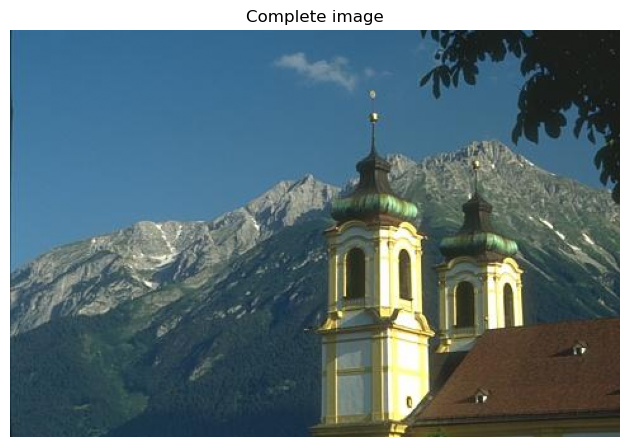

In [7]:

X_all,h,w=get_X_all("126007_rgb.jpg")

tar_i=make_target_image("126007_rgb.jpg")
y_all=tar_i(X_all)

reconstructed_image, selected_mask = recreate_image_from_rgb(
    X_all,
    y_all,
    h,
    w,
    title="Complete image",
)



In [8]:
# ============================================================================
# PIXEL SETUP
# ============================================================================

X_all, h, w = get_X_all(
    "126007_rgb.jpg"
)

target_image = make_target_image(
    "126007_rgb.jpg"
)

y_all = target_image(
    X_all
)


# CHANGED:
# Restored the original six returned arrays.
# There is no X_pred, y_pred, or pred_cond.
(
    X_train,
    y_train,
    X_test,
    y_test,
    X_all,
    y_all,
) = make_data_image(
    X_all=X_all,
    y_all=y_all,
    height=h,
    width=w,
    train_x_gap=2,
    train_y_gap=2,
)


# ============================================================================
# CALCULATE MSE FOR DIFFERENT SIGMA VALUES
#
# Each model is initialized once and continues training:
#
#     0 -> 1,000 -> 2,000 -> ... -> n steps
#
# rather than initializing a new model at every checkpoint.
# ============================================================================

num_basis = 1024
p = 0

master_key = random.PRNGKey(0)

# Number of independent Fourier-frequency samples for each sigma.
n_samples = 5


# ============================================================================
# Training settings shared by every function call
# ============================================================================

width = 128
depth = 2

learning_rate = 1e-3

sigma_w_sq = 2.0
sigma_b_sq = 1.0
use_bias = True


# Train for 1,000 additional steps between recorded checkpoints.
steps_per_checkpoint = 1000
num_checkpoints = 30

checkpoint_steps = [
    steps_per_checkpoint * checkpoint_idx
    for checkpoint_idx in range(
        1,
        num_checkpoints + 1,
    )
]

total_training_steps = checkpoint_steps[-1]


print("Shapes")
print("------")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)
print("X_all:  ", X_all.shape)
print("y_all:  ", y_all.shape)
print()


# ============================================================================
# Sigma values
#
# sigma = 4.6 is the theory-predicted optimum being tested.
# ============================================================================

sigma_values = [
    0.1,
    1,
    4,
    4.6,
    5,
    10,
    20,
    50,
    100,
    500,
]


# ============================================================================
# Results storage
# ============================================================================

results = {
    sigma: {
        "steps": checkpoint_steps,
        "train_ff_samples": [],
        "test_ff_samples": [],
        "y_pred_all_ff_samples": [],
    }
    for sigma in sigma_values
}


# ============================================================================
# Train the vanilla model once
#
# It does not depend on sigma or on the Fourier-frequency sample.
#
# The same parameter object continues training between checkpoints.
# ============================================================================

print("Training vanilla model")

key_model_vanilla = random.fold_in(
    master_key,
    1,
)


params_n = init_mlp_params(
    key_model_vanilla,

    # CHANGED:
    # Raw image coordinates have two columns: [x, y].
    input_dim=X_train.shape[-1],

    # CHANGED:
    # RGB targets have three columns: [R, G, B].
    output_dim=y_train.shape[-1],

    width=width,
    depth=depth,
    use_bias=use_bias,
)


train_mse_n_list = []
test_mse_n_list = []


for checkpoint_idx, total_steps in enumerate(
    checkpoint_steps,
    start=1,
):
    params_n, _ = train_checkpoint(
        params_n,
        X_train,
        y_train,
        number_of_steps=steps_per_checkpoint,
        lr=learning_rate,
    )

    train_mse_n = mse_loss(
        params_n,
        X_train,
        y_train,
        sigma_w_sq=sigma_w_sq,
        sigma_b_sq=sigma_b_sq,
        use_bias=use_bias,
    )

    test_mse_n = mse_loss(
        params_n,
        X_test,
        y_test,
        sigma_w_sq=sigma_w_sq,
        sigma_b_sq=sigma_b_sq,
        use_bias=use_bias,
    )

    train_mse_n_list.append(
        float(train_mse_n)
    )

    test_mse_n_list.append(
        float(test_mse_n)
    )

    print(
        f"Vanilla checkpoint "
        f"{checkpoint_idx:2d}/{num_checkpoints} | "
        f"steps {total_steps:5d} | "
        f"train MSE {float(train_mse_n):.6e} | "
        f"test MSE {float(test_mse_n):.6e}"
    )


# Final vanilla prediction over every image coordinate.
y_pred_all_n_final = mlp_apply(
    params_n,
    X_all,
    sigma_w_sq=sigma_w_sq,
    sigma_b_sq=sigma_b_sq,
    use_bias=use_bias,
)


results["vanilla"] = {
    "steps": checkpoint_steps,
    "train": train_mse_n_list,
    "test": test_mse_n_list,
    "y_pred_all": y_pred_all_n_final,
}


# ============================================================================
# Fourier-feature models
#
# For each Fourier sample and sigma:
#
#   1. Draw one B.
#   2. Initialize one model.
#   3. Continue training that same model through every checkpoint.
# ============================================================================

for sample_idx in range(n_samples):

    print()
    print(
        f"Fourier sample "
        f"{sample_idx + 1}/{n_samples}"
    )

    for sigma_idx, sigma in enumerate(
        sigma_values
    ):
        print(
            f"  sigma={sigma}"
        )

        key_model = random.fold_in(
            master_key,
            1,
        )

        # Fresh Fourier-frequency key for each sample and sigma.
        key_B = random.fold_in(
            master_key,
            (
                100
                + sample_idx * len(sigma_values)
                + sigma_idx
            ),
        )


        B, a = make_fourier_params(
            num_basis=num_basis,
            sigma=sigma,
            key=key_B,

            # CHANGED:
            # Each Fourier frequency now has two components,
            # corresponding to the x and y coordinate columns.
            input_dimension=X_train.shape[-1],
        )


        X_train_ff = fourier_features(
            X_train,
            B,
            a,
        )

        X_test_ff = fourier_features(
            X_test,
            B,
            a,
        )

        X_all_ff = fourier_features(
            X_all,
            B,
            a,
        )


        # Initialize exactly once for this Fourier model.
        params_ff = init_mlp_params(
            key_model,

            # CHANGED:
            # The transformed input dimension is 2 * num_basis.
            input_dim=X_train_ff.shape[-1],

            # CHANGED:
            # The network predicts three RGB values.
            output_dim=y_train.shape[-1],

            width=width,
            depth=depth,
            use_bias=use_bias,
        )


        train_mse_ff_list = []
        test_mse_ff_list = []


        for checkpoint_idx, total_steps in enumerate(
            checkpoint_steps,
            start=1,
        ):
            params_ff, _ = train_checkpoint(
                params_ff,
                X_train_ff,
                y_train,
                number_of_steps=steps_per_checkpoint,
                lr=learning_rate,
            )

            train_mse_ff = mse_loss(
                params_ff,
                X_train_ff,
                y_train,
                sigma_w_sq=sigma_w_sq,
                sigma_b_sq=sigma_b_sq,
                use_bias=use_bias,
            )

            test_mse_ff = mse_loss(
                params_ff,
                X_test_ff,
                y_test,
                sigma_w_sq=sigma_w_sq,
                sigma_b_sq=sigma_b_sq,
                use_bias=use_bias,
            )

            train_mse_ff_list.append(
                float(train_mse_ff)
            )

            test_mse_ff_list.append(
                float(test_mse_ff)
            )


        # CHANGED:
        # Compute the full-image prediction once after training,
        # rather than once during every checkpoint.
        y_pred_all_ff_final = mlp_apply(
            params_ff,
            X_all_ff,
            sigma_w_sq=sigma_w_sq,
            sigma_b_sq=sigma_b_sq,
            use_bias=use_bias,
        )


        results[sigma][
            "train_ff_samples"
        ].append(
            jnp.asarray(
                train_mse_ff_list
            )
        )

        results[sigma][
            "test_ff_samples"
        ].append(
            jnp.asarray(
                test_mse_ff_list
            )
        )

        results[sigma][
            "y_pred_all_ff_samples"
        ].append(
            jnp.asarray(
                y_pred_all_ff_final
            )
        )


        print(
            f"    final train MSE: "
            f"{train_mse_ff_list[-1]:.6e}"
        )

        print(
            f"    final test MSE:  "
            f"{test_mse_ff_list[-1]:.6e}"
        )


# ============================================================================
# Average over independent Fourier samples
# ============================================================================

for sigma in sigma_values:

    train_ff_stack = jnp.stack(
        results[sigma]["train_ff_samples"],
        axis=0,
    )

    test_ff_stack = jnp.stack(
        results[sigma]["test_ff_samples"],
        axis=0,
    )

    prediction_stack = jnp.stack(
        results[sigma][
            "y_pred_all_ff_samples"
        ],
        axis=0,
    )


    # Mean train/test MSE curves over Fourier samples.
    results[sigma]["train_ff"] = jnp.mean(
        train_ff_stack,
        axis=0,
    )

    results[sigma]["test_ff"] = jnp.mean(
        test_ff_stack,
        axis=0,
    )


    # Standard deviations across Fourier samples.
    results[sigma]["train_ff_std"] = jnp.std(
        train_ff_stack,
        axis=0,
        ddof=1,
    )

    results[sigma]["test_ff_std"] = jnp.std(
        test_ff_stack,
        axis=0,
        ddof=1,
    )


    # Mean prediction across independently trained Fourier models.
    results[sigma]["y_pred_all_ff"] = jnp.mean(
        prediction_stack,
        axis=0,
    )


    # Compute one all-point MSE for every independently trained model.
    #
    # CHANGED:
    # Compare directly against y_all again.
    sample_errors = (
        prediction_stack
        - y_all[None, ...]
    )

    sample_errors_flat = sample_errors.reshape(
        n_samples,
        -1,
    )

    all_mse_samples = jnp.mean(
        sample_errors_flat**2,
        axis=1,
    )

    max_abs_error_samples = jnp.max(
        jnp.abs(sample_errors_flat),
        axis=1,
    )


    results[sigma][
        "all_mse_samples"
    ] = all_mse_samples

    results[sigma][
        "all_mse_mean"
    ] = jnp.mean(
        all_mse_samples
    )

    results[sigma][
        "all_mse_std"
    ] = jnp.std(
        all_mse_samples,
        ddof=1,
    )

    results[sigma][
        "max_abs_error_mean"
    ] = jnp.mean(
        max_abs_error_samples
    )


# ============================================================================
# Best sigma by final mean test MSE
# ============================================================================

# CHANGED:
# Calculated here so its reconstruction can be displayed below.
best_sigma = min(
    sigma_values,
    key=lambda sigma: float(
        results[sigma]["test_ff"][-1]
    ),
)


# ============================================================================
# Plotting colors and visual-only horizontal offsets
# ============================================================================

colors = {
    0.1: "red",
    1: "orange",
    4: "yellow",
    4.6: "magenta",
    5: "gold",
    10: "green",
    20: "teal",
    50: "blue",
    100: "indigo",
    500: "purple",
}


# These offsets only make overlapping markers easier to distinguish.
# They do not change the recorded MSE values.
offsets = {
    "vanilla": -180,
    0.1: -140,
    1: -100,
    4: -80,
    4.6: -70,
    5: -60,
    10: -20,
    20: 20,
    50: 60,
    100: 100,
    500: 140,
}


vanilla_steps = (
    jnp.asarray(
        results["vanilla"]["steps"]
    )
    + offsets["vanilla"]
)


# ============================================================================
# Print final error statistics
# ============================================================================

print()
print("Final error statistics")

for sigma in sigma_values:

    print(
        f"--- Error Data for sigma={sigma} ---"
    )

    print(
        "Mean all-point MSE:",
        float(
            results[sigma][
                "all_mse_mean"
            ]
        ),
    )

    print(
        "All-point MSE standard deviation:",
        float(
            results[sigma][
                "all_mse_std"
            ]
        ),
    )

    print(
        "Mean maximum absolute error:",
        float(
            results[sigma][
                "max_abs_error_mean"
            ]
        ),
    )


# ============================================================================
# TRAINING MSE PLOT
# ============================================================================

plt.figure(
    figsize=(10, 5)
)


plt.plot(
    vanilla_steps,
    results["vanilla"]["train"],
    linestyle=":",
    marker="x",
    color="black",
    linewidth=2.5,
    markersize=7,
    alpha=0.95,
    label="Vanilla train MSE",
)


for sigma in sigma_values:

    color = colors[sigma]

    title = bj_title(
        sigma=sigma,
        b_tog=True,
    )

    steps = (
        jnp.asarray(
            results[sigma]["steps"]
        )
        + offsets[sigma]
    )


    if sigma == 4.6:

        label = (
            rf"Mean Fourier train, {title} "
            rf"(theory-predicted optimum)"
        )

        linewidth = 3.2
        markersize = 9
        marker = "*"
        alpha = 1.0

    else:

        label = (
            rf"Mean Fourier train, {title}"
        )

        linewidth = 2.0
        markersize = 6
        marker = "o"
        alpha = 0.75


    plt.plot(
        steps,
        results[sigma]["train_ff"],
        linestyle="--",
        marker=marker,
        color=color,
        linewidth=linewidth,
        markersize=markersize,
        alpha=alpha,
        label=label,
    )


plt.xlabel(
    "Gradient descent steps"
)

plt.ylabel(
    "Training MSE"
)

plt.yscale(
    "log"
)

plt.title(
    f"Mean training MSE across "
    f"{n_samples} Fourier samples"
)

plt.legend(
    fontsize=8
)

plt.grid(
    True
)

plt.tight_layout()
plt.show()


# ============================================================================
# TEST MSE PLOT
# ============================================================================

plt.figure(
    figsize=(10, 5)
)


plt.plot(
    vanilla_steps,
    results["vanilla"]["test"],
    linestyle="-.",
    marker="x",
    color="black",
    linewidth=2.5,
    markersize=7,
    alpha=0.95,
    label="Vanilla test MSE",
)


for sigma in sigma_values:

    color = colors[sigma]

    title = bj_title(
        sigma=sigma,
        b_tog=True,
    )

    steps = (
        jnp.asarray(
            results[sigma]["steps"]
        )
        + offsets[sigma]
    )


    if sigma == 4.6:

        label = (
            rf"Mean Fourier test, {title} "
            rf"(theory-predicted optimum)"
        )

        linewidth = 3.2
        markersize = 9
        marker = "*"
        alpha = 1.0

    else:

        label = (
            rf"Mean Fourier test, {title}"
        )

        linewidth = 2.0
        markersize = 6
        marker = "o"
        alpha = 0.75


    plt.plot(
        steps,
        results[sigma]["test_ff"],
        linestyle="-",
        marker=marker,
        color=color,
        linewidth=linewidth,
        markersize=markersize,
        alpha=alpha,
        label=label,
    )


plt.xlabel(
    "Gradient descent steps"
)

plt.ylabel(
    "Test MSE"
)

plt.yscale(
    "log"
)

plt.title(
    f"Mean test MSE across "
    f"{n_samples} Fourier samples"
)

plt.legend(
    fontsize=8
)

plt.grid(
    True
)

plt.tight_layout()
plt.show()


# ============================================================================
# RECONSTRUCTED IMAGE AND PIXELWISE MSE
# ============================================================================

# CHANGED:
# Removed the old one-dimensional sine-style error plot.
#
# This 2-by-1 plot now contains:
#
#   top:    reconstructed RGB image;
#   bottom: per-pixel RGB mean-squared error.


best_prediction = results[
    best_sigma
]["y_pred_all_ff"]


# CHANGED:
# Predictions can slightly exceed [0, 1], even though the true RGB values
# lie in [0, 1]. Clipping is used only for displaying the reconstructed
# image. The MSE below uses the original, unclipped prediction.
best_prediction_for_display = jnp.clip(
    best_prediction,
    0.0,
    1.0,
)


# CHANGED:
# Reconstruct using X_all because it contains every image coordinate.
reconstructed_image, _ = recreate_image_from_rgb(
    X_all,
    best_prediction_for_display,
    h,
    w,
    show=False,
)


# Mean squared error over the three RGB channels for every pixel.
pixelwise_mse = jnp.mean(
    (
        best_prediction
        - y_all
    ) ** 2,
    axis=1,
)


# CHANGED:
# Recover pixel locations directly from X_all. This continues to work even
# if the rows of X_all are reordered.
pixel_x_indices = jnp.rint(
    X_all[:, 0] * (w - 1)
).astype(jnp.int32)

pixel_y_indices = jnp.rint(
    X_all[:, 1] * (h - 1)
).astype(jnp.int32)


pixelwise_mse_image = jnp.zeros(
    (h, w),
    dtype=jnp.float64,
).at[
    pixel_y_indices,
    pixel_x_indices,
].set(
    pixelwise_mse
)


mean_reconstruction_mse = jnp.mean(
    (
        best_prediction
        - y_all
    ) ** 2
)


figure, axes = plt.subplots(
    2,
    1,
    figsize=(8, 10),
)


axes[0].imshow(
    reconstructed_image
)

axes[0].set_title(
    f"Mean Fourier reconstruction, "
    f"sigma={best_sigma}"
)

axes[0].axis(
    "off"
)


mse_plot = axes[1].imshow(
    pixelwise_mse_image,
)

axes[1].set_title(
    f"Per-pixel RGB MSE\n"
    f"mean MSE = "
    f"{float(mean_reconstruction_mse):.6e}"
)

axes[1].axis(
    "off"
)


figure.colorbar(
    mse_plot,
    ax=axes[1],
    label="Mean squared RGB error",
    fraction=0.046,
    pad=0.04,
)


plt.tight_layout()
plt.show()


# ============================================================================
# Print best sigma result
# ============================================================================

print()

print(
    f"Best sigma by mean test MSE "
    f"at {total_training_steps:,} steps:",
    best_sigma,
)

print(
    "Mean final test MSE:",
    float(
        results[best_sigma][
            "test_ff"
        ][-1]
    ),
)

print(
    "Final test-MSE standard deviation:",
    float(
        results[best_sigma][
            "test_ff_std"
        ][-1]
    ),
)


# ============================================================================
# Explicitly print the sigma=4.6 result for comparison
# ============================================================================

print()

print(
    f"Theory-predicted sigma at "
    f"{total_training_steps:,} steps:",
    4.6,
)

print(
    "Mean final test MSE for sigma=4.6:",
    float(
        results[4.6][
            "test_ff"
        ][-1]
    ),
)

print(
    "Final test-MSE standard deviation for sigma=4.6:",
    float(
        results[4.6][
            "test_ff_std"
        ][-1]
    ),
)

Shapes
------
X_train: (38801, 2)
y_train: (38801, 3)
X_test:  (115600, 2)
y_test:  (115600, 3)
X_all:   (154401, 2)
y_all:   (154401, 3)

Training vanilla model
Vanilla checkpoint  1/30 | steps  1000 | train MSE 1.390504e-01 | test MSE 1.385745e-01
Vanilla checkpoint  2/30 | steps  2000 | train MSE 9.490309e-02 | test MSE 9.463341e-02
Vanilla checkpoint  3/30 | steps  3000 | train MSE 6.886860e-02 | test MSE 6.872769e-02
Vanilla checkpoint  4/30 | steps  4000 | train MSE 5.313118e-02 | test MSE 5.306532e-02
Vanilla checkpoint  5/30 | steps  5000 | train MSE 4.348352e-02 | test MSE 4.346087e-02
Vanilla checkpoint  6/30 | steps  6000 | train MSE 3.742792e-02 | test MSE 3.743040e-02
Vanilla checkpoint  7/30 | steps  7000 | train MSE 3.356682e-02 | test MSE 3.358468e-02
Vanilla checkpoint  8/30 | steps  8000 | train MSE 3.104555e-02 | test MSE 3.107290e-02
Vanilla checkpoint  9/30 | steps  9000 | train MSE 2.935637e-02 | test MSE 2.938999e-02
Vanilla checkpoint 10/30 | steps 10000 | train

KeyboardInterrupt: 